In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.ensemble import BalancedRandomForestClassifier

In [ ]:
df=pd.read_excel("/content/Churn (1).xlsx")

### Preprocessing Actions Based on Insights of teleassessment report:

1.  **Type Casting for Numeric Columns**: The `df.info()` output and subsequent checks revealed that `day.charge` and `eve.mins` columns are currently of `object` type but should be numeric. These need to be converted to a suitable numeric type (e.g., `float`). The 'Nan' values identified in `eve.mins` and potential non-numeric entries in `day.charge` rows will need to be handled during this conversion (e.g., coerced to `NaN` and then imputed or dropped if necessary).

2.  **Categorical Feature Encoding**: While some binary categorical features (`voice.plan`, `intl.plan`, `churn`) have already been converted to numeric (0s and 1s), the `state` and `area.code` columns remain as `object` type. These will likely need to be encoded, possibly using one-hot encoding, especially if they are to be used in machine learning models.

3.  **Handling Outliers**: Outliers were identified in several numeric features (`account.length`, `voice.messages`, `intl.mins`, `intl.calls`, `intl.charge`, `day.mins`, `day.calls`, `eve.calls`, `eve.charge`, `night.mins`, `night.calls`, `night.charge`, `customer.calls`). The analysis suggested these are mostly valid extreme values rather than errors. Depending on the modeling approach, these might be left as is, transformed (e.g., logarithmic transformation for skewed data), or capped (winsorization) rather than removed.

4.  **Addressing Class Imbalance**: The `churn` column (target variable) shows an imbalanced distribution (more 'no' instances than 'yes'). This is an important consideration for model training. Techniques like oversampling (e.g., SMOTE), undersampling, or using algorithms robust to imbalance (e.g., tree-based models, weighted loss functions) should be explored during the modeling phase.

5.  **Duplicate Rows**: No duplicate rows were found in the dataset, so no action is required here.

#**Feature Renaming**

In [ ]:
df.columns

Index(['Unnamed: 0', 'state', 'area.code', 'account.length', 'voice.plan',
       'voice.messages', 'intl.plan', 'intl.mins', 'intl.calls', 'intl.charge',
       'day.mins', 'day.calls', 'day.charge', 'eve.mins', 'eve.calls',
       'eve.charge', 'night.mins', 'night.calls', 'night.charge',
       'customer.calls', 'churn'],
      dtype='object')

In [ ]:
replace = {
    "area.code":"area_code",
    "account.length":"account_length",
    "voice.plan":"voice_plan",
    "voice.messages":"voice_messages",
    "intl.plan":"intl_plan",
    "intl.mins":"intl_mins",
    "intl.calls":"intl_calls",
    "intl.charge":"intl_charge",
    "day.mins":"day_mins",
    "day.calls":"day_calls",
    "day.charge":"day_charge",
    "eve.mins":"eve_mins",
    "eve.calls":"eve_calls",
    "eve.charge":"eve_charge",
    "night.mins":"night_mins",
    "night.calls":"night_calls",
    "night.charge":"night_charge",
    "customer.calls":"customer_calls"
}

df.rename(columns=replace, inplace=True)


In [ ]:
df.columns

Index(['Unnamed: 0', 'state', 'area_code', 'account_length', 'voice_plan',
       'voice_messages', 'intl_plan', 'intl_mins', 'intl_calls', 'intl_charge',
       'day_mins', 'day_calls', 'day_charge', 'eve_mins', 'eve_calls',
       'eve_charge', 'night_mins', 'night_calls', 'night_charge',
       'customer_calls', 'churn'],
      dtype='object')

# Type Casting for Numeric Columns

In [ ]:
df['day_charge'] = pd.to_numeric(df['day_charge'], errors='coerce')
df['eve_mins'] = pd.to_numeric(df['eve_mins'], errors='coerce')
display(df.dtypes)

,0
Unnamed: 0,int64
state,object
area_code,object
account_length,int64
voice_plan,object
voice_messages,int64
intl_plan,object
intl_mins,float64
intl_calls,int64
intl_charge,float64


# Univariate Analysis

#***1*) Numaric features**

#**`account_length`**

### Insight for 'account_length' Histogram

The histogram for `account_length` shows a distribution that is approximately **bell-shaped and fairly symmetrical**, resembling a normal distribution.

*   **Central Tendency**: The majority of `account_length` values are clustered around the mean, with the highest frequencies observed for accounts with lengths between approximately 75 and 125.
*   **Spread**: The values spread out from the center, with fewer accounts having very short or very long lengths. While there are some accounts with very low `account_length` (e.g., around 0-25) and some with higher lengths (e.g., above 175), these are less frequent.
*   **Outliers/Extremes**: Although the distribution is mostly central, there are fewer occurrences at the extreme ends, such as accounts with `account_length` below 25 or above 175, which align with the outlier capping performed earlier (maximum of 208). The `value_counts()` further confirms the presence of these less frequent extreme values but overall, the distribution is well-behaved without significant skewness.

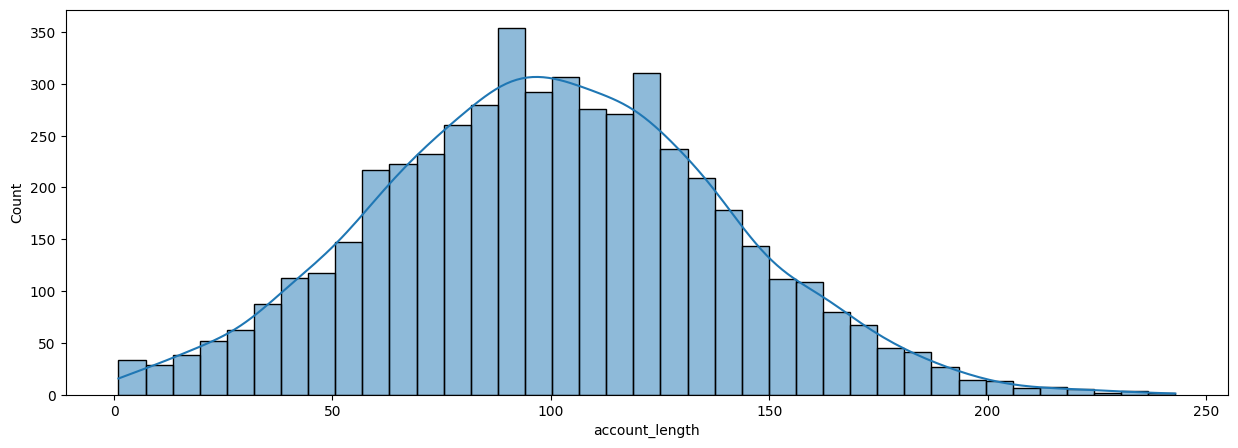

In [ ]:
plt.figure(figsize=(15,5))
sns.histplot(df['account_length'], kde=True)
plt.show()

#**`voice_messages`**

### Insight for 'voice_messages' Histogram

The histogram for `voice_messages` displays a **heavily right-skewed distribution**, with a significant concentration of values at the lower end.

*   **Dominant Zero/Low Volume**: The overwhelming majority of customers have zero voice messages. The largest bar in the histogram is at 0, indicating that most accounts do not utilize voice messaging.
*   **Rapid Decline**: As the number of voice messages increases, the frequency of customers rapidly declines. There are very few customers with a high number of voice messages.
*   **Sparse Distribution at Higher Values**: Beyond a small initial number of messages, the distribution becomes very sparse and spread out, indicating that having many voice messages is uncommon.

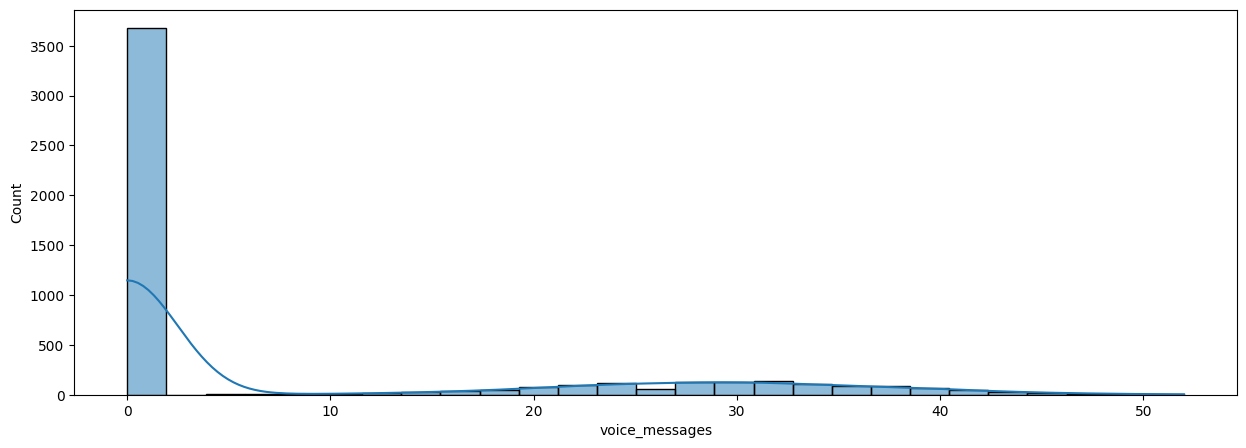

In [ ]:
plt.figure(figsize=(15,5))
sns.histplot(df['voice_messages'], kde=True)
plt.show()

#**intl_mins**

### Insight for 'intl_mins' Histogram

The histogram for `intl_mins` shows a distribution that is **approximately bell-shaped and fairly symmetrical**, similar to a normal distribution.

*   **Central Tendency**: The majority of `intl_mins` values are clustered around the mean, with the highest frequencies observed for international calls lasting between approximately 9 and 12 minutes.
*   **Spread**: The values are spread out from the center, with fewer calls being very short (e.g., less than 5 minutes) or very long (e.g., more than 15 minutes).
*   **Outliers/Extremes**: There are fewer occurrences at the extreme ends, such as calls below 3.25 minutes or above 17.25 minutes, which aligns with the outlier capping performed earlier. Overall, the distribution appears well-behaved with no significant skewness.

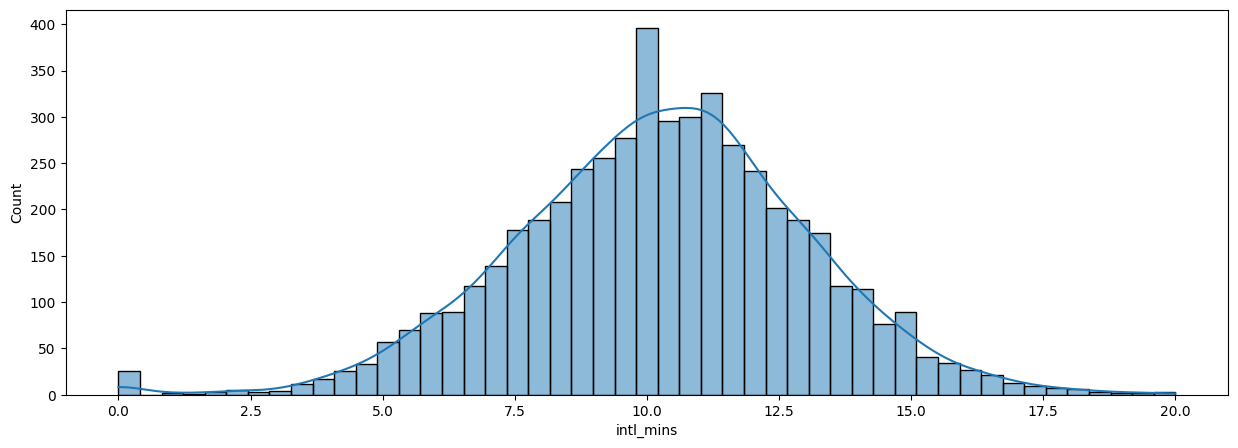

In [ ]:
plt.figure(figsize=(15,5))
sns.histplot(df['intl_mins'], kde=True)
plt.show()

#**`intl_calls`**

### Insight for 'intl_calls' Histogram

The histogram for `intl_calls` displays a **heavily right-skewed distribution**, with a significant concentration of values at the lower end.

*   **Dominant Low Call Volume**: The majority of customers make a low number of international calls, with the highest frequencies observed for 1 to 5 international calls.
*   **Rapid Decline**: As the number of international calls increases, the frequency of customers making those calls rapidly declines.
*   **Sparse Distribution at Higher Values**: Beyond a small initial number of calls, the distribution becomes very sparse and spread out, indicating that making many international calls is uncommon. The `value_counts()` and the outlier capping (`> 10.5` calls) confirm these less frequent extreme values.

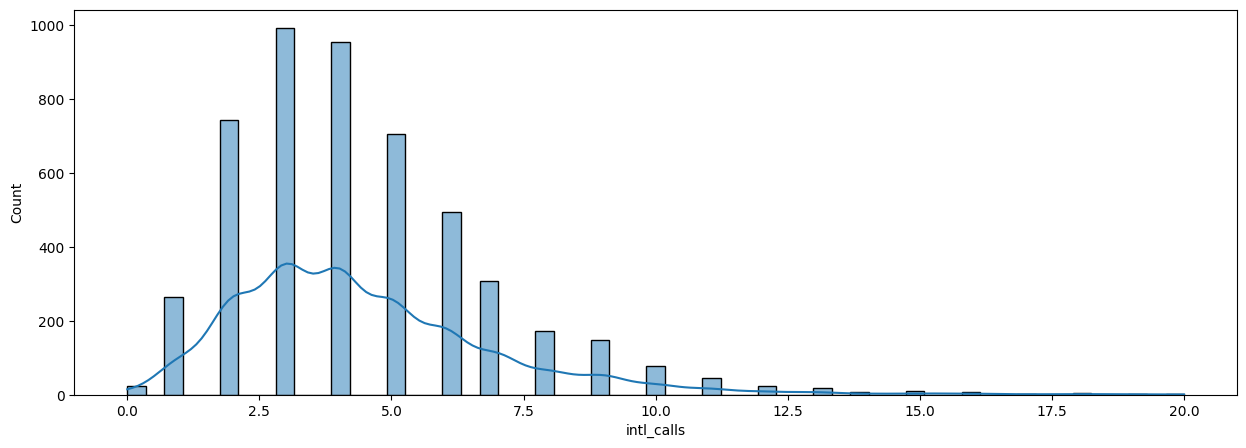

In [ ]:
plt.figure(figsize=(15,5))
sns.histplot(df['intl_calls'], kde=True)
plt.show()

#**`day_charge`**

### Insight for 'day_charge' Histogram

The histogram for `day_charge` shows a distribution that is **approximately bell-shaped and fairly symmetrical**, resembling a normal distribution.

*   **Central Tendency**: The majority of `day_charge` values are clustered around the mean, with the highest frequencies observed around 30-35.
*   **Spread**: The values spread out from the center, with fewer instances of very low or very high daily charges.
*   **Outliers/Extremes**: The distribution shows fewer occurrences at the extreme ends, which aligns with the outlier capping performed earlier (below 5.94 and above 55.23).

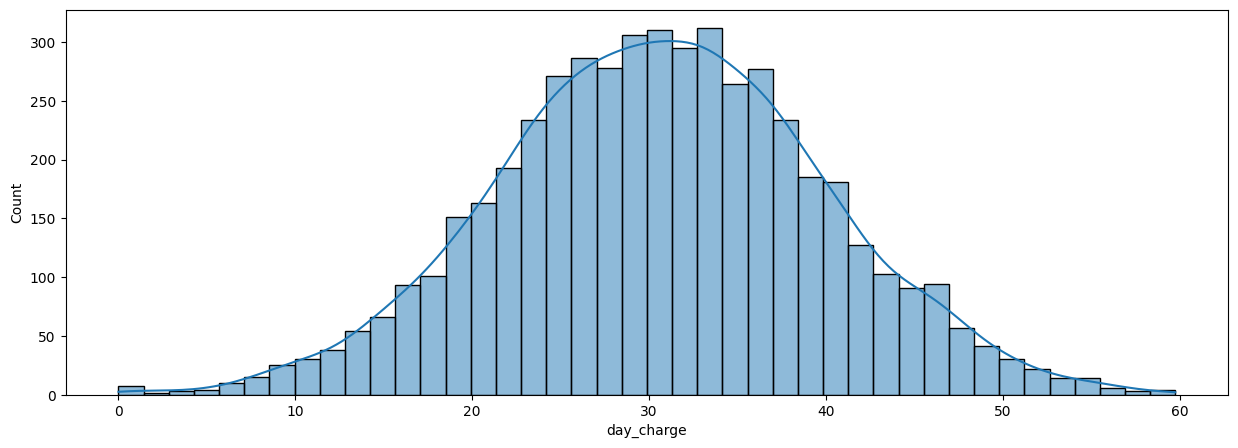

In [ ]:
plt.figure(figsize=(15,5))
sns.histplot(df['day_charge'], kde=True)
plt.show()

#**`day_mins`**

### Insight for 'day_mins' Histogram

The histogram for `day_mins` shows a distribution that is **approximately bell-shaped and fairly symmetrical**, resembling a normal distribution.

*   **Central Tendency**: The majority of `day_mins` values are clustered around the mean, with the highest frequencies observed around 180-200 minutes.
*   **Spread**: The values spread out from the center, with fewer instances of very low or very high daily minutes.
*   **Outliers/Extremes**: The distribution shows fewer occurrences at the extreme ends, which aligns with the outlier capping performed earlier (below 34.94 and above 324.95).

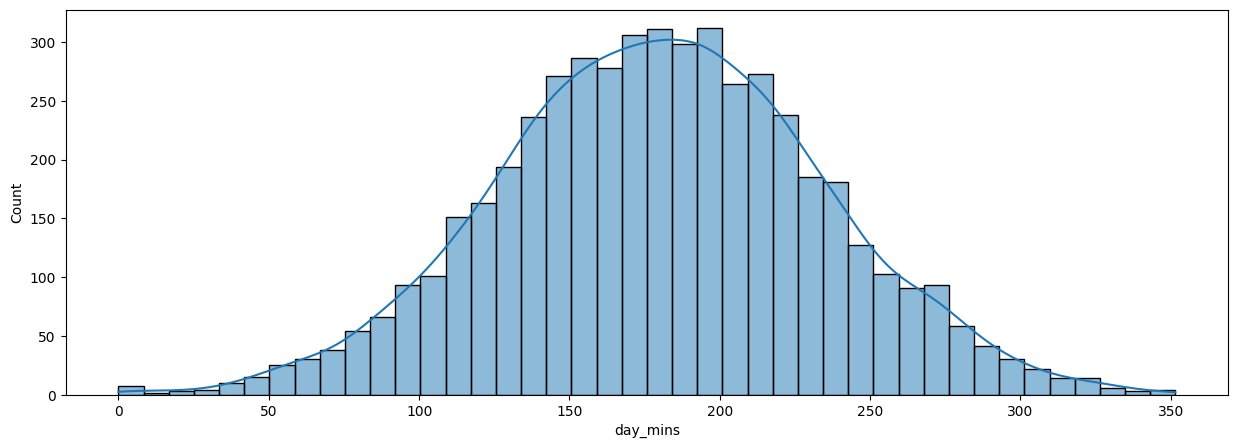

In [ ]:
plt.figure(figsize=(15,5))
sns.histplot(df['day_mins'], kde=True)
plt.show()

#**`day_calls`**

### Insight for 'day_calls' Histogram

The histogram for `day_calls` shows a distribution that is **approximately bell-shaped and fairly symmetrical**, resembling a normal distribution.

*   **Central Tendency**: The majority of `day_calls` values are clustered around the mean, with the highest frequencies observed around 90-100 calls.
*   **Spread**: The values spread out from the center, with fewer instances of very low or very high daily call counts.
*   **Outliers/Extremes**: The distribution shows fewer occurrences at the extreme ends, which aligns with the outlier capping performed earlier (below 48.0 and above 152.0).

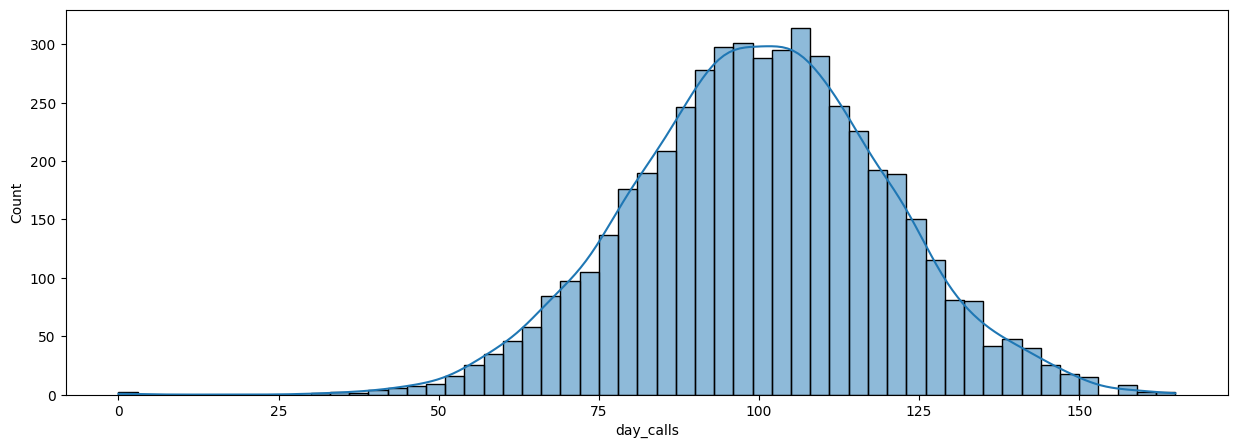

In [ ]:
plt.figure(figsize=(15,5))
sns.histplot(df['day_calls'], kde=True)
plt.show()

#**`day_charge`**

###Insight for the day_charge histogram:

###The histogram for day_charge shows a distribution that is approximately bell-shaped and fairly symmetrical, resembling a normal distribution.

* **Central Tendency**: The majority of day.charge values are clustered around the mean, with the highest frequencies observed around 30-35.

* **Spread**: The values spread out from the center, with fewer instances of very low or very high daily charges.

* **Outliers/Extremes**: The distribution shows fewer occurrences at the extreme ends, which aligns with the outlier capping performed earlier (below 5.94 and above 55.23).

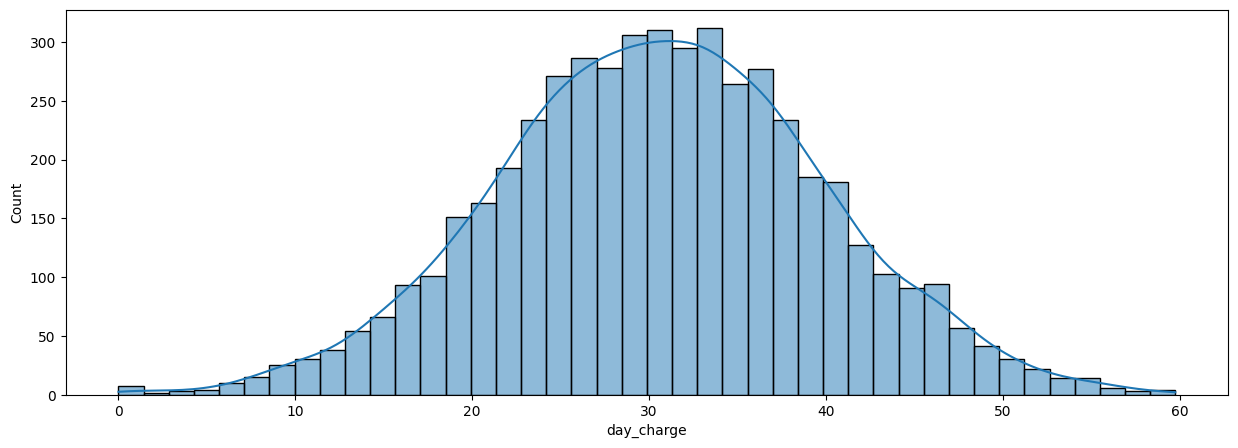

In [ ]:
plt.figure(figsize=(15,5))
sns.histplot(df['day_charge'], kde=True)
plt.show()

#**`eve_mins`**

### Insight for `eve_mins` Histogram

The histogram for `eve_mins` displays a distribution that is **approximately bell-shaped and fairly symmetrical**, closely resembling a normal distribution.

*   **Central Tendency**: The majority of `eve_mins` values are clustered around the mean, with the highest frequencies observed for evening calls lasting between approximately 175 and 225 minutes.
*   **Spread**: The values spread out from the center, with fewer instances of very low (e.g., below 75 minutes) or very high (e.g., above 275 minutes) evening call durations.
*   **Outliers/Extremes**: The distribution shows fewer occurrences at the extreme ends, which aligns with the outlier capping performed earlier (below 64.53 and above 335.83 minutes).

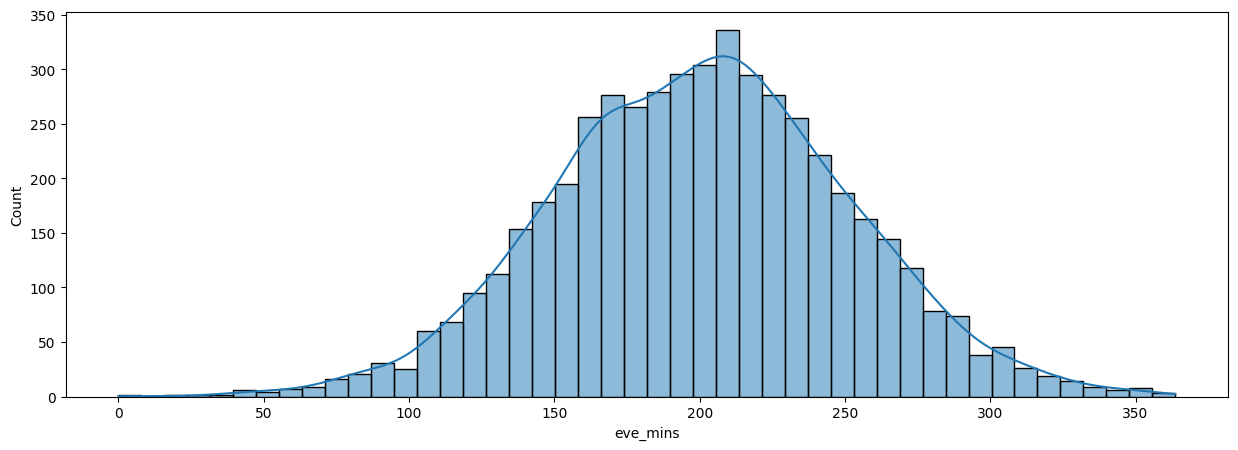

In [ ]:
plt.figure(figsize=(15,5))
sns.histplot(df['eve_mins'], kde=True)
plt.show()

#**`eve_calls`**

### Insight for 'eve_calls' Histogram

The histogram for `eve_calls` shows a distribution that is **approximately bell-shaped and fairly symmetrical**, closely resembling a normal distribution.

*   **Central Tendency**: The majority of `eve_calls` values are clustered around the mean, with the highest frequencies observed for evening calls ranging between approximately 90 and 110 calls.
*   **Spread**: The values spread out from the center, with fewer instances of very low (e.g., below 75 calls) or very high (e.g., above 125 calls) evening call counts.
*   **Outliers/Extremes**: The distribution shows fewer occurrences at the extreme ends, which aligns with the outlier capping performed earlier (below 46.5 and above 154.5 calls).

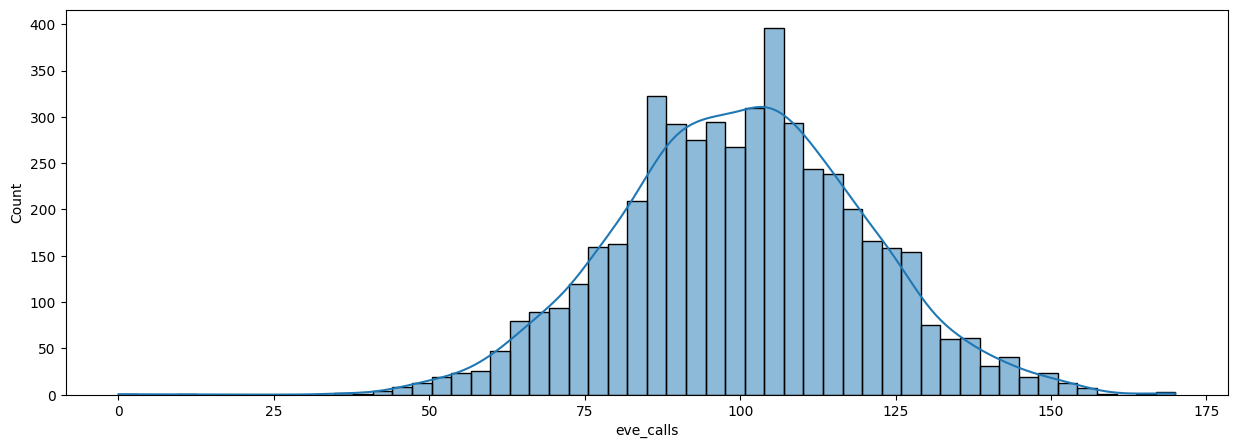

In [ ]:
plt.figure(figsize=(15,5))
sns.histplot(df['eve_calls'], kde=True)
plt.show()

#**`eve_charge`**

### Insight for 'eve_charge' Histogram

The histogram for `eve_charge` shows a distribution that is **approximately bell-shaped and fairly symmetrical**, closely resembling a normal distribution.

*   **Central Tendency**: The majority of `eve_charge` values are clustered around the mean, with the highest frequencies observed for evening charges around 17-20.
*   **Spread**: The values spread out from the center, with fewer instances of very low (e.g., below 10) or very high (e.g., above 25) evening charges.
*   **Outliers/Extremes**: The distribution shows fewer occurrences at the extreme ends, which aligns with the outlier capping performed earlier (below 5.50 and above 28.53).

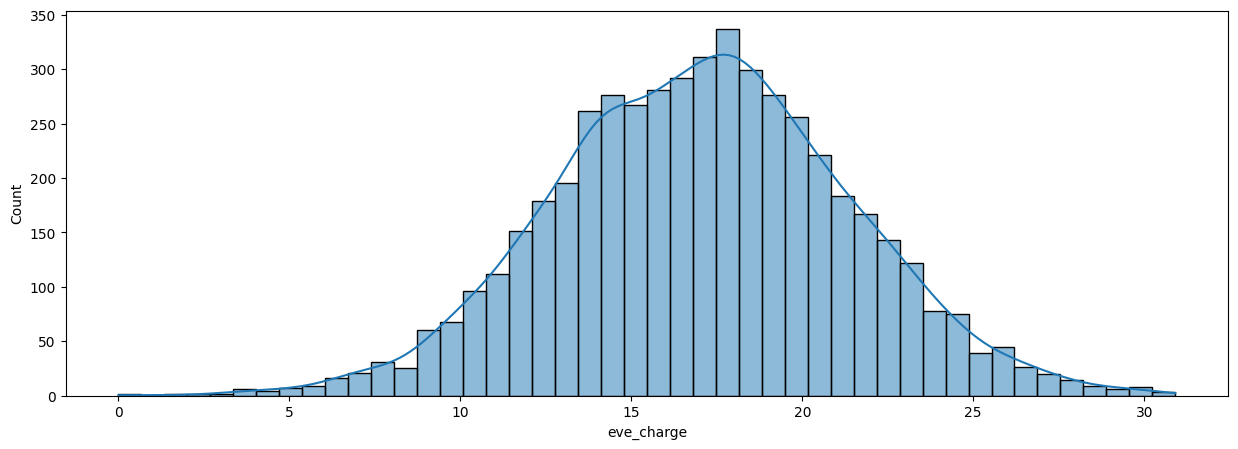

In [ ]:
plt.figure(figsize=(15,5))
sns.histplot(df['eve_charge'], kde=True)
plt.show()

#**`night_mins`**

### Insight for 'night_mins' Histogram

The histogram for `night_mins` shows a distribution that is **approximately bell-shaped and fairly symmetrical**, closely resembling a normal distribution.

*   **Central Tendency**: The majority of `night_mins` values are clustered around the mean, with the highest frequencies observed for night calls lasting between approximately 175 and 225 minutes.
*   **Spread**: The values spread out from the center, with fewer instances of very low (e.g., below 100 minutes) or very high (e.g., above 300 minutes) night call durations.
*   **Outliers/Extremes**: The distribution shows fewer occurrences at the extreme ends, which aligns with the outlier capping performed earlier (below 65.20 and above 336.4 minutes).

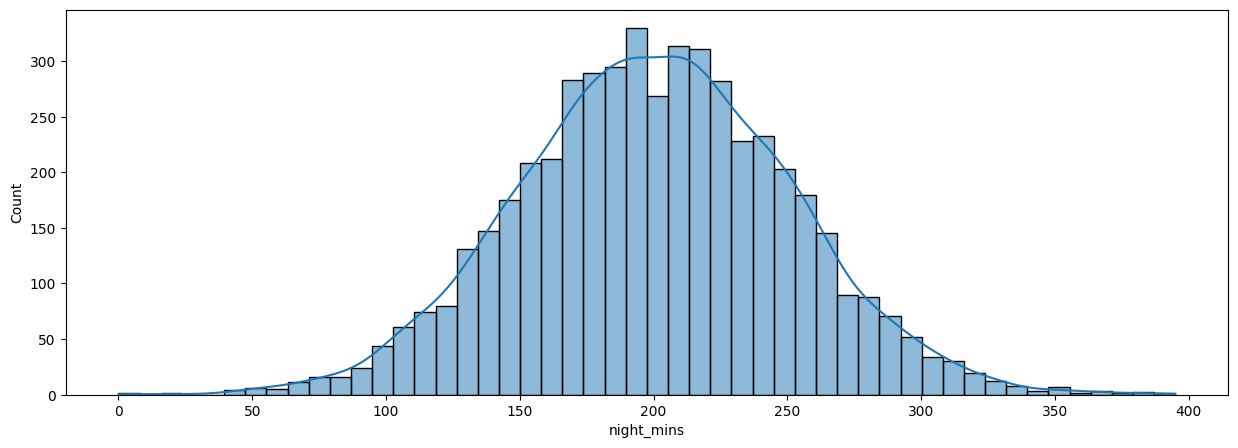

In [ ]:
plt.figure(figsize=(15,5))
sns.histplot(df['night_mins'], kde=True)
plt.show()

#**`night_calls`**

### Insight for 'night_calls' Histogram

The histogram for `night_calls` displays a distribution that is **approximately bell-shaped and fairly symmetrical**, closely resembling a normal distribution.

*   **Central Tendency**: The majority of `night_calls` values are clustered around the mean, with the highest frequencies observed for night calls ranging between approximately 90 and 110 calls.
*   **Spread**: The values spread out from the center, with fewer instances of very low (e.g., below 75 calls) or very high (e.g., above 125 calls) night call counts.
*   **Outliers/Extremes**: The distribution shows fewer occurrences at the extreme ends, which aligns with the outlier capping performed earlier (below 48.0 and above 152.0 calls).

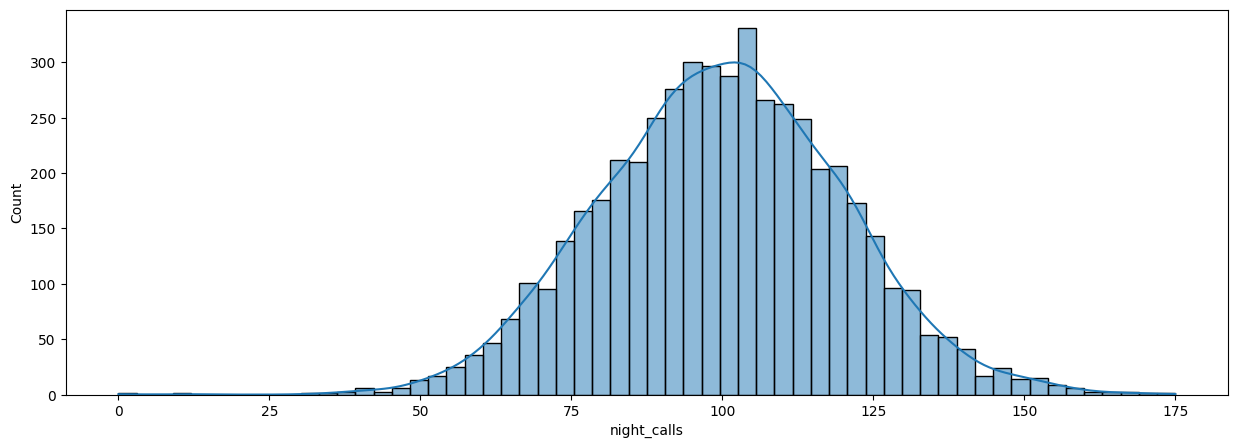

In [ ]:
plt.figure(figsize=(15,5))
sns.histplot(df['night_calls'], kde=True)
plt.show()

#**`night_charge`**

### Insight for 'night_charge' Histogram

The histogram for `night_charge` shows a distribution that is **approximately bell-shaped and fairly symmetrical**, closely resembling a normal distribution.

*   **Central Tendency**: The majority of `night_charge` values are clustered around the mean, with the highest frequencies observed for night charges ranging between approximately 8 and 10.
*   **Spread**: The values spread out from the center, with fewer instances of very low (e.g., below 5) or very high (e.g., above 13) night charges.
*   **Outliers/Extremes**: The distribution shows fewer occurrences at the extreme ends, which aligns with the outlier capping performed earlier (below 2.93 and above 15.13).

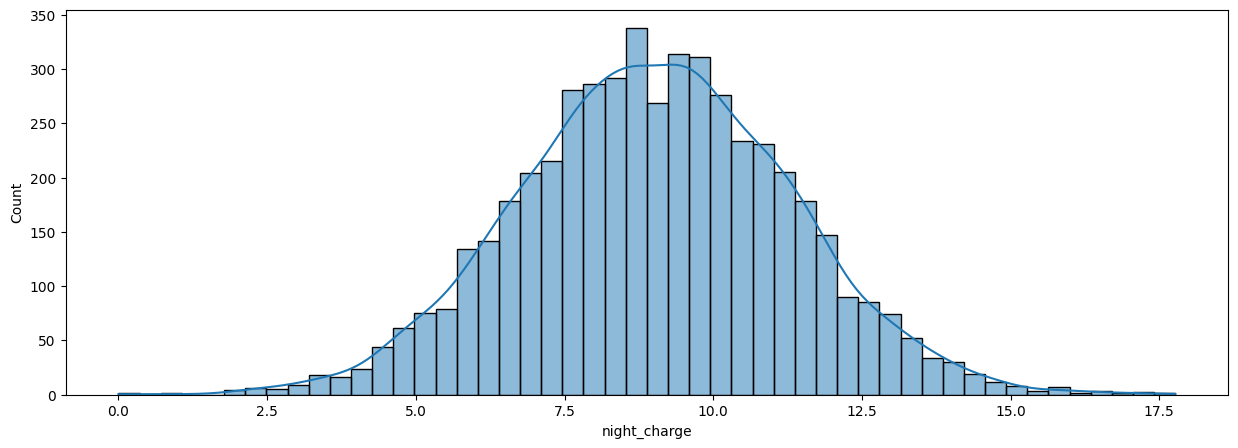

In [ ]:
plt.figure(figsize=(15,5))
sns.histplot(df['night_charge'], kde=True)
plt.show()

#**`customer_calls`**

### Insight for 'customer_calls' Histogram

The histogram for `customer_calls` displays a **heavily right-skewed distribution**, with a significant concentration of values at the lower end.

*   **Dominant Low Call Volume**: The overwhelming majority of customers have a low number of customer service calls, with the highest frequencies observed for 0 to 2 calls.
*   **Rapid Decline**: As the number of customer calls increases, the frequency of customers making those calls rapidly declines.
*   **Sparse Distribution at Higher Values**: Beyond a small initial number of calls, the distribution becomes very sparse and spread out, indicating that making many customer calls is uncommon. The `value_counts()` and the outlier capping (`> 3.5` calls) confirm these less frequent extreme values.

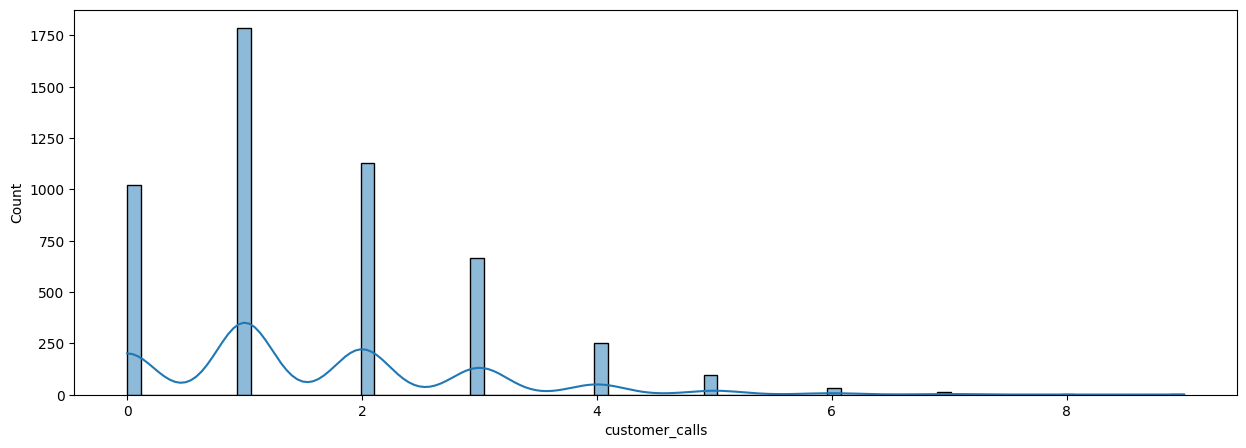

In [ ]:
plt.figure(figsize=(15,5))
sns.histplot(df['customer_calls'], kde=True)
plt.show()

In [ ]:
print(df['customer_calls'].value_counts().sort_index())

customer_calls
0    1023
1    1786
2    1127
3     665
4     252
5      96
6      34
7      13
8       2
9       2
Name: count, dtype: int64


In [ ]:
df.dtypes

,0
Unnamed: 0,int64
state,object
area_code,object
account_length,int64
voice_plan,object
voice_messages,int64
intl_plan,object
intl_mins,float64
intl_calls,int64
intl_charge,float64


#***2*) Categorical Features**

#**`state`**

### Insight for 'state' Countplot

The countplot for `state` shows the distribution of customers across various states.

*   **Relatively Even Distribution**: The number of customers per state appears to be relatively even across most states, with counts generally ranging from approximately 80 to 120.
*   **No Single Dominant State**: There isn't one state that significantly dominates the customer base; instead, the customer distribution is spread out among all 51 states (including 'DC' which is often treated as a state equivalent in such datasets).
*   **Slight Variations**: While generally even, there are slight variations. Some states like 'WV' and 'MN' show slightly higher customer counts, while others like 'AL' or 'MS' might have slightly lower counts. However, these variations are not extreme enough to suggest a major imbalance or a state with a disproportionately large or small customer presence.

This distribution implies that no specific state is an overwhelming source or lack of customers, which can be useful for regional marketing strategies or resource allocation without heavy bias towards one location.

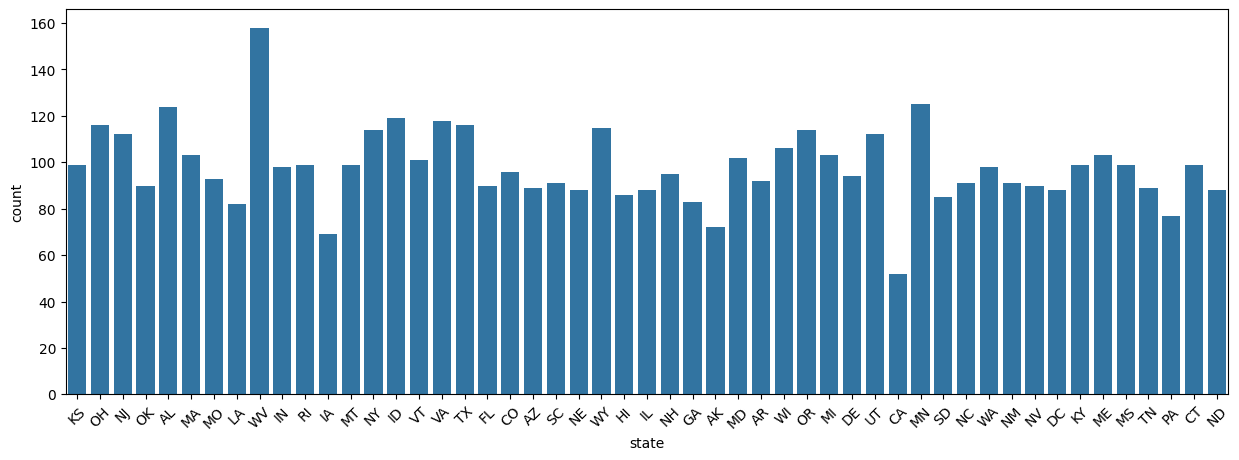

In [ ]:
plt.figure(figsize=(15,5))
sns.countplot(x='state', data=df)
plt.xticks(rotation=45)
plt.show()

#**area_code**

### Insight for 'area_code' Countplot

The countplot for `area_code` shows the distribution of customers across different area codes. Unlike the `state` distribution, this feature exhibits a clear imbalance.

*   **Dominant Area Code**: `area_code_415` is significantly more prevalent, with a customer count of approximately 2500.
*   **Less Prevalent Area Codes**: `area_code_408` and `area_code_510` have considerably fewer customers, each with counts around 1250. These two area codes have roughly similar customer bases, which are half the size of `area_code_415`.

This imbalanced distribution suggests that a large portion of the customer base resides in the `area_code_415` region. This insight could be crucial for targeted marketing efforts, resource allocation, or even understanding regional service performance. When building predictive models, the imbalance in this feature might need to be addressed, for example, by ensuring that any sampling or validation strategies account for these differing proportions.

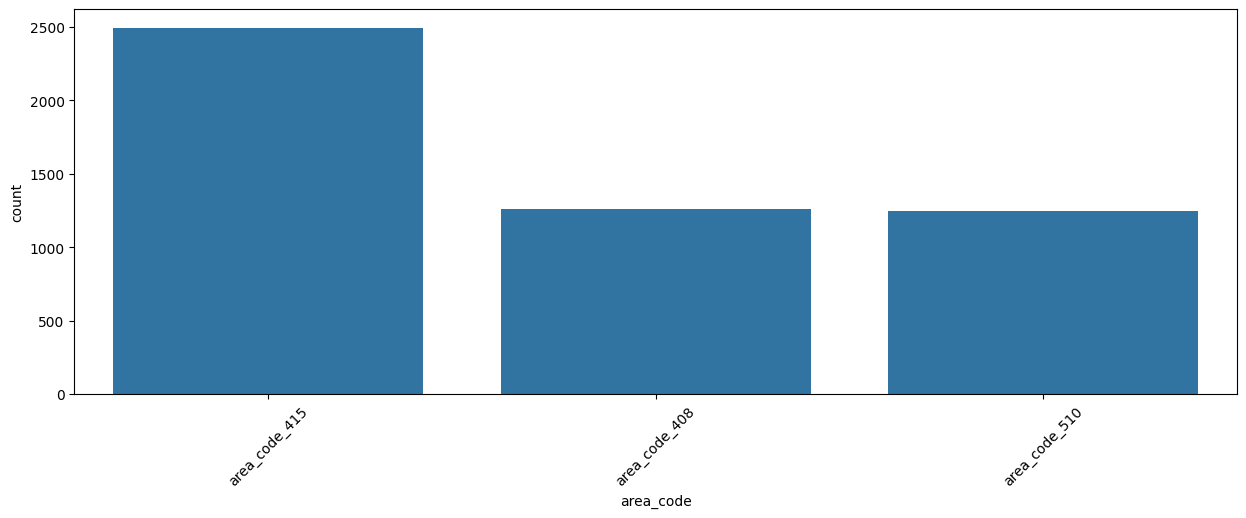

In [ ]:
plt.figure(figsize=(15,5))
sns.countplot(x='area_code', data=df)
plt.xticks(rotation=45)
plt.show()

#**`voice_plan`**

### Insight for 'voice_plan' Countplot

The countplot for `voice_plan` clearly shows a **significant imbalance** in the distribution of customers with and without a voice plan.

*   **Majority Without Voice Plan**: A large majority of customers (approximately 3700) do **not** have a voice plan, represented by the 'no' category.
*   **Minority With Voice Plan**: A much smaller proportion of customers (approximately 1300) **do** have a voice plan, represented by the 'yes' category.

This imbalance is an important factor to consider. It indicates that voice plans are not widely adopted by the customer base. This insight can be valuable for:

*   **Marketing Strategy**: Targeted campaigns could be developed to promote voice plans to the 'no' segment, highlighting benefits or special offers.
*   **Product Development**: Further investigation into why most customers do not opt for a voice plan could inform product improvements or new service offerings.
*   **Predictive Modeling**: When building models, this class imbalance in `voice_plan` should be taken into account (e.g., using stratified sampling, oversampling, or undersampling techniques) to prevent the model from being biased towards the majority class.

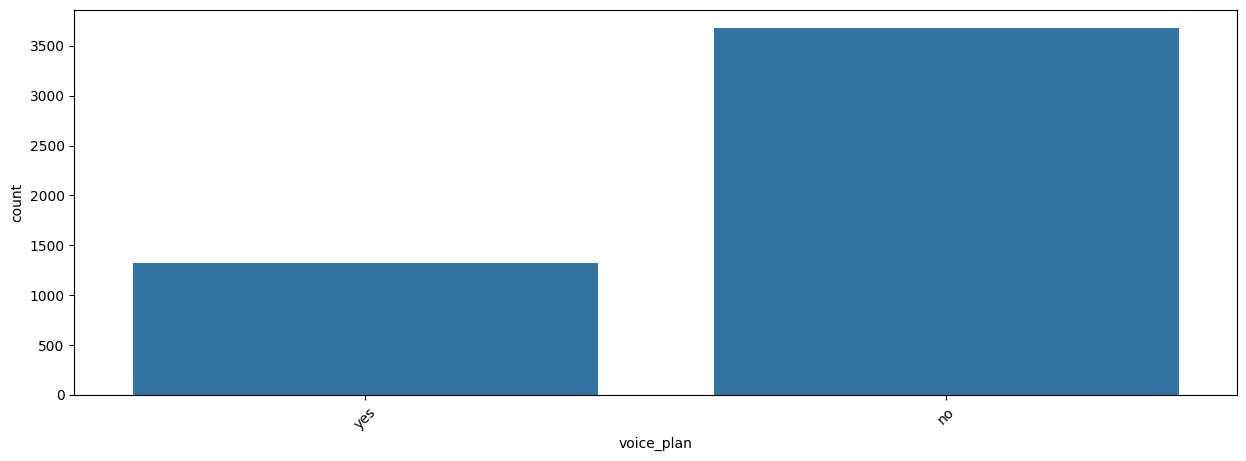

In [ ]:
plt.figure(figsize=(15,5))
sns.countplot(x='voice_plan', data=df)
plt.xticks(rotation=45)
plt.show()

#**intl_plan**

### Insight for 'intl_plan' Countplot

The countplot for `intl_plan` reveals a **significant imbalance** in the distribution of customers with and without an international plan.

*   **Majority Without International Plan**: A large majority of customers (approximately 4500) do **not** have an international plan, represented by the 'no' category.
*   **Minority With International Plan**: A much smaller proportion of customers (approximately 500) **do** have an international plan, represented by the 'yes' category.

This imbalance is an important factor for business strategy and predictive modeling:

*   **Marketing Opportunity**: There's a clear opportunity to market international plans to the vast majority of customers who currently don't have one.
*   **Product Perception**: Further analysis could investigate reasons for low adoption, such as perceived value, cost, or awareness.
*   **Class Imbalance in Modeling**: Similar to the `voice_plan` feature, this strong imbalance in `intl_plan` must be addressed during model training to avoid bias towards the majority class (e.g., using oversampling, undersampling, or weighted algorithms).

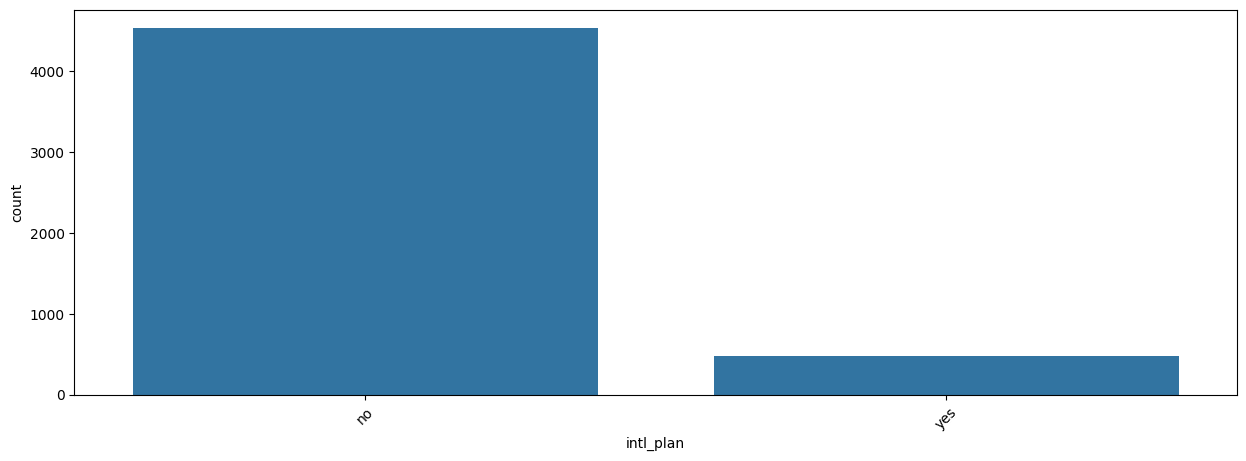

In [ ]:
plt.figure(figsize=(15,5))
sns.countplot(x='intl_plan', data=df)
plt.xticks(rotation=45)
plt.show()

#**`Churn`**

### Insight for 'Churn' Countplot

The countplot for `churn` reveals a **significant class imbalance** in the target variable.

*   **Majority Non-Churners**: A large majority of customers (approximately 4200) are 'no' churn, meaning they have not churned.
*   **Minority Churners**: A much smaller proportion of customers (approximately 800) are 'yes' churn, meaning they have churned.

This imbalance is a critical factor for any predictive modeling task:

*   **Model Bias**: Machine learning models trained on such imbalanced datasets tend to be biased towards the majority class (non-churners). This means they might perform well in predicting the majority class but poorly in predicting the minority class (churners), which is often the class of interest.
*   **Evaluation Metrics**: Standard evaluation metrics like accuracy can be misleading in imbalanced datasets. It's important to use metrics more suitable for imbalanced data, such as precision, recall, F1-score, or AUC-ROC.
*   **Handling Imbalance**: Techniques to address class imbalance during model training will be essential, including:
    *   **Resampling methods**: Oversampling the minority class (e.g., SMOTE) or undersampling the majority class.
    *   **Cost-sensitive learning**: Assigning different misclassification costs to each class.
    *   **Algorithm selection**: Using algorithms that are inherently robust to class imbalance (e.g., tree-based models like Random Forest or Gradient Boosting).

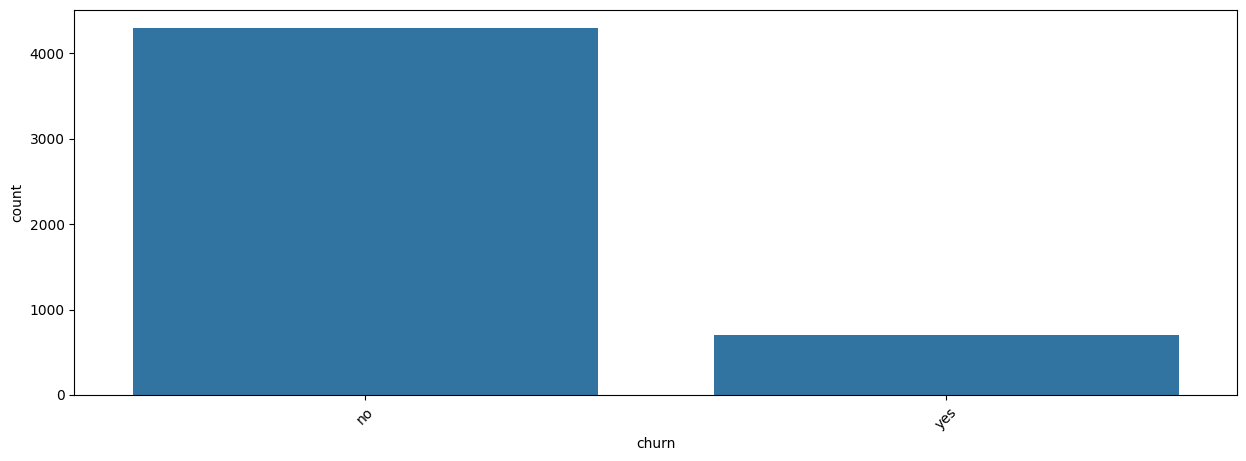

In [ ]:
plt.figure(figsize=(15,5))
sns.countplot(x='churn', data=df)
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.columns

Index(['Unnamed: 0', 'state', 'area_code', 'account_length', 'voice_plan',
       'voice_messages', 'intl_plan', 'intl_mins', 'intl_calls', 'intl_charge',
       'day_mins', 'day_calls', 'day_charge', 'eve_mins', 'eve_calls',
       'eve_charge', 'night_mins', 'night_calls', 'night_charge',
       'customer_calls', 'churn'],
      dtype='object')

In [ ]:
df['churn'] = df['churn'].map({'no': 0, 'yes': 1})

#**Bivariate Analysis**

#***1*) Numaric Feature**

#**`account_length vs. churn`**

###Insight for 'account.length' vs. 'churn' Regplot


The regplot showing account_length versus churn reveals that there is a very weak, almost negligible, positive linear relationship between a customer's account length and their likelihood of churning.

**Flat Trend Line**: The regression line (the blue line in the plot) is nearly flat, with a slight upward slope. This indicates that as account.length increases, there's a very slight, but not substantial, increase in the predicted probability of churn.

**Wide Confidence Interval**: The shaded area around the regression line (the confidence interval) is quite wide, especially at the extremes, suggesting that there's considerable uncertainty around this estimated relationship. This reinforces the idea that account.length alone is not a strong predictor of churn.

**Churn at All Lengths**: Churn (represented by points at churn=1) occurs across the entire spectrum of account.length values. Similarly, non-churners (churn=0) are also present at all account lengths.

**Implication**: While there might be a minuscule tendency for longer-term customers to have a slightly higher (or at least not lower) churn probability in this dataset, account.length by itself does not appear to be a significant factor in determining churn. Other features are likely much more influential in predicting whether a customer will churn or not.

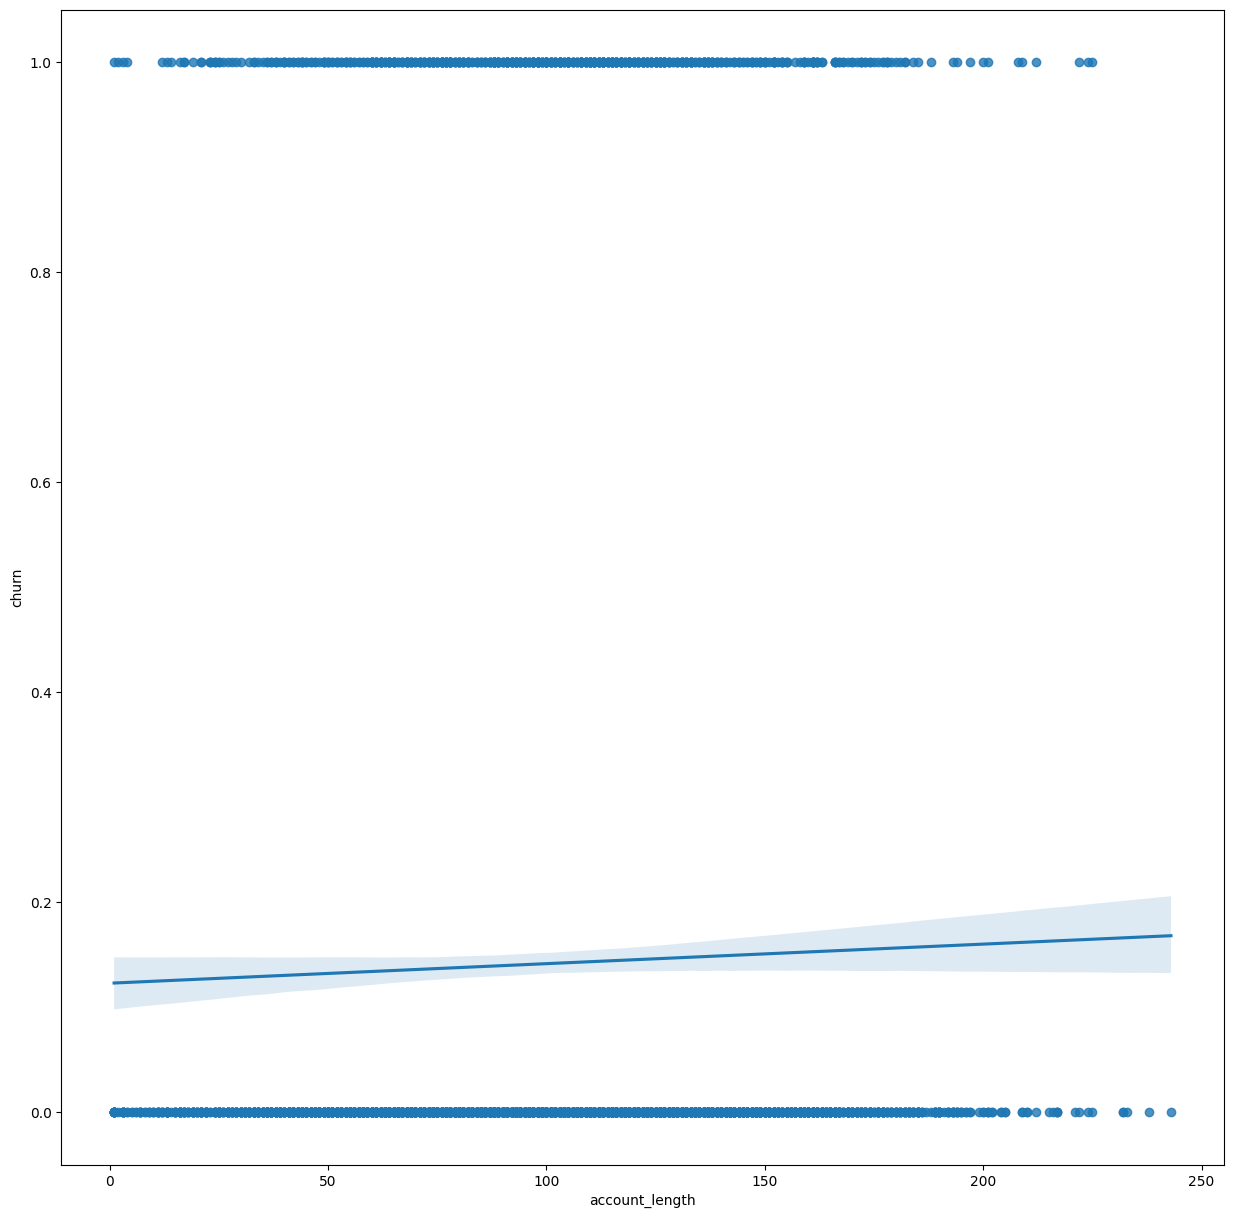

In [ ]:
plt.figure(figsize=(15,15))
sns.regplot(
    x='account_length',
    y='churn',
    data=df
)
plt.show()

#**`voice_messages vs. churn`**

### Insight for 'voice_messages' vs. 'churn' Regplot

The regplot showing `voice_messages` versus `churn` indicates a **weak, negative linear relationship** between the number of voice messages and the likelihood of churning.

*   **Downward Sloping Trend Line**: The regression line (blue line) has a slight downward slope. This suggests that as the number of voice messages increases, the predicted probability of churn tends to decrease, albeit marginally.
*   **Wide Confidence Interval**: The shaded area around the regression line (confidence interval) is wide, particularly at the extremes. This implies considerable uncertainty around the estimated relationship, indicating that `voice_messages` is not a strong, independent predictor of churn.
*   **High Concentration at Zero Voice Messages**: A significant number of customers have zero voice messages, and churn is observed among both those with and without voice messages. The scatter points at `churn=0` and `churn=1` are spread across the range of `voice_messages` values, but with a noticeable cluster at 0 voice messages.

**Implication**: While there's a faint indication that customers who use voice messages more frequently might be slightly less prone to churn, this feature alone does not appear to be a major determinant of churn. The relationship is not strong enough to suggest that voice messages are a primary driver or deterrent of churn.

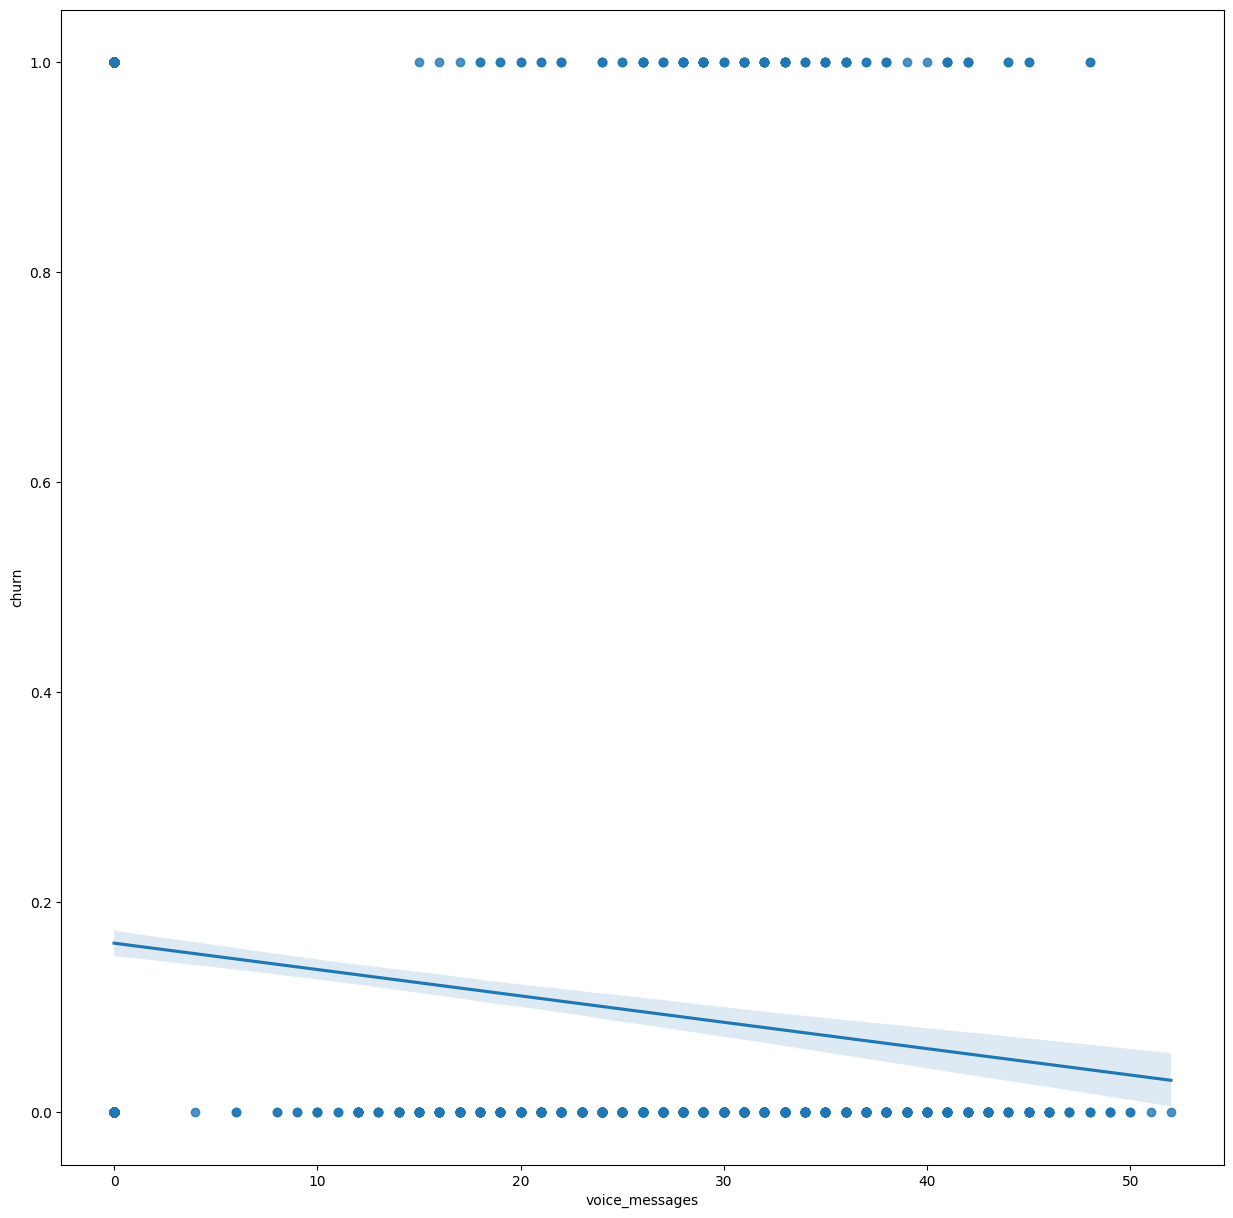

In [ ]:
plt.figure(figsize=(15,15))
sns.regplot(
    x='voice_messages',
    y='churn',
    data=df
)
plt.show()

#**`intl_mins vs. churn`**

### Insight for 'intl_mins' vs. 'churn' Regplot

The regplot depicting `intl_mins` against `churn` suggests a **weak positive linear relationship**.

*   **Upward Sloping Trend Line**: The regression line (blue line) shows a slight upward trend. This indicates that as the total international call minutes increase, there is a marginal increase in the predicted probability of churn.
*   **Wide Confidence Interval**: The confidence interval around the regression line is quite broad, especially at the extremes of `intl_mins`. This signifies that the certainty of this positive relationship is low, implying that `intl_mins` alone is not a strong, independent predictor of churn.
*   **Churn Across `intl.mins`**: Churn (points at `churn=1`) and non-churn (points at `churn=0`) customers are observed across the entire range of `intl_mins` values.

**Implication**: While there's a slight tendency for customers with higher international call minutes to have a slightly increased propensity to churn, this feature does not appear to be a primary driver of churn. The relationship is too weak and uncertain to draw strong conclusions about its direct impact on customer retention.

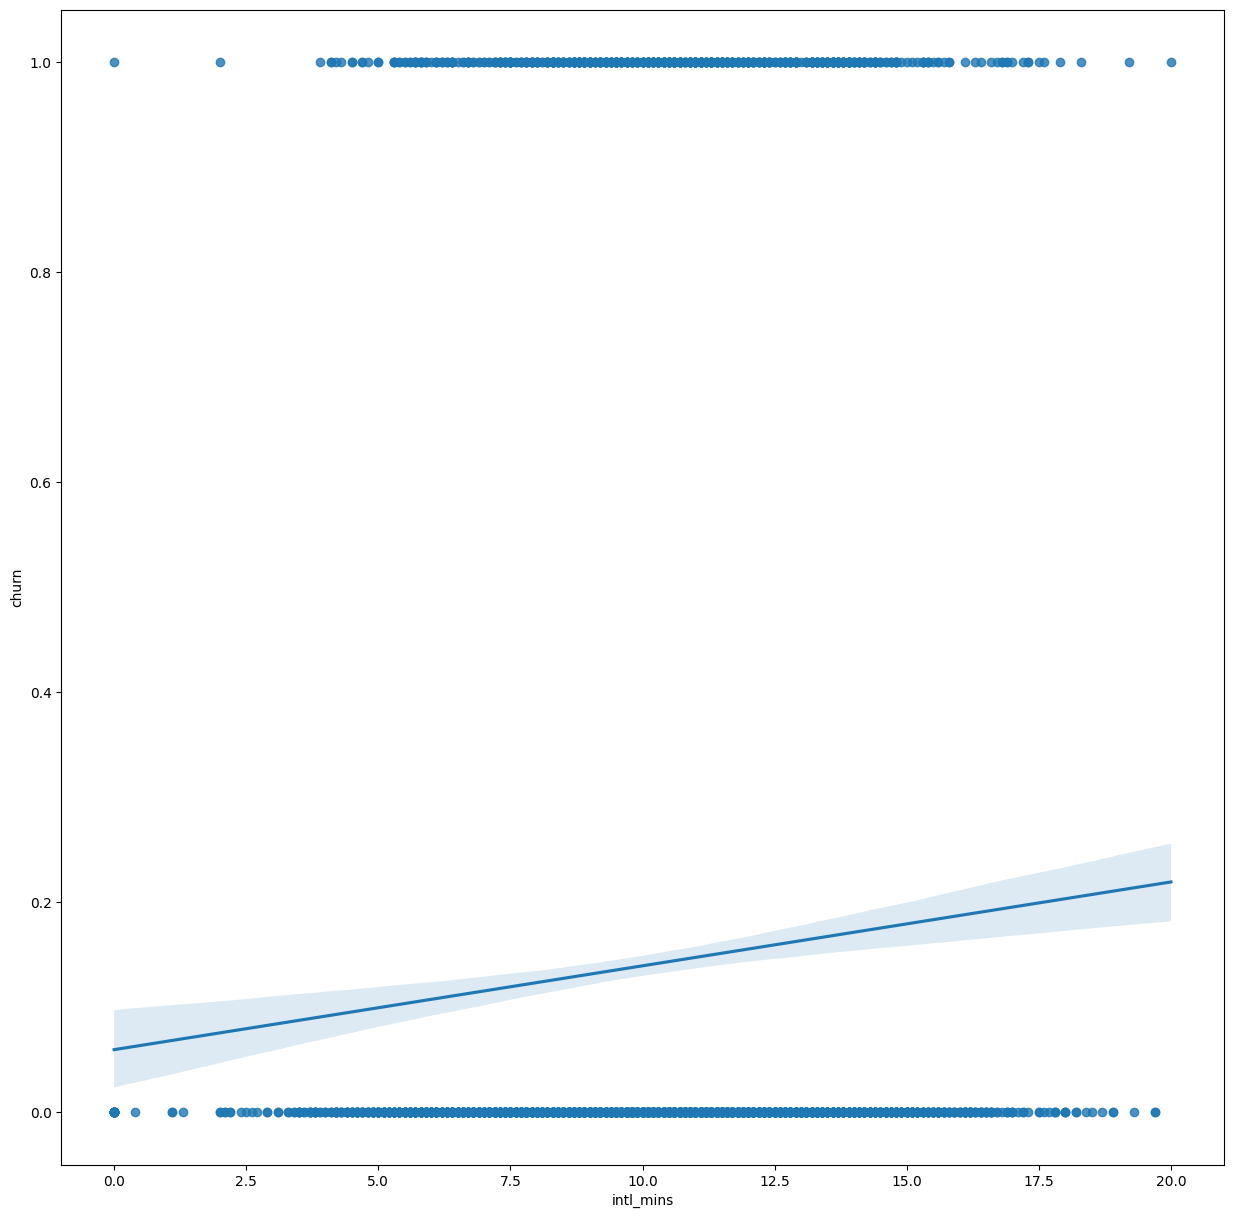

In [ ]:
plt.figure(figsize=(15,15))
sns.regplot(
    x='intl_mins',
    y='churn',
    data=df
)
plt.show()

#**`intl_calls vs. churn`**

### Insight for 'intl_calls' vs. 'churn' Regplot

The regplot showing `intl_calls` versus `churn` reveals a **weak negative linear relationship**.

*   **Downward Sloping Trend Line**: The regression line (blue line) shows a slight downward trend. This indicates that as the number of international calls increases, there is a marginal decrease in the predicted probability of churn.
*   **Wide Confidence Interval**: The confidence interval around the regression line is quite broad, especially at the extremes of `intl_calls`. This signifies that the certainty of this negative relationship is low, implying that `intl_calls` alone is not a strong, independent predictor of churn.
*   **Churn Across `intl.calls`**: Churn (points at `churn=1`) and non-churn (points at `churn=0`) customers are observed across the entire range of `intl_calls` values, though there are fewer customers making a very high number of international calls.

**Implication**: While there's a slight tendency for customers who make more international calls to be slightly less prone to churn, this feature does not appear to be a primary driver of churn. The relationship is too weak and uncertain to draw strong conclusions about its direct impact on customer retention.

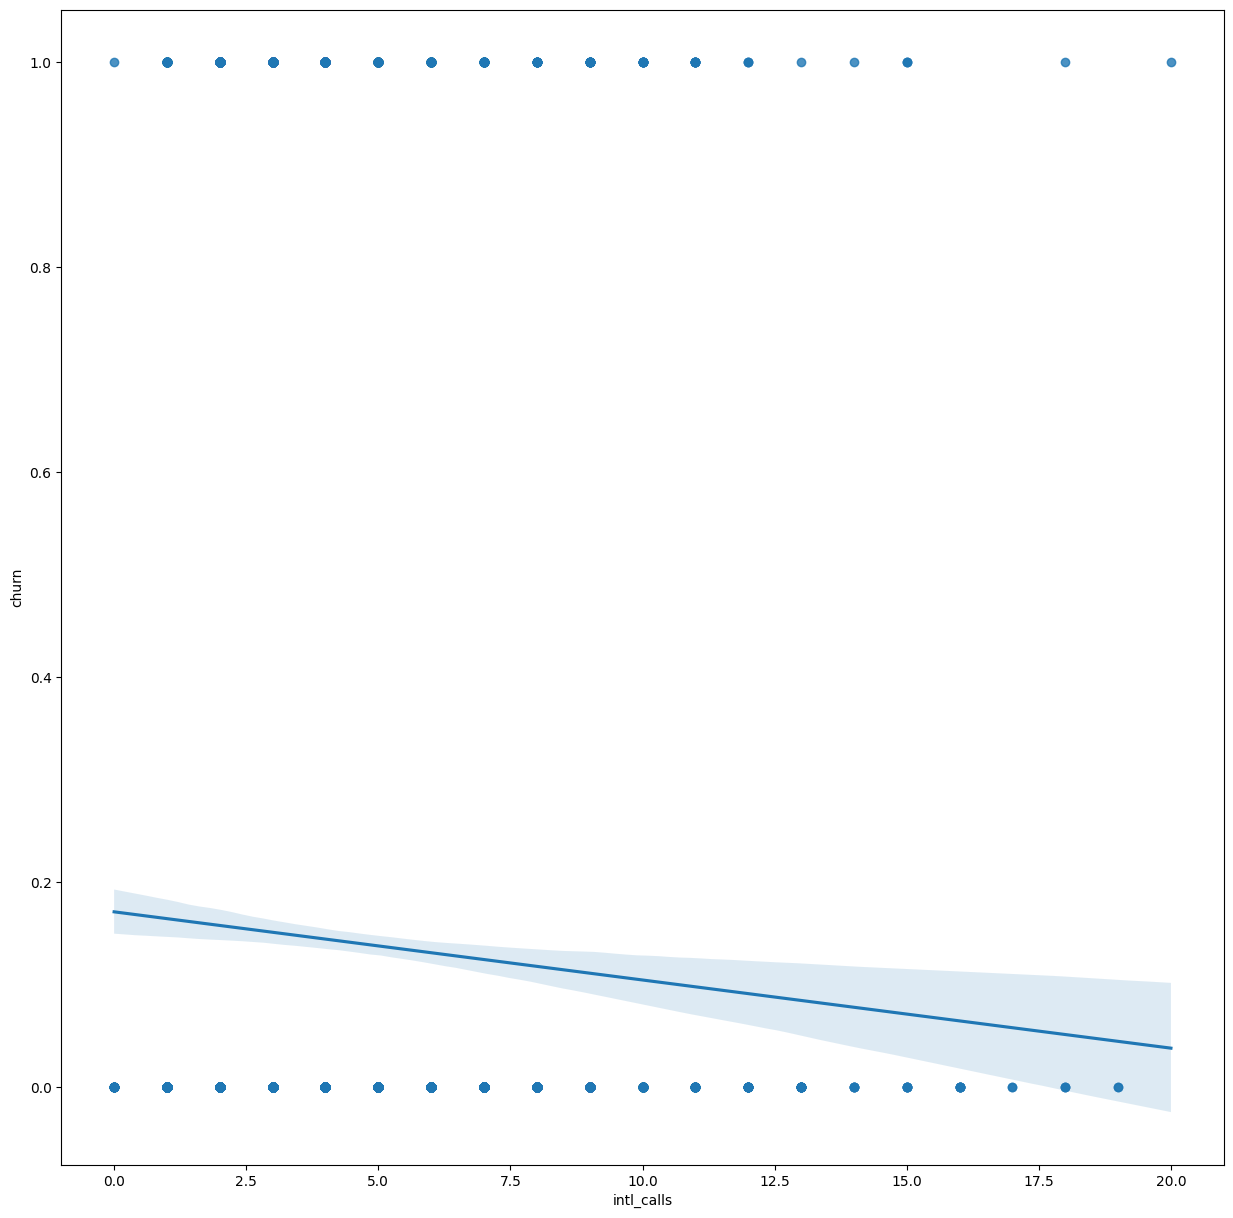

In [ ]:
plt.figure(figsize=(15,15))
sns.regplot(
    x='intl_calls',
    y='churn',
    data=df
)
plt.show()

#**`intl_charge vs. churn`**

### Insight for 'intl_charge' vs. 'churn' Regplot

The regplot depicting `intl_charge` against `churn` suggests a **weak positive linear relationship**.

*   **Upward Sloping Trend Line**: The regression line (blue line) shows a slight upward trend. This indicates that as the total international call charge increases, there is a marginal increase in the predicted probability of churn.
*   **Wide Confidence Interval**: The confidence interval around the regression line is quite broad, especially at the extremes of `intl_charge`. This signifies that the certainty of this positive relationship is low, implying that `intl_charge` alone is not a strong, independent predictor of churn.
*   **Churn Across `intl.charge`**: Churn (points at `churn=1`) and non-churn (points at `churn=0`) customers are observed across the entire range of `intl_charge` values.

**Implication**: While there's a slight tendency for customers with higher international call charges to have a slightly increased propensity to churn, this feature does not appear to be a primary driver of churn. The relationship is too weak and uncertain to draw strong conclusions about its direct impact on customer retention.

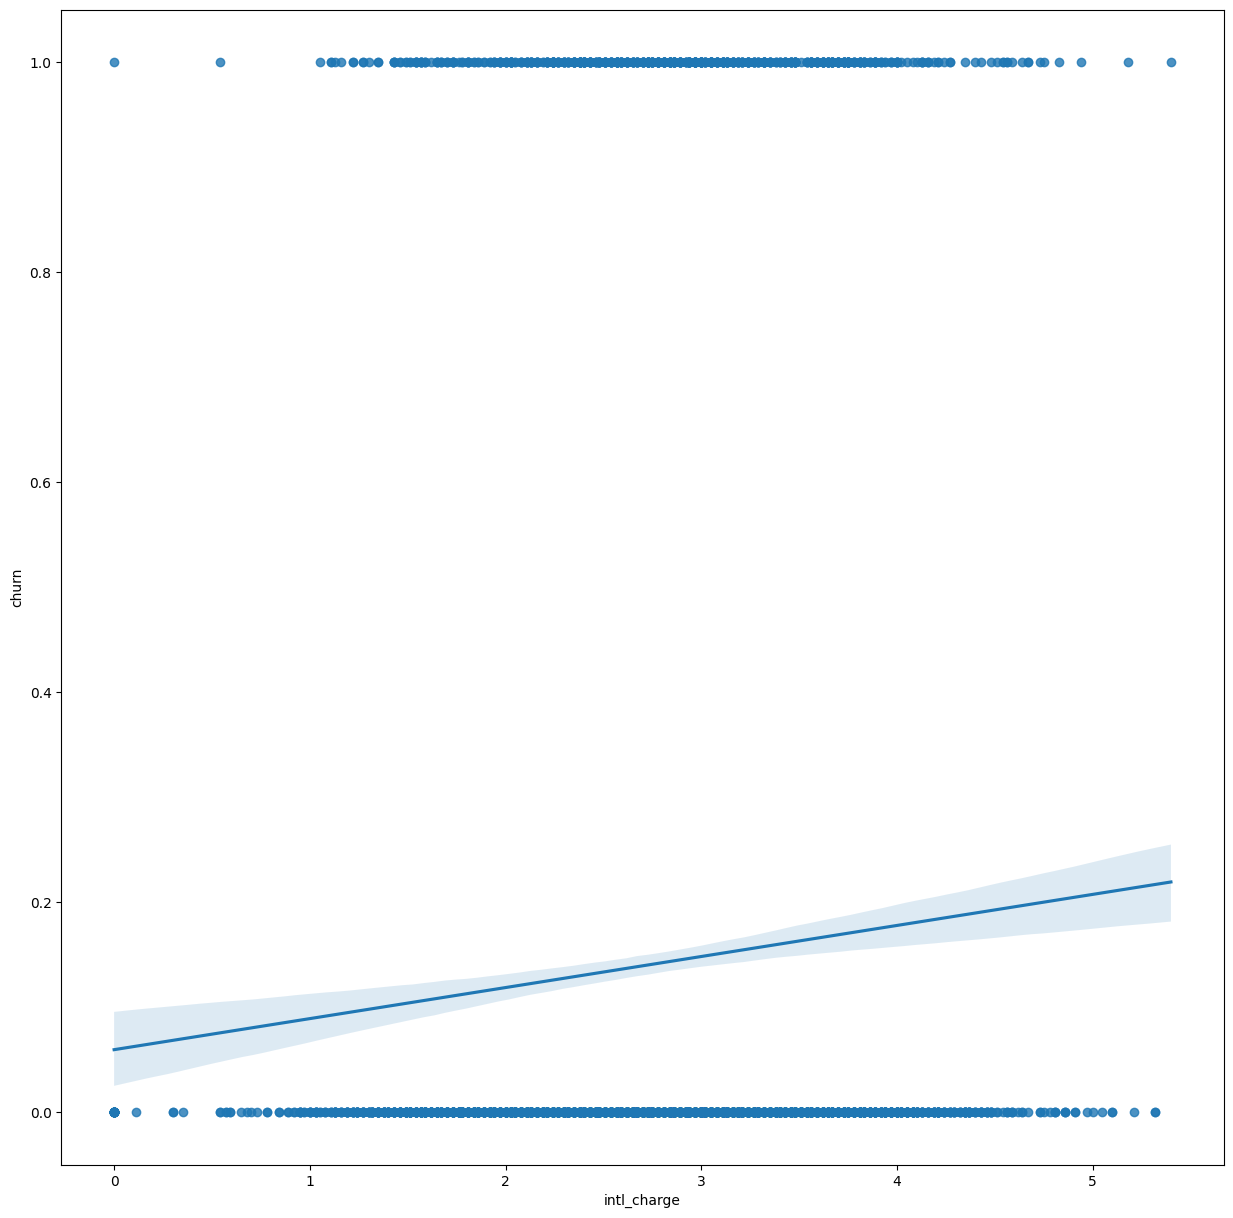

In [ ]:
plt.figure(figsize=(15,15))
sns.regplot(
    x='intl_charge',
    y='churn',
    data=df
)
plt.show()

#**`day_mins vs. churn`**

### Insight for 'day_mins' vs. 'churn' Regplot

The regplot showing `day_mins` versus `churn` reveals a **strong positive linear relationship** between the total day minutes and the likelihood of churning.

*   **Upward Sloping Trend Line**: The regression line (blue line) has a clear and significant upward slope. This indicates that as the total day minutes increase, the predicted probability of churn substantially increases.
*   **Relatively Narrow Confidence Interval**: The shaded area around the regression line (confidence interval) is relatively narrow compared to other features, especially in the central range of `day_mins`. This suggests a higher degree of certainty in the estimated positive relationship, making `day_mins` a more reliable predictor of churn.
*   **Clear Separation at Higher Values**: For customers with very high `day_mins`, there is a noticeable concentration of churners (points at `churn=1`), indicating that exceeding a certain threshold of day usage strongly correlates with churn.

**Implication**: This is a crucial insight. Customers who spend more minutes on day calls are significantly more likely to churn. This could be due to various reasons, such as dissatisfaction with service quality during peak usage, higher billing leading to price sensitivity, or finding better deals elsewhere for heavy usage. Businesses should investigate the underlying causes of high usage leading to churn and consider targeted interventions for this segment, such as personalized plans, proactive support, or loyalty programs.

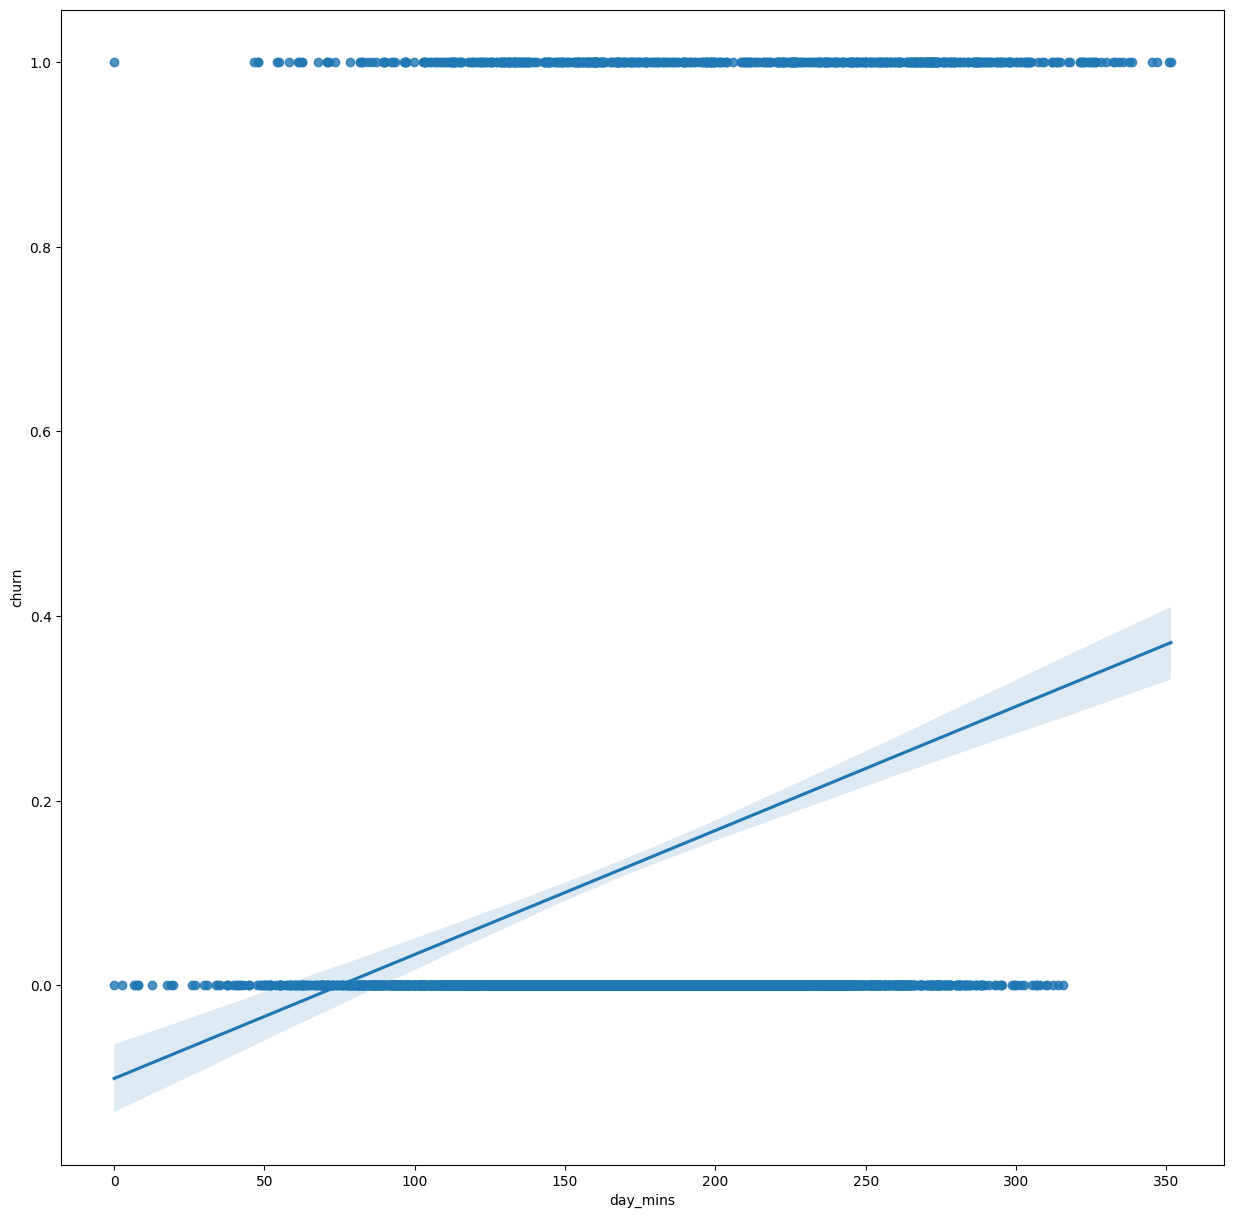

In [ ]:
plt.figure(figsize=(15,15))
sns.regplot(
    x='day_mins',
    y='churn',
    data=df
)
plt.show()

#**`day_calls vs. churn`**

### Insight for 'day_calls' vs. 'churn' Regplot

The regplot showing `day_calls` versus `churn` reveals a **very weak, almost negligible, positive linear relationship** between the number of day calls and the likelihood of churning.

*   **Flat Trend Line**: The regression line (blue line) is nearly flat, with a minimal upward slope. This suggests that as the number of day calls increases, there's a very slight, almost imperceptible, increase in the predicted probability of churn.
*   **Wide Confidence Interval**: The shaded area around the regression line (the confidence interval) is quite wide, indicating considerable uncertainty around this estimated relationship. This reinforces the idea that `day_calls` alone is not a strong predictor of churn.
*   **Churn at All Call Volumes**: Churn (represented by points at `churn=1`) occurs across the entire spectrum of `day_calls` values. Similarly, non-churners (`churn=0`) are also present at all day call volumes.

**Implication**: While there might be a minuscule tendency for customers making more day calls to have a slightly higher churn probability, `day_calls` by itself does not appear to be a significant factor in determining churn. Other features are likely much more influential in predicting whether a customer will churn or not.

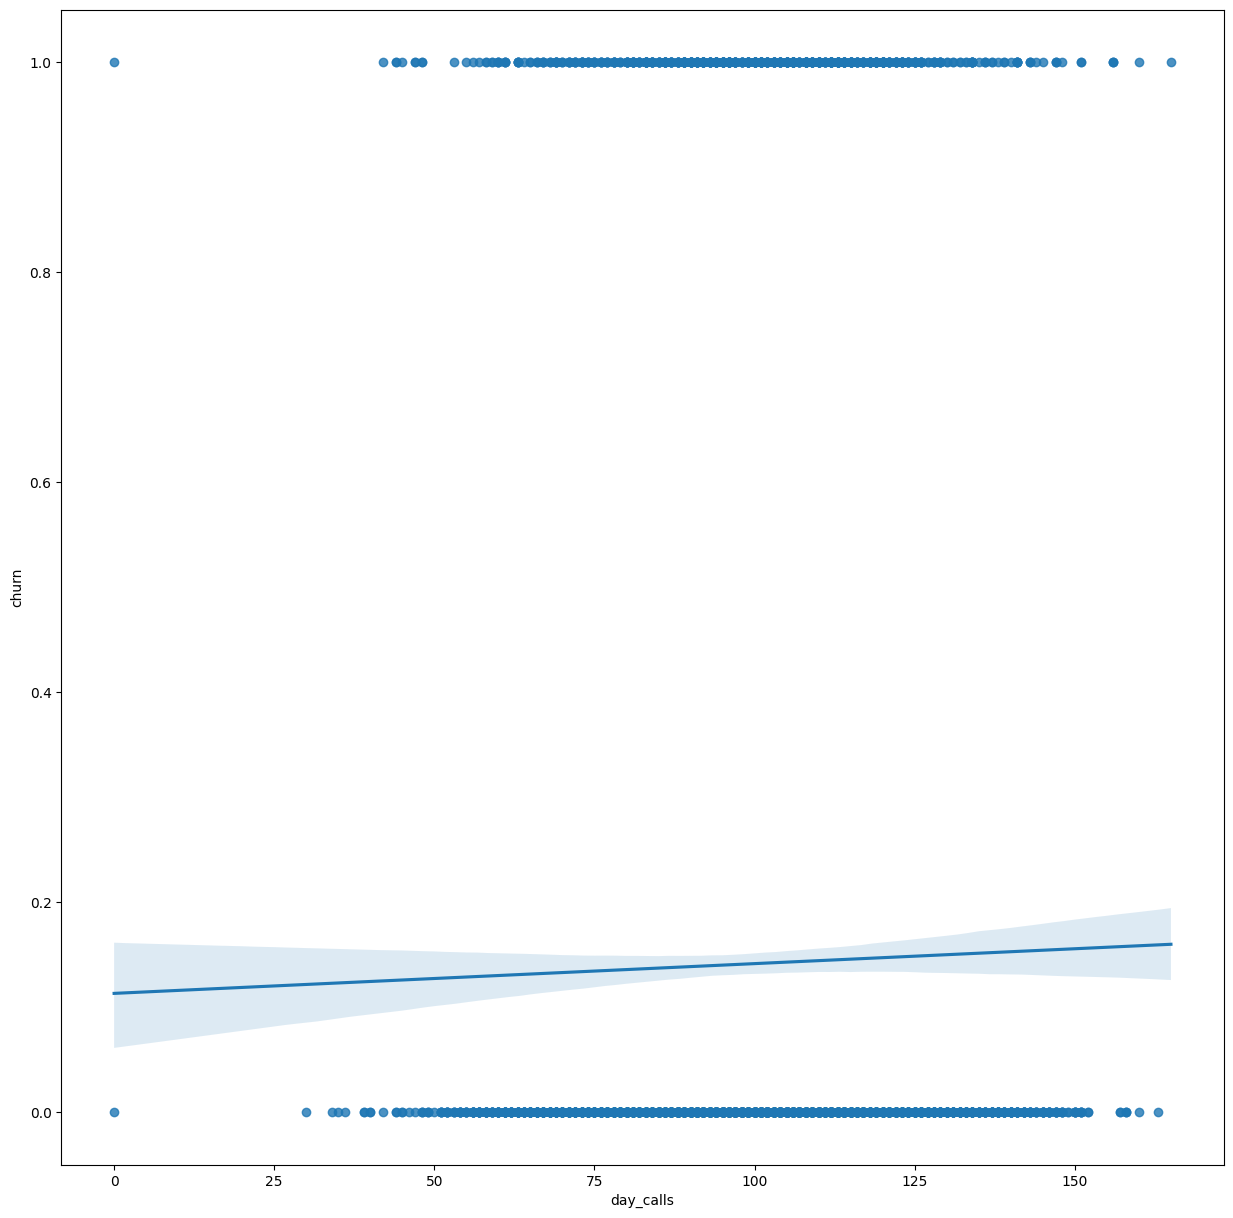

In [ ]:
plt.figure(figsize=(15,15))
sns.regplot(
    x='day_calls',
    y='churn',
    data=df
)
plt.show()

#**`day_charge vs. churn`**

### Insight for 'day_charge' vs. 'churn' Regplot

The regplot showing `day_charge` versus `churn` reveals a **strong positive linear relationship** between the total day charge and the likelihood of churning.

*   **Upward Sloping Trend Line**: The regression line (blue line) has a clear and significant upward slope. This indicates that as the total day charge increases, the predicted probability of churn substantially increases.
*   **Relatively Narrow Confidence Interval**: The shaded area around the regression line (confidence interval) is relatively narrow, especially in the central range of `day_charge`. This suggests a higher degree of certainty in the estimated positive relationship, making `day_charge` a reliable predictor of churn.
*   **Clear Separation at Higher Values**: For customers with very high `day_charge`, there is a noticeable concentration of churners (points at `churn=1`), indicating that exceeding a certain threshold of daily charge strongly correlates with churn.

**Implication**: This insight is crucial. Customers who incur higher daily charges are significantly more likely to churn. Since `day_charge` is directly proportional to `day_mins`, this finding reinforces the importance of `day_mins` as a churn predictor. Potential reasons could include dissatisfaction with billing, perception of high cost for usage, or finding more competitive plans elsewhere. Businesses should investigate the underlying causes of high daily charges leading to churn and consider targeted interventions for this segment, such as personalized pricing plans, usage alerts, or value-added services to justify the cost.

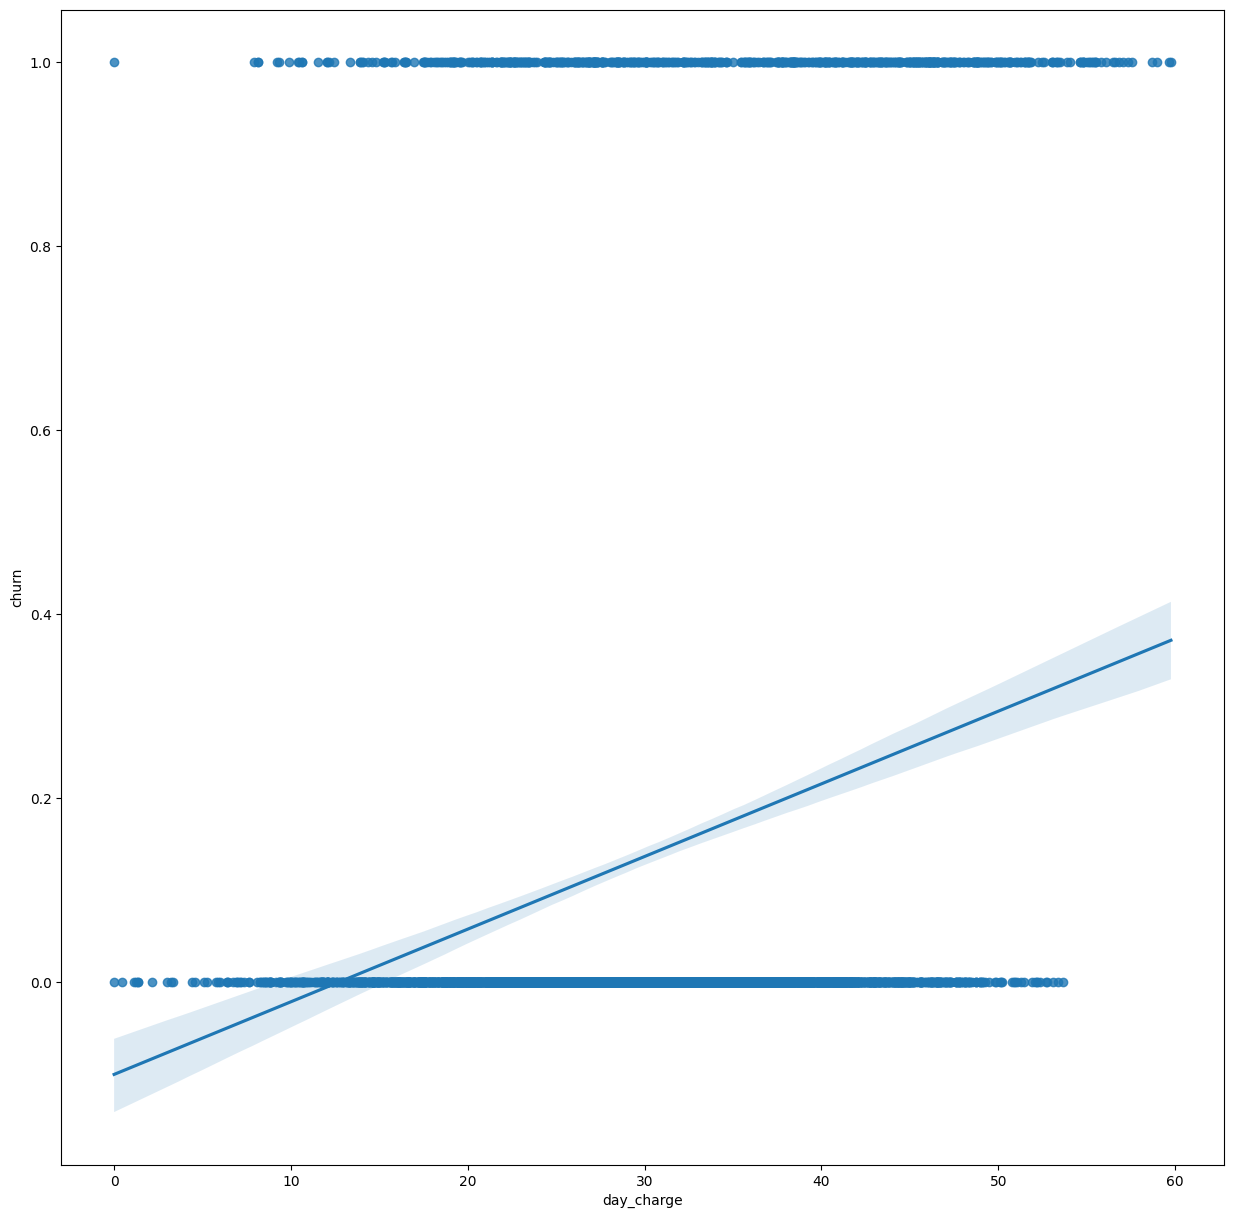

In [ ]:
plt.figure(figsize=(15,15))
sns.regplot(
    x='day_charge',
    y='churn',
    data=df
)
plt.show()

#**`eve_mins vs. churn`**

### Insight for 'eve_mins' vs. 'churn' Regplot

The regplot showing `eve_mins` versus `churn` suggests a **weak positive linear relationship**.

*   **Upward Sloping Trend Line**: The regression line (blue line) shows a slight upward trend. This indicates that as the total evening minutes increase, there is a marginal increase in the predicted probability of churn.
*   **Wide Confidence Interval**: The confidence interval around the regression line is quite broad, especially at the extremes of `eve_mins`. This signifies that the certainty of this positive relationship is low, implying that `eve_mins` alone is not a strong, independent predictor of churn.
*   **Churn Across `eve.mins`**: Churn (points at `churn=1`) and non-churn (points at `churn=0`) customers are observed across the entire range of `eve_mins` values.

**Implication**: While there's a slight tendency for customers with higher evening call minutes to have a slightly increased propensity to churn, this feature does not appear to be a primary driver of churn. The relationship is too weak and uncertain to draw strong conclusions about its direct impact on customer retention.

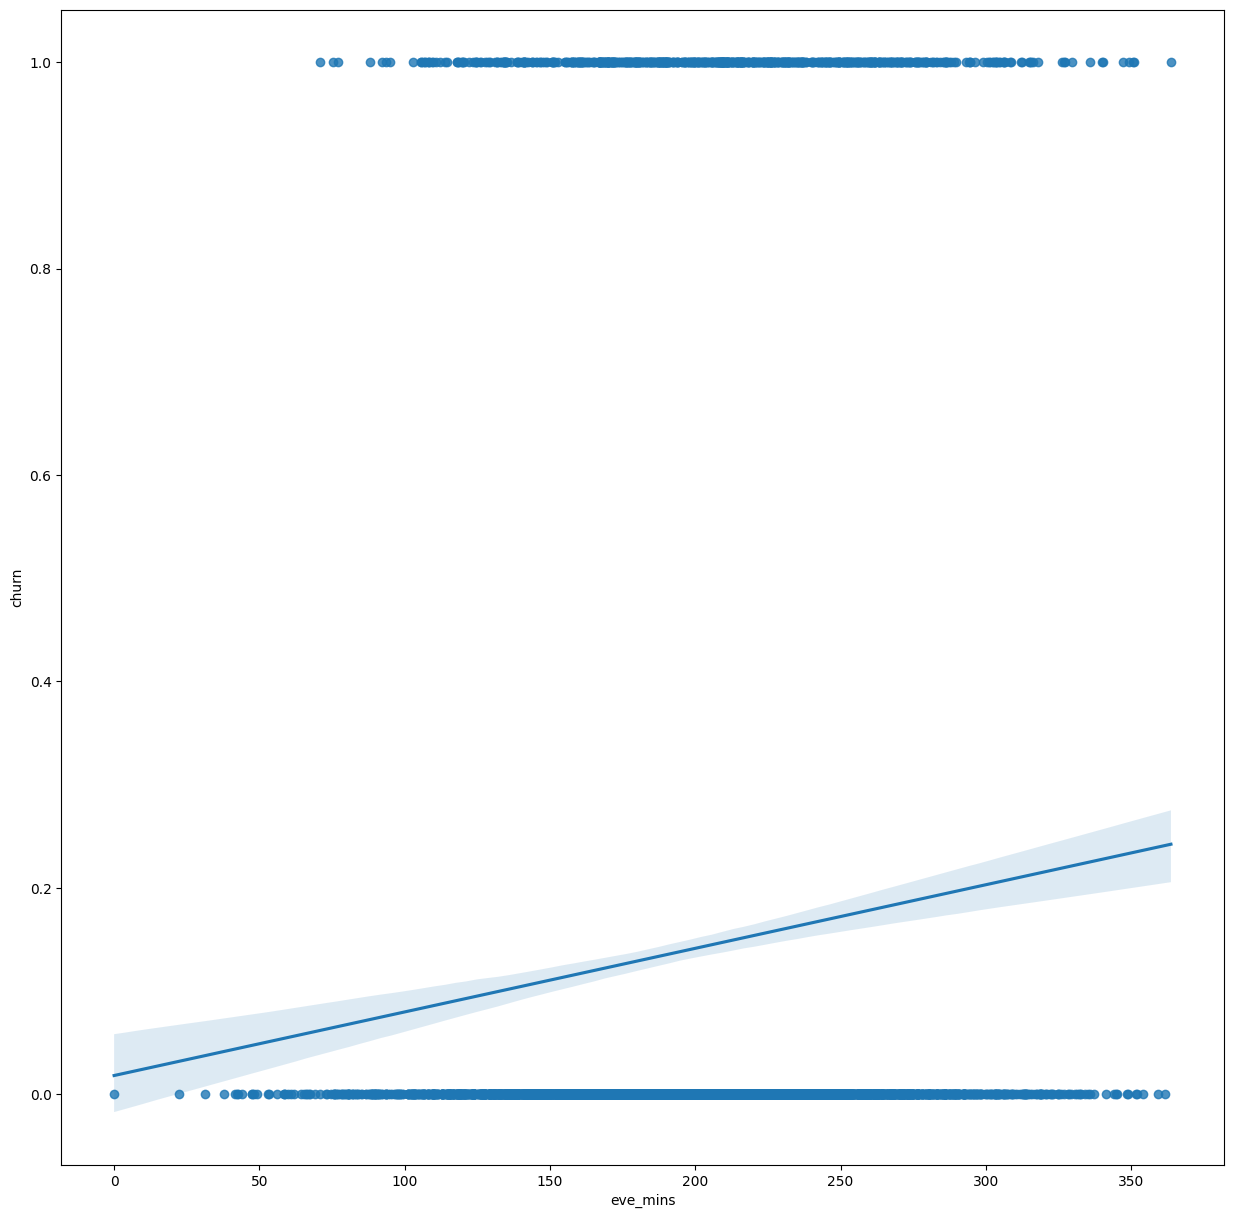

In [ ]:
plt.figure(figsize=(15,15))
sns.regplot(
    x='eve_mins',
    y='churn',
    data=df
)
plt.show()

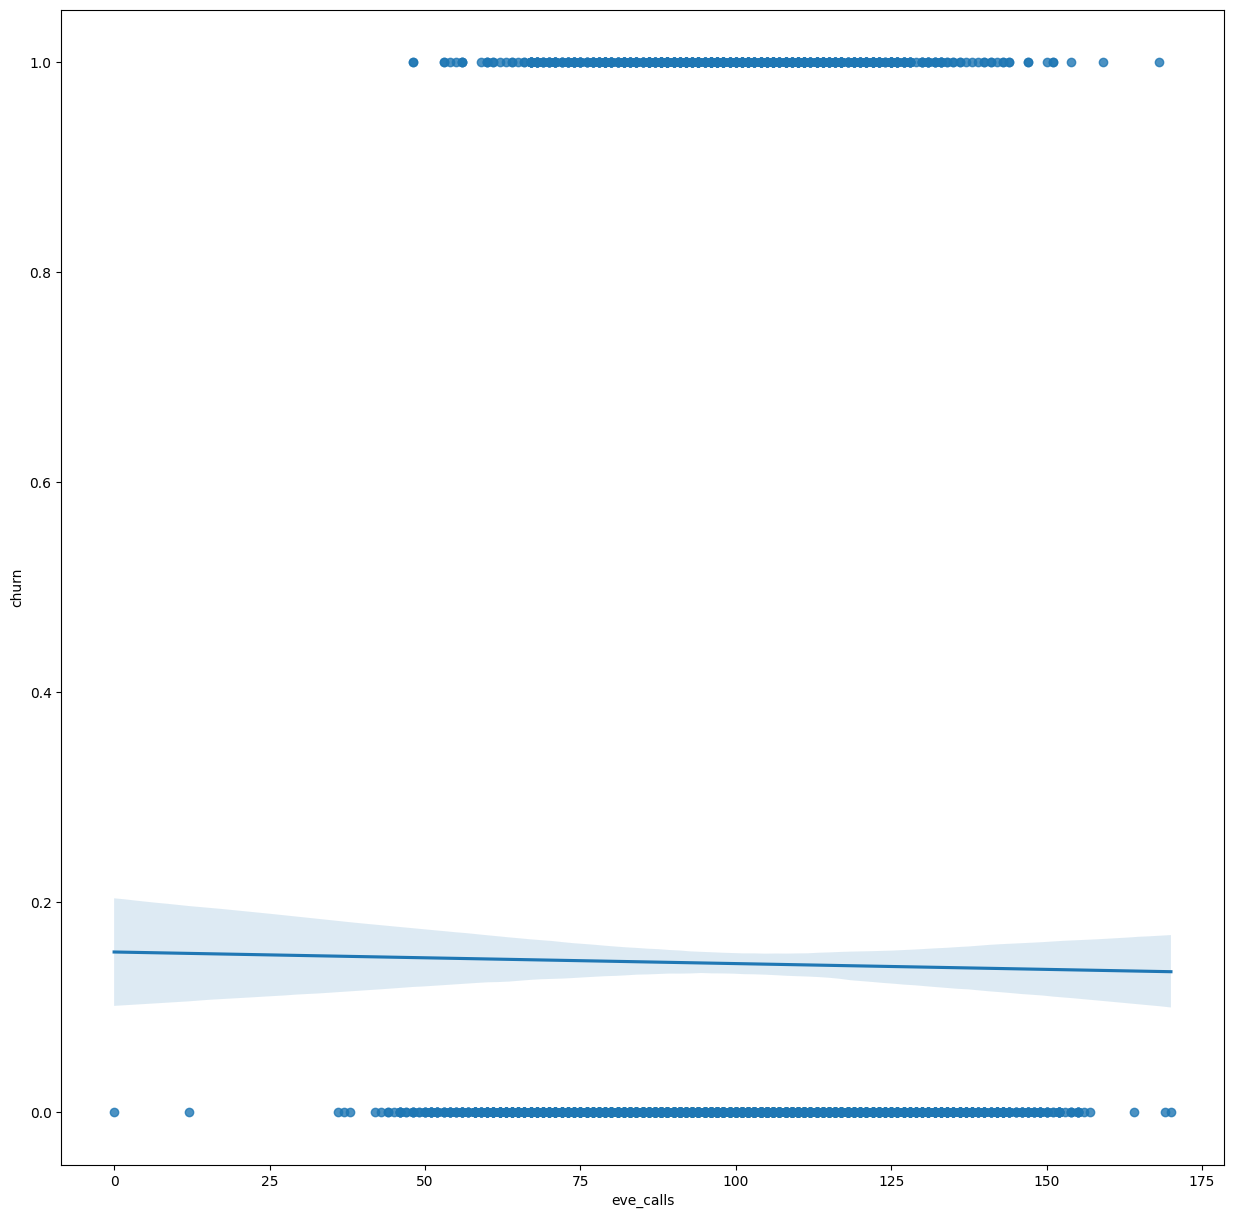

In [ ]:
plt.figure(figsize=(15,15))
sns.regplot(
    x='eve_calls',
    y='churn',
    data=df
)
plt.show()

### Insight for 'eve_calls' vs. 'churn' Regplot

The regplot showing `eve_calls` versus `churn` reveals a **very weak, almost negligible, positive linear relationship** between the number of evening calls and the likelihood of churning.

*   **Flat Trend Line**: The regression line (blue line) is nearly flat, with a minimal upward slope. This suggests that as the number of evening calls increases, there's a very slight, almost imperceptible, increase in the predicted probability of churn.
*   **Wide Confidence Interval**: The shaded area around the regression line (the confidence interval) is quite wide, indicating considerable uncertainty around this estimated relationship. This reinforces the idea that `eve_calls` alone is not a strong predictor of churn.
*   **Churn at All Call Volumes**: Churn (represented by points at `churn=1`) occurs across the entire spectrum of `eve_calls` values. Similarly, non-churners (`churn=0`) are also present at all evening call volumes.

**Implication**: While there might be a minuscule tendency for customers making more evening calls to have a slightly higher churn probability, `eve_calls` by itself does not appear to be a significant factor in determining churn. Other features are likely much more influential in predicting whether a customer will churn or not.

#**`eve_charge vs. churn`**

### Insight for 'eve_charge' vs. 'churn' Regplot

The regplot showing `eve_charge` versus `churn` suggests a **weak positive linear relationship**.

*   **Upward Sloping Trend Line**: The regression line (blue line) shows a slight upward trend. This indicates that as the total evening charge increases, there is a marginal increase in the predicted probability of churn.
*   **Wide Confidence Interval**: The confidence interval around the regression line is quite broad, especially at the extremes of `eve_charge`. This signifies that the certainty of this positive relationship is low, implying that `eve_charge` alone is not a strong, independent predictor of churn.
*   **Churn Across `eve.charge`**: Churn (points at `churn=1`) and non-churn (points at `churn=0`) customers are observed across the entire range of `eve_charge` values.

**Implication**: While there's a slight tendency for customers with higher evening charges to have a slightly increased propensity to churn, this feature does not appear to be a primary driver of churn. The relationship is too weak and uncertain to draw strong conclusions about its direct impact on customer retention.

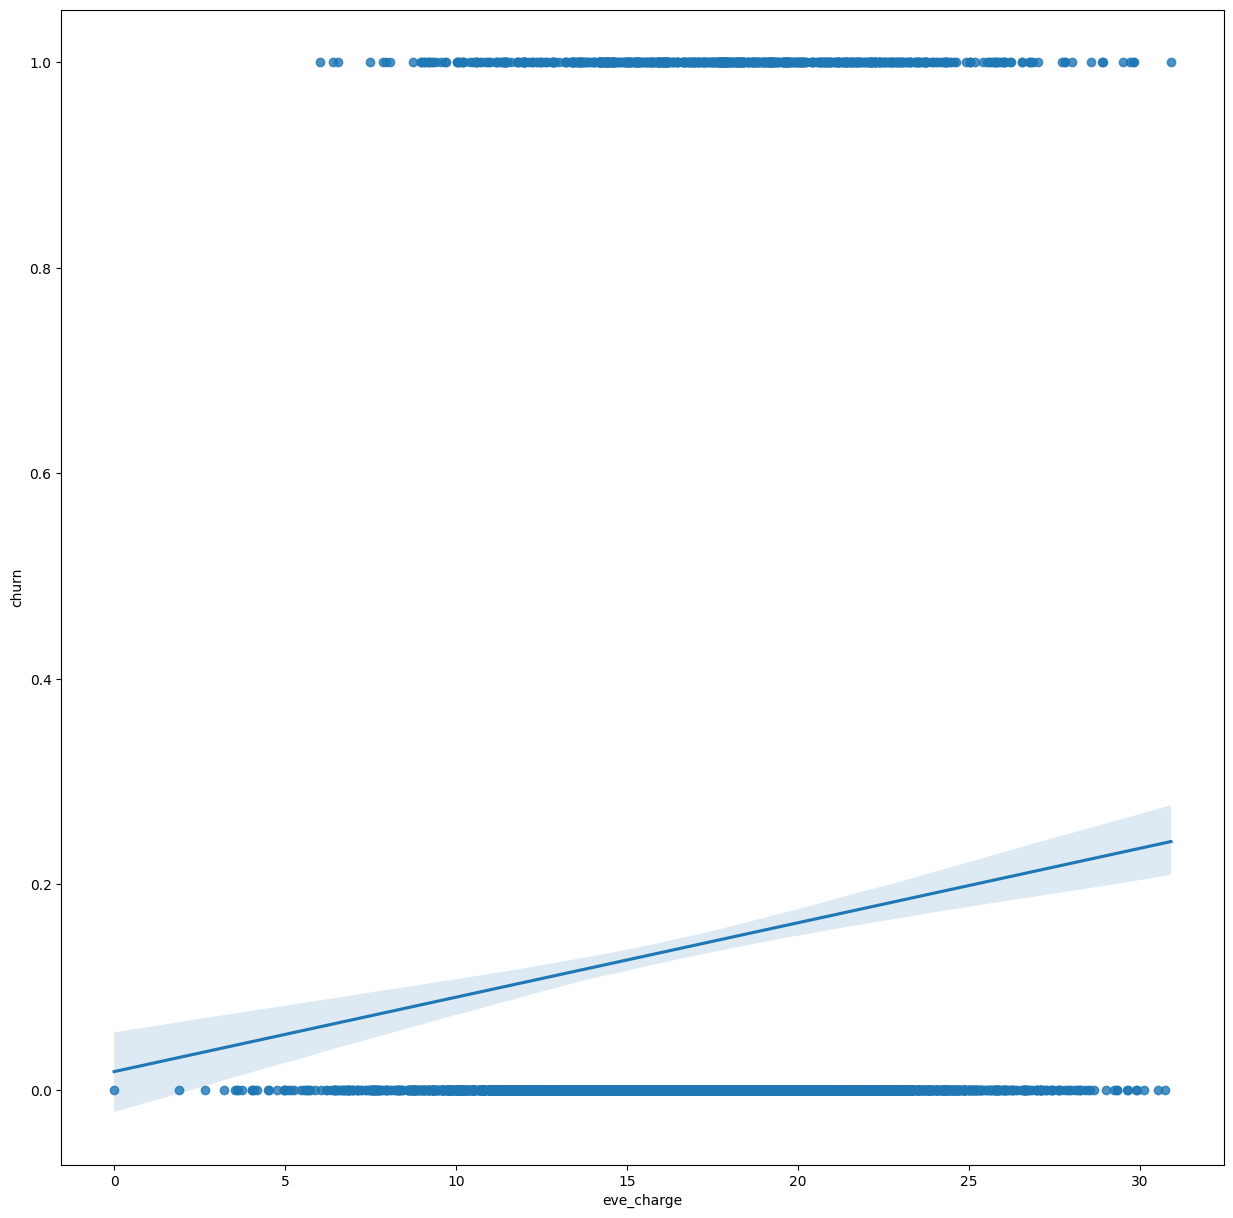

In [ ]:
plt.figure(figsize=(15,15))
sns.regplot(
    x='eve_charge',
    y='churn',
    data=df
)
plt.show()

#**`night_mins vs. churn`**

### Insight for 'night_mins' vs. 'churn' Regplot

The regplot showing `night_mins` versus `churn` suggests a **weak positive linear relationship**.

*   **Upward Sloping Trend Line**: The regression line (blue line) shows a slight upward trend. This indicates that as the total night minutes increase, there is a marginal increase in the predicted probability of churn.
*   **Wide Confidence Interval**: The confidence interval around the regression line is quite broad, especially at the extremes of `night_mins`. This signifies that the certainty of this positive relationship is low, implying that `night_mins` alone is not a strong, independent predictor of churn.
*   **Churn Across `night.mins`**: Churn (points at `churn=1`) and non-churn (points at `churn=0`) customers are observed across the entire range of `night_mins` values.

**Implication**: While there's a slight tendency for customers with higher night call minutes to have a slightly increased propensity to churn, this feature does not appear to be a primary driver of churn. The relationship is too weak and uncertain to draw strong conclusions about its direct impact on customer retention.

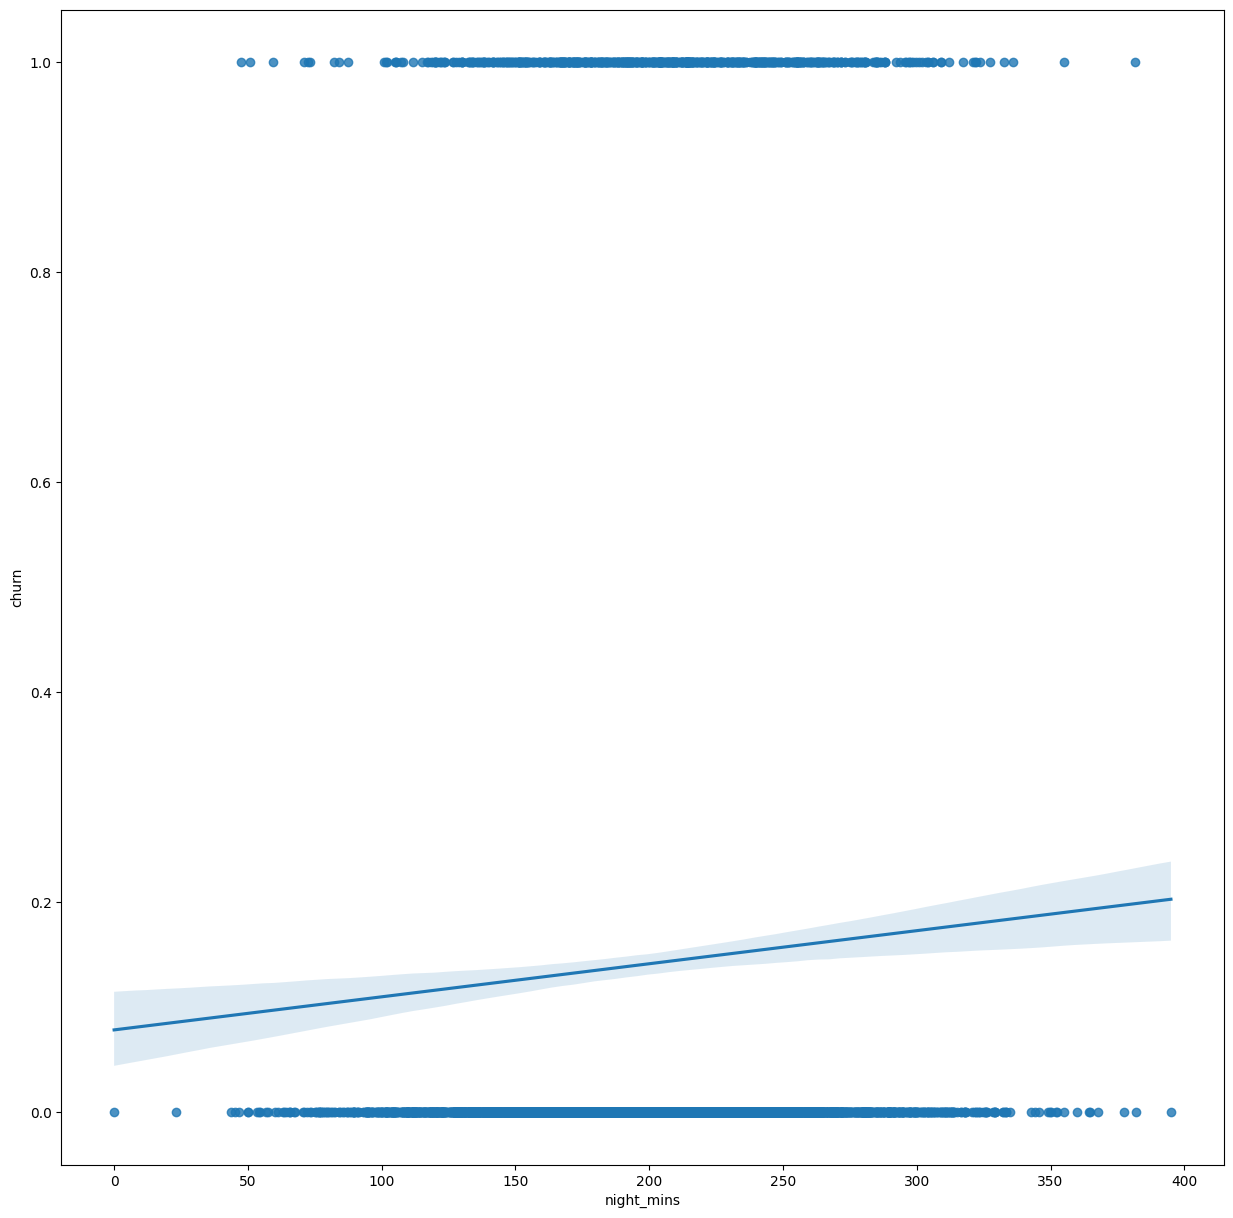

In [ ]:
plt.figure(figsize=(15,15))
sns.regplot(
    x='night_mins',
    y='churn',
    data=df
)
plt.show()

#**`night_calls vs. churn`**

### Insight for 'night_calls' vs. 'churn' Regplot

The regplot showing `night_calls` versus `churn` reveals a **very weak, almost negligible, positive linear relationship**.

*   **Flat Trend Line**: The regression line (blue line) is nearly flat, with a minimal upward slope. This suggests that as the number of night calls increases, there's a very slight, almost imperceptible, increase in the predicted probability of churn.
*   **Wide Confidence Interval**: The shaded area around the regression line (the confidence interval) is quite wide, indicating considerable uncertainty around this estimated relationship. This reinforces the idea that `night_calls` alone is not a strong predictor of churn.
*   **Churn at All Call Volumes**: Churn (represented by points at `churn=1`) occurs across the entire spectrum of `night_calls` values. Similarly, non-churners (`churn=0`) are also present at all night call volumes.

**Implication**: While there might be a minuscule tendency for customers making more night calls to have a slightly higher churn probability, `night_calls` by itself does not appear to be a significant factor in determining churn. Other features are likely much more influential in predicting whether a customer will churn or not.

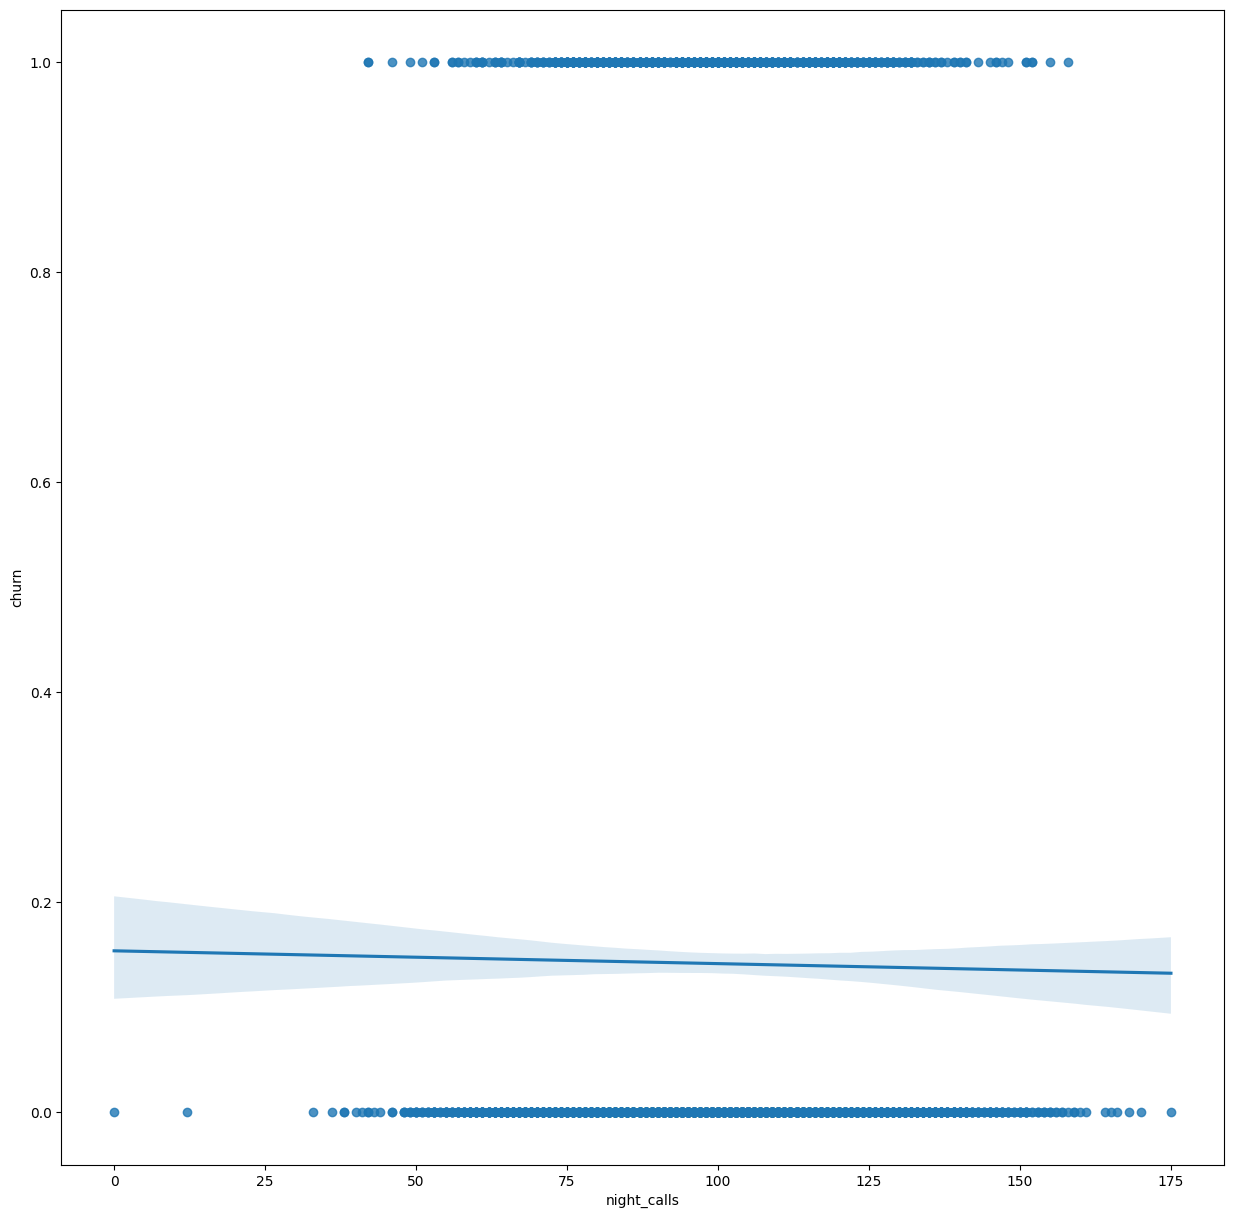

In [ ]:
plt.figure(figsize=(15,15))
sns.regplot(
    x='night_calls',
    y='churn',
    data=df
)
plt.show()

### Insight for 'night_charge' vs. 'churn' Regplot

The regplot showing `night_charge` versus `churn` reveals a **weak positive linear relationship**.

*   **Upward Sloping Trend Line**: The regression line (blue line) shows a slight upward trend. This indicates that as the total night charge increases, there is a marginal increase in the predicted probability of churn.
*   **Wide Confidence Interval**: The confidence interval around the regression line is quite broad, especially at the extremes of `night_charge`. This signifies that the certainty of this positive relationship is low, implying that `night_charge` alone is not a strong, independent predictor of churn.
*   **Churn Across `night.charge`**: Churn (points at `churn=1`) and non-churn (points at `churn=0`) customers are observed across the entire range of `night_charge` values.

**Implication**: While there's a slight tendency for customers with higher night charges to have a slightly increased propensity to churn, this feature does not appear to be a primary driver of churn. The relationship is too weak and uncertain to draw strong conclusions about its direct impact on customer retention.

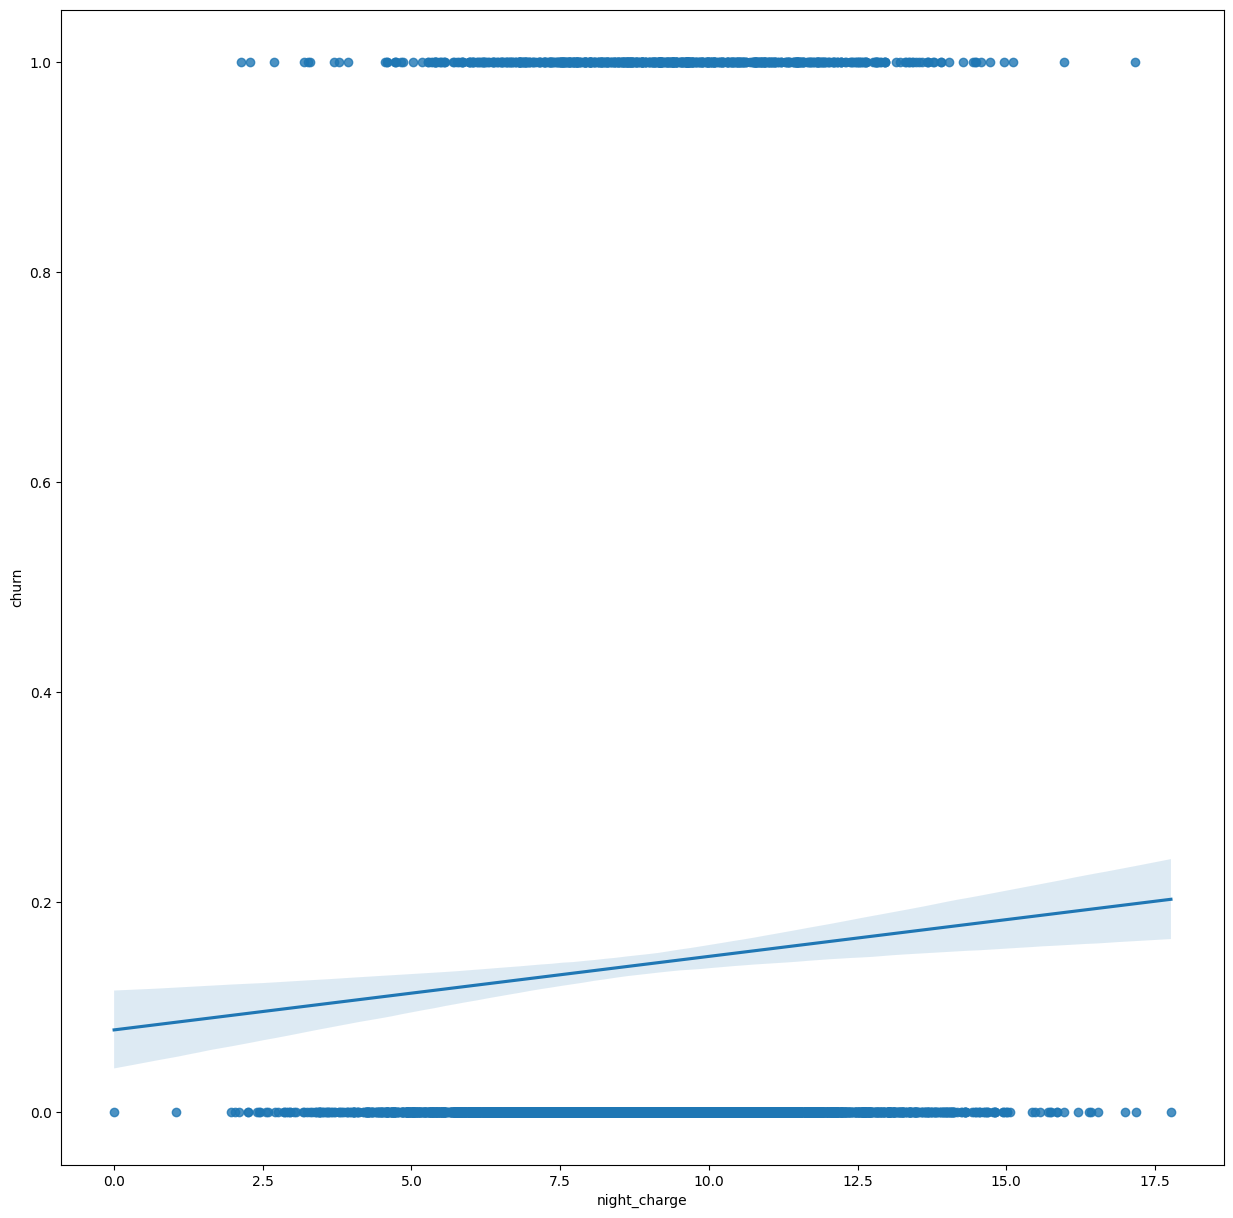

In [ ]:
plt.figure(figsize=(15,15))
sns.regplot(
    x='night_charge',
    y='churn',
    data=df
)
plt.show()

### Insight for 'night_charge' vs. 'churn' Regplot

The regplot showing `night_charge` versus `churn` reveals a **weak positive linear relationship**.

*   **Upward Sloping Trend Line**: The regression line (blue line) shows a slight upward trend. This indicates that as the total night charge increases, there is a marginal increase in the predicted probability of churn.
*   **Wide Confidence Interval**: The confidence interval around the regression line is quite broad, especially at the extremes of `night_charge`. This signifies that the certainty of this positive relationship is low, implying that `night_charge` alone is not a strong, independent predictor of churn.
*   **Churn Across `night.charge`**: Churn (points at `churn=1`) and non-churn (points at `churn=0`) customers are observed across the entire range of `night_charge` values.

**Implication**: While there's a slight tendency for customers with higher night charges to have a slightly increased propensity to churn, this feature does not appear to be a primary driver of churn. The relationship is too weak and uncertain to draw strong conclusions about its direct impact on customer retention.

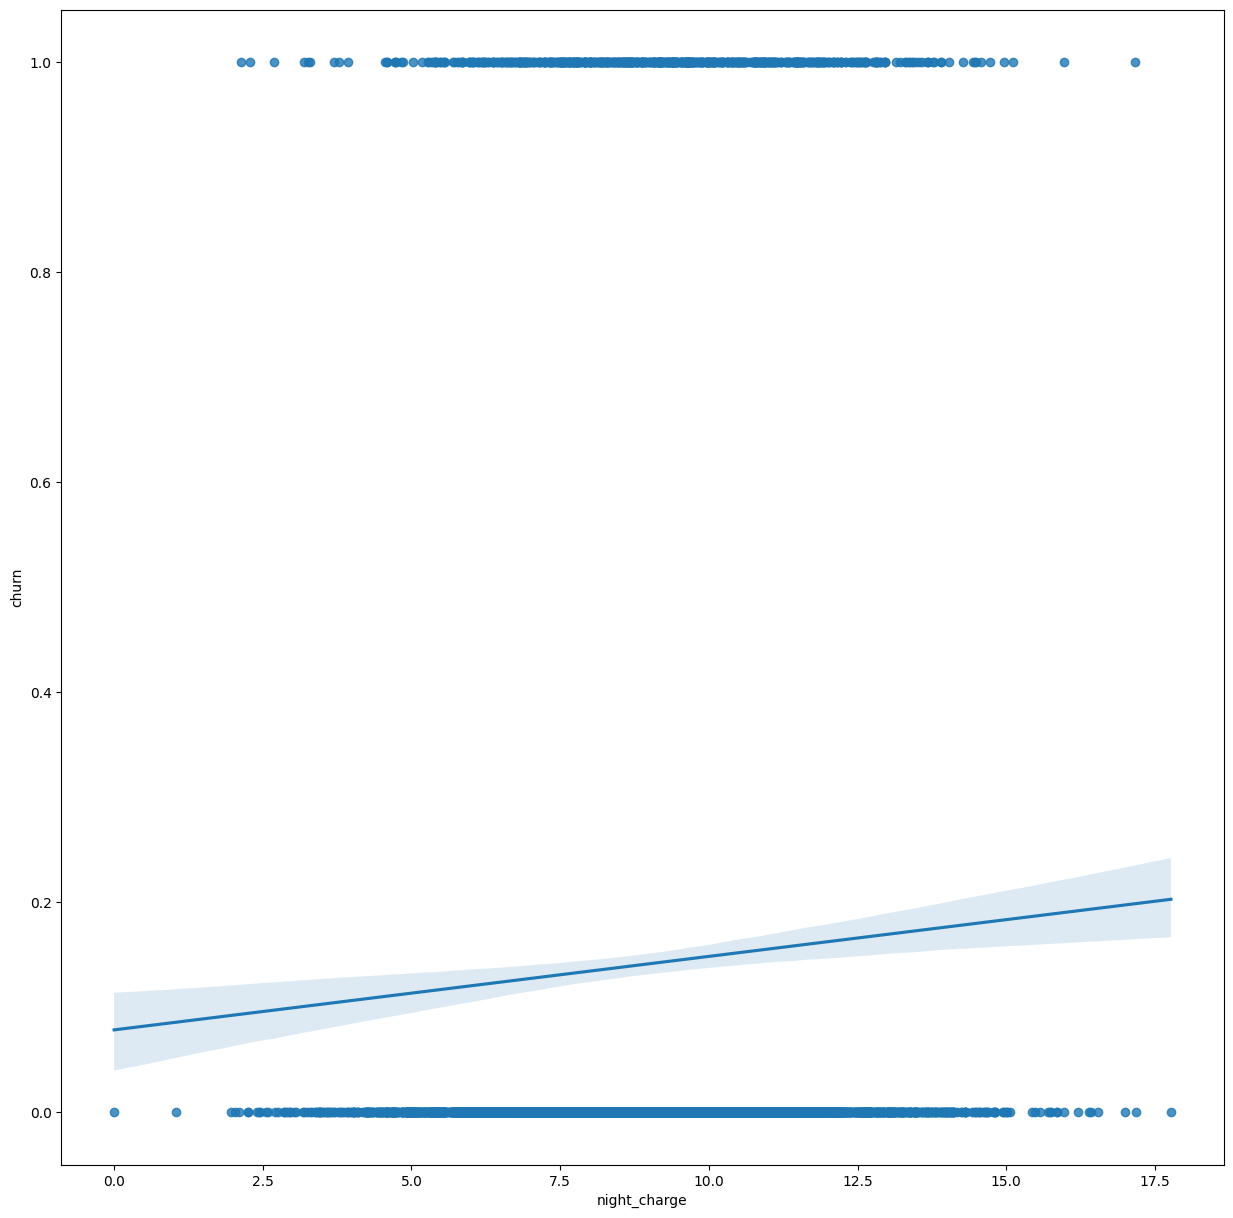

In [ ]:
plt.figure(figsize=(15,15))
sns.regplot(
    x='night_charge',
    y='churn',
    data=df
)
plt.show()

#**`customer_calls vs. churn`**

### Insight for 'customer_calls' vs. 'churn' Regplot

The regplot showing `customer_calls` versus `churn` reveals a **strong positive linear relationship**.

*   **Upward Sloping Trend Line**: The regression line (blue line) has a clear and significant upward slope. This indicates that as the number of customer calls increases, the predicted probability of churn substantially increases.
*   **Relatively Narrow Confidence Interval**: The shaded area around the regression line (confidence interval) is relatively narrow, especially in the central range of `customer_calls`. This suggests a higher degree of certainty in the estimated positive relationship, making `customer_calls` a reliable predictor of churn.
*   **Clear Separation at Higher Values**: For customers with a higher number of customer calls, there is a noticeable concentration of churners (points at `churn=1`), indicating that exceeding a certain threshold of customer service interactions strongly correlates with churn.

**Implication**: This is a crucial insight. Customers who make more customer service calls are significantly more likely to churn. This could be due to various reasons, such as unresolved issues, persistent problems with the service, or general dissatisfaction leading to repeated complaints. Businesses should investigate the underlying causes of high customer call volumes for these churning customers and implement targeted interventions to resolve issues proactively and improve customer satisfaction.

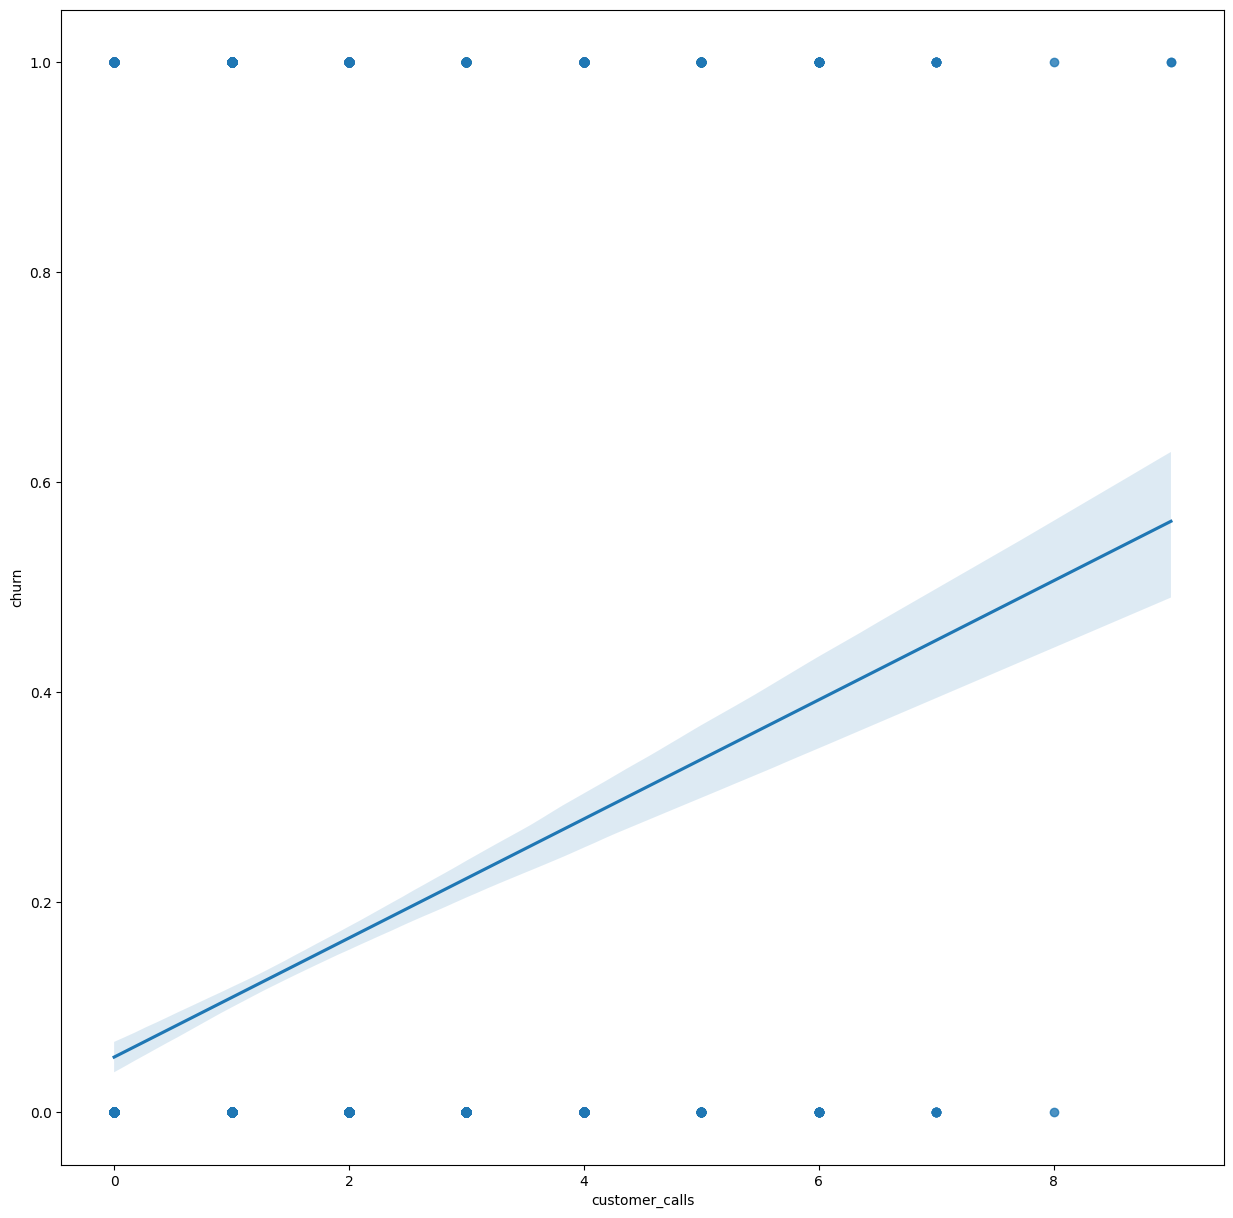

In [ ]:
plt.figure(figsize=(15,15))
sns.regplot(
    x='customer_calls',
    y='churn',
    data=df
)
plt.show()

#*2*)**Categorical Feature**

#**`State vs Churn`**

### Insight for 'state' vs. 'churn' Countplot

The countplot showing `state` versus `churn` reveals that churn is generally present across **all states**, but with varying proportions.

*   **Universal Churn**: Every state exhibits some level of customer churn, indicated by the presence of both 'no' (blue) and 'yes' (orange) bars for each state.
*   **No Single High-Churn State Dominance**: There isn't one particular state that stands out as having an overwhelmingly higher absolute number of churned customers compared to others. The number of churned customers (`yes` in orange) appears relatively consistent across most states, hovering around 10-25 per state.
*   **Proportional Churn Varies**: While absolute numbers are somewhat consistent, the *proportion* of churn within each state might vary. For instance, a state with fewer overall customers but a similar number of churners might have a higher churn rate than a state with many customers and the same number of churners.
*   **Potential for Deeper Dive**: To gain more granular insights, one could analyze the *churn rate* (percentage of churners) per state. This would help identify states where churn is a more significant issue relative to their customer base, potentially indicating regional service, competition, or demographic factors at play.

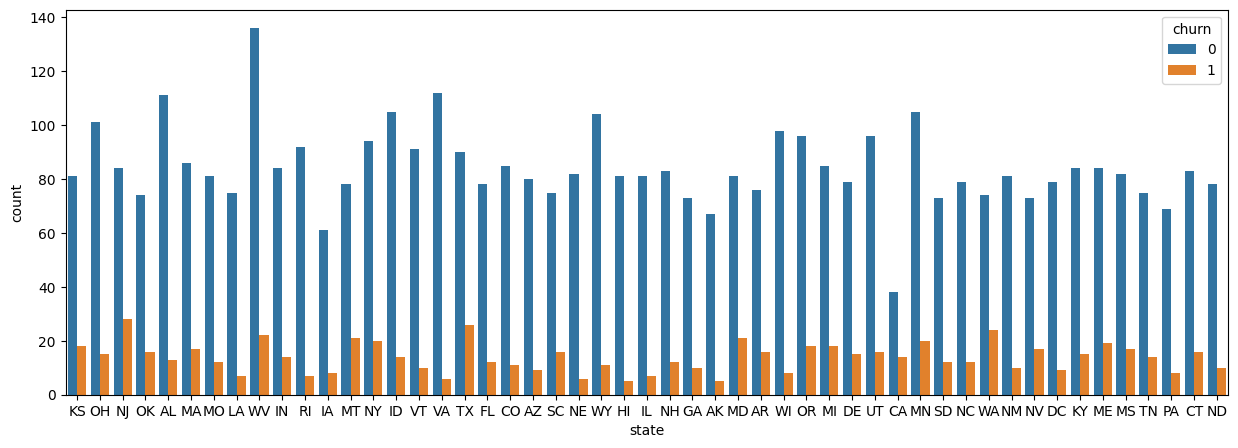

In [ ]:
plt.figure(figsize=(15,5))
sns.countplot(
    x='state',
    hue='churn',
    data=df
)
plt.show()

#**`area_code vs churn`**

### Insight for 'area_code' vs. 'churn' Countplot

The countplot showing `area_code` versus `churn` reveals an interesting interaction with the previously observed imbalance in `area_code`.

*   **Dominant Area Code (415) and Absolute Churners**: `area_code_415` has the largest number of customers. Consequently, it also has the highest **absolute number** of churned customers (the orange bar is tallest for `area_code_415`).
*   **Proportional Churn Rate Appears Consistent**: Despite the difference in the total customer count, the *proportion* of churned customers (orange bar) relative to non-churned customers (blue bar) appears to be **visually similar** across all three area codes (`415`, `408`, `510`). This suggests that while `area_code_415` contributes the most churners in terms of raw numbers, its churn *rate* might not be significantly higher than the other area codes.
*   **Implication for Churn Reduction**: This consistency in proportional churn across area codes suggests that general churn reduction strategies (e.g., improving customer service, optimizing pricing plans, enhancing network quality) could be effective across the entire customer base, rather than requiring highly localized interventions for specific area codes. However, given the larger customer base in `area_code_415`, even a small reduction in churn rate there would yield a significant impact on the total number of churned customers.

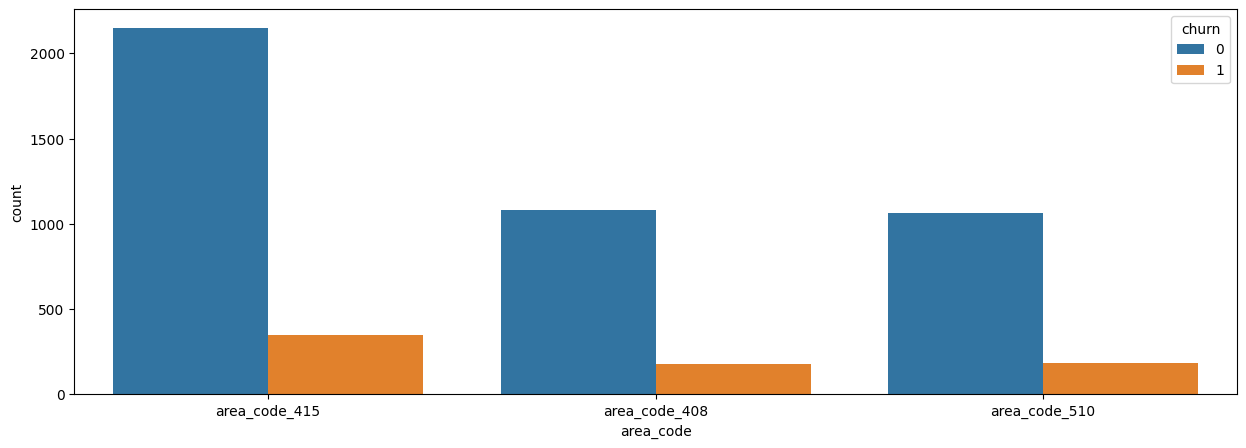

In [ ]:
plt.figure(figsize=(15,5))
sns.countplot(
    x='area_code',
    hue='churn',
    data=df
)
plt.show()

#**`'voice_plan' vs. 'churn'`**

### Insight for 'voice_plan' vs. 'churn' Countplot

The countplot showing `voice_plan` versus `churn` reveals a strong and actionable relationship:

*   **Higher Churn Among Those Without a Voice Plan**: The most striking observation is that customers who **do not** have a voice plan ('no' on the x-axis) have a significantly higher absolute number of churners (orange bar) compared to those with a voice plan ('yes' on the x-axis).
*   **Lower Churn Among Those With a Voice Plan**: Conversely, customers who **do** have a voice plan exhibit a much lower absolute number of churners. This suggests that having a voice plan might be a factor that contributes to customer retention.
*   **Proportional Churn Rate Difference**: While the 'no' voice plan category has a larger overall customer base, the *proportion* of churners within this group appears to be notably higher than the proportional churn in the 'yes' voice plan group. This implies that not having a voice plan could be a significant risk factor for churn.
*   **Implication for Business Strategy**: This insight is crucial for retention strategies. Offering incentives or clearly communicating the value of voice plans to customers without them could potentially reduce churn. It might also be beneficial to analyze the characteristics of churners within the 'no' voice plan group to understand other contributing factors.

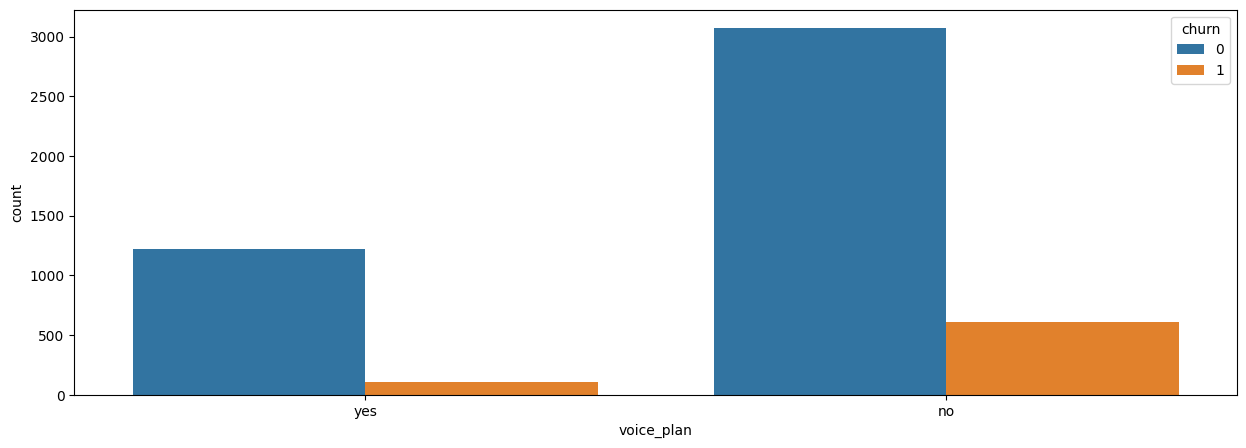

In [ ]:
plt.figure(figsize=(15,5))
sns.countplot(
    x='voice_plan',
    hue='churn',
    data=df
)
plt.show()

#**`intl_plan vs churn`**

###**Insight for 'intl_plan' Countplot**


The countplot for intl.plan reveals a significant imbalance in the distribution of customers with and without an international plan.

**Majority Without International Plan**: A large majority of customers (approximately 4500) do not have an international plan, represented by the 'no' category.
Minority With International.

**Plan**: A much smaller proportion of customers (approximately 500) do have an international plan, represented by the 'yes' category.
This imbalance is an important factor for business strategy and predictive modeling:

**Marketing Opportunity**: There's a clear opportunity to market international plans to the vast majority of customers who currently don't have one.
Product Perception: Further analysis could investigate reasons for low adoption, such as perceived value, cost, or awareness.

**Class Imbalance in Modeling**: Similar to the voice.plan feature, this strong imbalance in intl.plan must be addressed during model training to avoid bias towards the majority class (e.g., using oversampling, undersampling, or weighted algorithms).

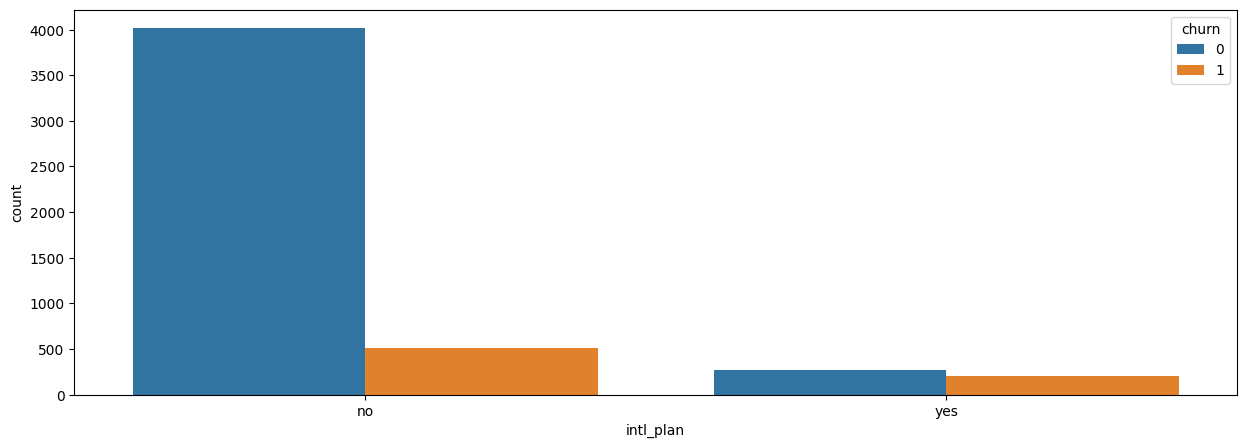

In [ ]:
plt.figure(figsize=(15,5))
sns.countplot(
    x='intl_plan',
    hue='churn',
    data=df
)
plt.show()

### Features with Significant Impact on Churn:

*   **`day_mins`**: Shows a **strong positive linear relationship** with churn. Customers who spend more minutes on day calls are significantly more likely to churn.
*   **`day_charge`**: Exhibits a **strong positive linear relationship** with churn. Higher daily charges are strongly correlated with an increased likelihood of churn.
*   **`customer_calls`**: Reveals a **strong positive linear relationship** with churn. Customers who make more customer service calls are significantly more likely to churn.
*   **`voice_plan`**: Displays a **strong and actionable relationship**. Customers who **do not** have a voice plan have a significantly higher absolute number of churners, suggesting that having a voice plan might contribute to retention.
*   **`intl_plan`**: Shows a **significant imbalance** where customers **with** an international plan appear to have a higher proportional churn rate compared to those without.

# Categorical Feature Encoding

**Binarry features**

In [ ]:
df['voice_plan'] = df['voice_plan'].map({'no': 0, 'yes': 1})
df['intl_plan'] = df['intl_plan'].map({'no': 0, 'yes': 1})

In [ ]:
df.head()

,Unnamed: 0,state,area_code,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,...,day_calls,day_charge,eve_mins,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn
0,1,KS,area_code_415,128,1,25,0,10.0,3,2.70,...,110,45.07,197.4,99,16.78,244.7,91,11.01,1,0
1,2,OH,area_code_415,107,1,26,0,13.7,3,3.70,...,123,27.47,195.5,103,16.62,254.4,103,11.45,1,0
2,3,NJ,area_code_415,137,0,0,0,12.2,5,3.29,...,114,41.38,121.2,110,10.30,162.6,104,7.32,0,0
3,4,OH,area_code_408,84,0,0,1,6.6,7,1.78,...,71,50.90,61.9,88,5.26,196.9,89,8.86,2,0
4,5,OK,area_code_415,75,0,0,1,10.1,3,2.73,...,113,28.34,148.3,122,12.61,186.9,121,8.41,3,0


In [ ]:
le = LabelEncoder()
df['state']=le.fit_transform(df['state'])

In [ ]:
df = pd.get_dummies(df, columns=['area_code'], prefix='area')

In [ ]:
display(df.head())

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
0,1,16,128,1,25,0,10.0,3,2.70,265.1,...,99,16.78,244.7,91,11.01,1,0,False,True,False
1,2,35,107,1,26,0,13.7,3,3.70,161.6,...,103,16.62,254.4,103,11.45,1,0,False,True,False
2,3,31,137,0,0,0,12.2,5,3.29,243.4,...,110,10.30,162.6,104,7.32,0,0,False,True,False
3,4,35,84,0,0,1,6.6,7,1.78,299.4,...,88,5.26,196.9,89,8.86,2,0,True,False,False
4,5,36,75,0,0,1,10.1,3,2.73,166.7,...,122,12.61,186.9,121,8.41,3,0,False,True,False


In [ ]:
df['area_area_code_408'] = df['area_area_code_408'].astype(int)
df['area_area_code_415'] = df['area_area_code_415'].astype(int)
df['area_area_code_510'] = df['area_area_code_510'].astype(int)

In [ ]:
display(df.dtypes)

,0
Unnamed: 0,int64
state,int64
account_length,int64
voice_plan,int64
voice_messages,int64
intl_plan,int64
intl_mins,float64
intl_calls,int64
intl_charge,float64
day_mins,float64


In [ ]:
df.head()

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
0,1,16,128,1,25,0,10.0,3,2.70,265.1,...,99,16.78,244.7,91,11.01,1,0,0,1,0
1,2,35,107,1,26,0,13.7,3,3.70,161.6,...,103,16.62,254.4,103,11.45,1,0,0,1,0
2,3,31,137,0,0,0,12.2,5,3.29,243.4,...,110,10.30,162.6,104,7.32,0,0,0,1,0
3,4,35,84,0,0,1,6.6,7,1.78,299.4,...,88,5.26,196.9,89,8.86,2,0,1,0,0
4,5,36,75,0,0,1,10.1,3,2.73,166.7,...,122,12.61,186.9,121,8.41,3,0,0,1,0


# Handling Outliers

In [ ]:
# Outlier Detection: User defined Function to calculate Upper Extreme and Lower Extreme value
def outlier_detection(data,colname):
  q1 = data[colname].quantile(0.25)
  q3 = data[colname].quantile(0.75)
  iqr = q3 - q1

  upper_extreme = q3 + (1.5 * iqr)
  lower_extreme = q1 - (1.5 * iqr)

  return lower_extreme, upper_extreme

`account_length`

In [ ]:
outlier_detection(df,'account_length')

(np.float64(-8.0), np.float64(208.0))

In [ ]:
df[df['account_length']<-8.0]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
# There  are 24 records that are above upper extreme
df[df['account_length']>208]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
238,239,50,215,0,0,0,10.7,9,2.89,83.6,...,91,10.28,226.6,110,10.20,0,0,0,0,1
309,310,41,209,0,0,0,8.9,4,2.40,227.2,...,92,21.96,183.5,74,8.26,3,0,0,1,0
416,417,8,224,0,0,1,5.0,2,1.35,171.5,...,103,13.60,212.4,102,9.56,1,1,0,0,1
817,818,44,243,0,0,0,6.6,6,1.78,95.5,...,63,13.91,264.2,118,11.89,2,0,0,0,1
1045,1046,43,217,0,0,0,9.3,3,2.51,176.4,...,128,13.50,306.6,107,13.80,4,0,1,0,0
1093,1094,45,210,0,0,0,6.5,8,1.76,104.6,...,71,12.71,255.1,67,11.48,2,0,1,0,0
1387,1388,6,212,0,0,0,7.6,3,2.05,126.0,...,80,12.27,302.8,102,13.63,1,0,0,1,0
1408,1409,32,232,0,0,0,11.8,3,3.19,165.6,...,115,16.65,118.3,77,5.32,1,0,1,0,0
1551,1552,22,225,0,0,0,8.7,3,2.35,165.4,...,109,23.26,210.0,93,9.45,0,1,0,1,0
1751,1752,50,225,0,0,0,8.8,2,2.38,182.7,...,63,20.95,218.0,103,9.81,1,0,0,1,0


In [ ]:
df.loc[df['account_length']>208,'account_length'] = 208

In [ ]:
# There  are 24 records that are above upper extreme
df[df['account_length']>208]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
outlier_detection(df,'voice_messages')

(np.float64(-25.5), np.float64(42.5))

In [ ]:
df[df['voice_messages']<-25.5]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
df[df['voice_messages']>42.5]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
71,72,23,162,1,46,0,12.1,2,3.27,224.9,...,84,16.00,254.6,61,11.46,0,0,0,0,1
149,150,39,145,1,43,0,11.1,4,3.00,257.7,...,95,13.78,286.9,86,12.91,2,0,1,0,0
268,269,24,64,1,48,0,4.5,4,1.22,94.4,...,101,11.58,147.4,89,6.63,0,0,0,0,1
277,278,41,144,1,48,0,6.5,2,1.76,189.8,...,67,10.49,214.2,106,9.64,2,1,1,0,0
423,424,15,96,1,45,0,10.3,2,2.78,248.8,...,77,11.93,263.6,102,11.86,3,0,0,1,0
599,600,35,75,1,46,0,9.2,6,2.48,214.1,...,111,17.08,246.8,126,11.11,0,0,0,0,1
615,616,44,48,1,43,0,8.0,5,2.16,172.0,...,64,17.02,233.1,96,10.49,1,0,0,0,1
790,791,3,92,1,45,1,7.5,3,2.03,281.1,...,103,16.83,94.3,76,4.24,0,0,0,1,0
845,846,9,144,1,51,0,10.0,4,2.70,283.9,...,109,16.32,196.3,85,8.83,1,0,0,1,0
872,873,36,149,1,43,0,10.9,3,2.94,206.7,...,122,14.84,241.5,80,10.87,1,0,0,0,1


In [ ]:
df.loc[df['voice_messages']>42.5,'voice_messages'] = 42.5

/tmp/ipykernel_5462/2956087910.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '42.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['voice_messages']>42.5,'voice_messages'] = 42.5


In [ ]:
df[df['voice_messages']>42.5]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
outlier_detection(df,'intl_mins')

(np.float64(3.25), np.float64(17.25))

In [ ]:
df[df['intl_mins']<3.25]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
179,180,16,70,0,0.0,0,0.0,0,0.00,232.1,...,112,24.85,201.2,112,9.05,3,0,1,0,0
225,226,15,65,0,0.0,0,2.7,4,0.73,213.4,...,94,19.93,250.1,123,11.25,1,0,0,1,0
343,344,15,98,1,21.0,0,0.0,0,0.00,64.6,...,86,14.97,244.8,84,11.02,2,0,1,0,0
397,398,37,94,0,0.0,0,2.0,2,0.54,234.4,...,109,23.74,234.2,121,10.54,1,1,0,1,0
488,489,46,165,0,0.0,0,0.0,0,0.00,242.9,...,65,17.83,228.4,126,10.28,1,0,0,0,1
595,596,11,87,1,28.0,0,0.0,0,0.00,151.4,...,97,12.95,250.1,109,11.25,1,0,1,0,0
712,713,24,106,0,0.0,0,0.0,0,0.00,114.4,...,101,6.66,232.7,78,10.47,2,0,0,1,0
762,763,50,161,0,0.0,1,1.3,6,0.35,189.6,...,117,22.73,184.5,137,8.30,1,0,0,1,0
878,879,48,62,0,0.0,0,0.0,0,0.00,281.0,...,108,13.65,77.9,74,3.51,1,0,0,1,0
1028,1029,16,70,0,0.0,0,0.0,0,0.00,222.8,...,113,18.35,223.5,122,10.06,1,0,0,1,0


In [ ]:
df[df['intl_mins']>17.25]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
115,116,21,36,1,42.0,1,20.0,6,5.40,196.8,...,122,21.67,138.3,126,6.22,0,1,0,0,1
214,215,9,70,0,0.0,1,17.6,4,4.75,226.7,...,115,19.39,73.2,93,3.29,2,1,0,0,1
314,315,13,128,0,0.0,0,18.9,2,5.10,125.2,...,107,17.46,254.4,111,11.45,0,0,1,0,0
367,368,20,45,0,0.0,0,18.0,3,4.86,78.2,...,108,21.54,255.0,100,11.48,1,0,0,1,0
502,503,22,93,0,0.0,1,17.5,5,4.73,216.9,...,120,17.63,221.7,110,9.98,1,1,0,1,0
515,516,13,148,1,14.0,0,17.5,5,4.73,93.6,...,72,16.47,144.9,84,6.52,1,0,0,0,1
535,536,29,194,0,0.0,0,18.2,1,4.91,48.4,...,138,23.89,218.5,87,9.83,1,0,1,0,0
1257,1258,44,73,0,0.0,0,18.0,5,4.86,182.3,...,97,16.93,120.2,113,5.41,1,0,0,1,0
1420,1421,22,81,0,0.0,1,17.9,3,4.83,149.4,...,98,14.61,214.5,97,9.65,3,1,0,1,0
1570,1571,29,112,0,0.0,0,17.3,3,4.67,167.6,...,90,13.13,281.4,107,12.66,2,0,0,1,0


In [ ]:
df.loc[df['intl_mins']<3.25,'intl_mins'] = 3.25

In [ ]:
df.loc[df['intl_mins']>17.25,'intl_mins'] = 17.25

In [ ]:
df[df['intl_mins']<3.25]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
df[df['intl_mins']>17.25]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
outlier_detection(df,'intl_calls')

(np.float64(-1.5), np.float64(10.5))

In [ ]:
df[df['intl_calls']<-1.5]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
df[df['intl_calls']>10.5]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
22,23,3,130,0,0.0,0,9.50,19,2.57,183.0,...,99,6.20,181.8,78,8.18,0,0,0,1,0
41,42,20,135,1,41.0,1,14.60,15,3.94,173.1,...,107,17.33,122.2,78,5.50,0,1,1,0,0
153,154,39,56,0,0.0,0,6.90,11,1.86,226.0,...,118,21.12,140.5,142,6.32,1,0,0,1,0
182,183,34,67,1,36.0,0,9.90,12,2.67,115.6,...,94,20.20,169.9,103,7.65,2,0,1,0,0
185,186,32,73,0,0.0,0,10.80,13,2.92,214.3,...,135,22.82,241.2,92,10.85,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4857,4858,25,45,0,0.0,0,12.00,11,3.24,142.7,...,135,17.46,228.1,87,10.26,2,0,0,1,0
4877,4878,22,133,0,0.0,0,11.20,11,3.02,165.9,...,110,13.76,208.9,120,9.40,2,0,0,1,0
4917,4918,28,38,0,0.0,1,14.10,11,3.81,211.6,...,68,9.09,239.2,99,10.76,0,1,0,1,0
4955,4956,7,88,0,0.0,0,3.25,11,0.54,204.8,...,98,16.48,190.9,62,8.59,1,0,1,0,0


In [ ]:
df['intl_calls'].dtype

dtype('int64')

In [ ]:
df.loc[df['intl_calls']>10.5,'intl_calls'] = 10.5

/tmp/ipykernel_5462/3053589171.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '10.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['intl_calls']>10.5,'intl_calls'] = 10.5


In [ ]:
df[df['intl_calls']>10.5]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
outlier_detection(df,'intl_charge')

(np.float64(0.8899999999999992), np.float64(4.65))

In [ ]:
df[df['intl_charge']<0.8899]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
179,180,16,70,0,0.0,0,3.25,0.0,0.00,232.1,...,112,24.85,201.2,112,9.05,3,0,1,0,0
225,226,15,65,0,0.0,0,3.25,4.0,0.73,213.4,...,94,19.93,250.1,123,11.25,1,0,0,1,0
343,344,15,98,1,21.0,0,3.25,0.0,0.00,64.6,...,86,14.97,244.8,84,11.02,2,0,1,0,0
397,398,37,94,0,0.0,0,3.25,2.0,0.54,234.4,...,109,23.74,234.2,121,10.54,1,1,0,1,0
488,489,46,165,0,0.0,0,3.25,0.0,0.00,242.9,...,65,17.83,228.4,126,10.28,1,0,0,0,1
595,596,11,87,1,28.0,0,3.25,0.0,0.00,151.4,...,97,12.95,250.1,109,11.25,1,0,1,0,0
712,713,24,106,0,0.0,0,3.25,0.0,0.00,114.4,...,101,6.66,232.7,78,10.47,2,0,0,1,0
762,763,50,161,0,0.0,1,3.25,6.0,0.35,189.6,...,117,22.73,184.5,137,8.30,1,0,0,1,0
878,879,48,62,0,0.0,0,3.25,0.0,0.00,281.0,...,108,13.65,77.9,74,3.51,1,0,0,1,0
1028,1029,16,70,0,0.0,0,3.25,0.0,0.00,222.8,...,113,18.35,223.5,122,10.06,1,0,0,1,0


In [ ]:
df[df['intl_charge']>4.65]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
115,116,21,36,1,42.0,1,17.25,6.0,5.40,196.8,...,122,21.67,138.3,126,6.22,0,1,0,0,1
214,215,9,70,0,0.0,1,17.25,4.0,4.75,226.7,...,115,19.39,73.2,93,3.29,2,1,0,0,1
314,315,13,128,0,0.0,0,17.25,2.0,5.10,125.2,...,107,17.46,254.4,111,11.45,0,0,1,0,0
367,368,20,45,0,0.0,0,17.25,3.0,4.86,78.2,...,108,21.54,255.0,100,11.48,1,0,0,1,0
502,503,22,93,0,0.0,1,17.25,5.0,4.73,216.9,...,120,17.63,221.7,110,9.98,1,1,0,1,0
515,516,13,148,1,14.0,0,17.25,5.0,4.73,93.6,...,72,16.47,144.9,84,6.52,1,0,0,0,1
535,536,29,194,0,0.0,0,17.25,1.0,4.91,48.4,...,138,23.89,218.5,87,9.83,1,0,1,0,0
1257,1258,44,73,0,0.0,0,17.25,5.0,4.86,182.3,...,97,16.93,120.2,113,5.41,1,0,0,1,0
1420,1421,22,81,0,0.0,1,17.25,3.0,4.83,149.4,...,98,14.61,214.5,97,9.65,3,1,0,1,0
1570,1571,29,112,0,0.0,0,17.25,3.0,4.67,167.6,...,90,13.13,281.4,107,12.66,2,0,0,1,0


In [ ]:
df.loc[df['intl_charge']<0.8899,'intl_charge'] = 0.8899

In [ ]:
df.loc[df['intl_charge']>4.65,'intl_charge'] = 4.65

In [ ]:
df[df['intl_charge']<0.8899]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
df[df['intl_charge']>4.65]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
outlier_detection(df,'day_mins')

(np.float64(34.94999999999999), np.float64(324.95))

In [ ]:
df[df['day_mins']<34.94]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
685,686,5,63,1,32.0,0,8.6,7.0,2.32,30.9,...,113,15.90,230.8,101,10.39,1,0,0,1,0
741,742,29,66,0,0.0,0,11.5,3.0,3.11,34.0,...,61,23.68,129.6,120,5.83,0,0,0,1,0
1052,1053,37,98,0,0.0,1,7.7,9.0,2.08,12.5,...,90,21.81,169.4,88,7.62,1,0,0,1,0
1076,1077,50,53,1,27.0,0,6.5,7.0,1.76,25.9,...,96,17.55,228.1,64,10.26,1,0,0,1,0
1345,1346,41,98,0,0.0,0,6.8,1.0,1.84,0.0,...,130,13.57,167.1,88,7.52,4,1,0,1,0
1397,1398,46,101,0,0.0,0,7.2,4.0,1.94,0.0,...,119,16.33,168.8,95,7.60,1,0,0,0,1
1621,1622,40,138,1,21.0,0,7.9,1.0,2.13,19.5,...,109,11.98,179.7,111,8.09,0,0,0,0,1
1986,1987,48,70,0,0.0,0,12.1,1.0,3.27,7.9,...,83,11.59,156.6,89,7.05,0,0,0,1,0
2124,2125,16,43,0,0.0,0,10.7,3.0,2.89,27.0,...,97,13.68,279.5,96,12.58,3,0,0,1,0
2252,2253,30,148,0,0.0,0,10.6,6.0,2.86,17.6,...,125,13.74,203.1,82,9.14,1,0,1,0,0


In [ ]:
df[df['day_mins']>324.95]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
15,16,34,161,0,0.0,0,5.4,9.0,1.46,332.9,...,97,27.01,160.6,128,7.23,4,1,0,1,0
156,157,35,83,0,0.0,0,15.8,7.0,4.27,337.4,...,116,19.33,153.9,114,6.93,0,1,0,1,0
197,198,43,208,0,0.0,0,10.7,6.0,2.89,326.5,...,113,14.99,181.7,102,8.18,2,1,0,0,1
365,366,5,154,0,0.0,0,10.1,9.0,2.73,350.8,...,94,18.40,253.9,100,11.43,1,1,0,1,0
605,606,24,112,0,0.0,0,12.7,8.0,3.43,335.5,...,109,18.06,265.0,132,11.93,2,1,0,1,0
975,976,8,129,0,0.0,0,10.4,6.0,2.81,334.3,...,104,16.33,191.0,83,8.59,0,1,0,0,1
985,986,34,64,0,0.0,1,13.3,9.0,3.59,346.8,...,79,21.21,275.4,102,12.39,1,1,0,1,0
1679,1680,36,82,0,0.0,0,10.6,6.0,2.86,329.8,...,120,17.71,267.1,102,12.02,0,1,0,0,1
2028,2029,41,93,0,0.0,0,8.7,3.0,2.35,328.1,...,89,12.89,303.5,114,13.66,1,1,0,0,1
2412,2413,48,89,0,0.0,0,7.5,1.0,2.03,326.3,...,110,14.03,162.9,97,7.33,1,1,0,1,0


In [ ]:
df.loc[df['day_mins']<34.94,'day_mins'] = 34.94

In [ ]:
df.loc[df['day_mins']>324.95,'day_mins'] = 324.95

In [ ]:
df[df['day_mins']<34.94]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
df[df['day_mins']>324.95]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
outlier_detection(df,'day_calls')

(np.float64(48.0), np.float64(152.0))

In [ ]:
df[df['day_calls']<48.0]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
143,144,46,103,0,0.0,0,11.7,4.0,3.16,246.50,...,84,16.62,200.5,96,9.02,1,0,0,0,1
415,416,8,113,0,0.0,0,8.7,3.0,2.35,239.70,...,110,24.05,238.4,88,10.73,2,1,0,1,0
692,693,29,82,0,0.0,0,5.7,7.0,1.54,185.80,...,134,23.50,192.1,104,8.64,4,0,1,0,0
740,741,44,67,1,20.0,0,9.4,2.0,2.54,230.60,...,58,16.07,162.2,115,7.30,1,0,0,0,1
1144,1145,30,155,0,0.0,0,10.8,1.0,2.92,216.70,...,125,12.27,135.3,106,6.09,2,0,1,0,0
1322,1323,8,2,0,0.0,1,9.1,1.0,2.46,132.10,...,88,11.81,192.6,119,8.67,2,1,0,1,0
1345,1346,41,98,0,0.0,0,6.8,1.0,1.84,34.94,...,130,13.57,167.1,88,7.52,4,1,0,1,0
1346,1347,38,106,0,0.0,1,10.7,2.0,2.89,133.70,...,107,15.96,181.9,89,8.19,1,1,1,0,0
1397,1398,46,101,0,0.0,0,7.2,4.0,1.94,34.94,...,119,16.33,168.8,95,7.60,1,0,0,0,1
1422,1423,50,107,1,31.0,0,5.6,1.0,1.51,160.30,...,70,18.83,261.6,109,11.77,1,0,0,0,1


In [ ]:
df[df['day_calls']>152.0]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
315,316,19,39,0,0.0,0,12.4,3.0,3.35,60.4,...,120,26.03,123.9,46,5.58,1,0,1,0,0
468,469,3,86,1,32.0,0,11.1,5.0,3.00,70.9,...,121,14.17,244.9,105,11.02,3,0,0,1,0
1057,1058,49,86,1,38.0,0,13.3,4.0,3.59,123.0,...,119,11.38,138.2,103,6.22,1,0,0,1,0
1121,1122,22,91,0,0.0,0,11.7,4.0,3.16,154.4,...,121,14.31,239.9,81,10.80,5,1,0,1,0
1460,1461,26,80,0,0.0,0,9.3,3.0,2.51,198.1,...,87,13.32,182.1,76,8.19,3,0,0,1,0
1869,1870,25,101,0,0.0,0,13.5,8.0,3.65,239.0,...,106,23.21,278.2,93,12.52,1,1,1,0,0
2392,2393,50,90,0,0.0,0,11.0,7.0,2.97,125.4,...,83,22.87,238.6,103,10.74,1,0,0,0,1
2394,2395,15,57,0,0.0,0,11.2,5.0,3.02,189.3,...,70,14.87,221.9,117,9.99,3,0,0,1,0
4230,4231,7,150,0,0.0,1,15.6,4.0,4.21,114.8,...,78,11.50,218.4,98,9.83,1,1,0,0,1
4297,4298,40,105,0,0.0,1,11.3,3.0,3.05,274.0,...,69,22.36,195.9,93,8.82,3,1,1,0,0


In [ ]:
df.loc[df['day_calls']<48.0,'day_calls'] = 48.0

In [ ]:
df.loc[df['day_calls']>152.0,'day_calls'] = 152.0

In [ ]:
df[df['day_calls']<48.0]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
df[df['day_calls']>152.0]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
outlier_detection(df,'eve_calls')

(np.float64(46.5), np.float64(154.5))

In [ ]:
df[df['eve_calls']<46.5]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
154,155,36,96,0,0.0,0,11.5,4.0,3.11,260.4,...,46,12.41,269.5,87,12.13,5,0,0,1,0
475,476,2,74,0,0.0,0,9.9,6.0,2.67,148.5,...,42,12.45,289.2,83,13.01,3,0,0,0,1
646,647,49,153,1,28.0,0,15.4,9.0,4.16,235.6,...,37,19.37,170.3,103,7.66,0,0,1,0,0
960,961,2,5,0,0.0,0,13.3,3.0,3.59,199.2,...,12,15.92,214.0,85,9.63,3,0,0,1,0
1266,1267,12,42,0,0.0,0,9.0,3.0,2.43,155.4,...,45,13.95,157.7,128,7.10,0,0,0,1,0
1615,1616,6,74,0,0.0,0,7.6,3.0,2.05,157.1,...,36,18.11,280.4,77,12.62,2,0,1,0,0
1730,1731,32,161,0,0.0,0,12.6,3.0,3.40,107.5,...,46,21.79,247.2,131,11.12,2,0,1,0,0
1856,1857,5,86,0,0.0,0,9.7,5.0,2.62,171.8,...,44,25.64,139.4,108,6.27,1,0,1,0,0
2592,2593,45,163,0,0.0,0,12.8,3.0,3.46,202.9,...,46,15.18,203.8,116,9.17,5,0,0,1,0
2853,2854,19,105,1,21.0,0,8.7,3.0,2.35,147.0,...,43,16.77,267.4,93,12.03,2,0,0,1,0


In [ ]:
df[df['eve_calls']>154.5]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
58,59,48,68,0,0.0,0,12.1,3.0,3.27,148.8,...,164,20.95,129.8,103,5.84,3,0,0,1,0
301,302,9,127,0,0.0,0,5.9,2.0,1.59,266.6,...,168,22.51,207.2,119,9.32,1,1,0,1,0
1020,1021,11,115,1,33.0,0,14.2,3.0,3.83,145.0,...,157,16.53,242.3,138,10.90,2,0,0,1,0
1071,1072,38,134,0,0.0,0,5.0,9.0,1.35,205.3,...,155,20.44,179.1,107,8.06,1,0,1,0,0
1706,1707,20,54,0,0.0,0,11.7,3.0,3.16,273.8,...,156,10.17,267.6,117,12.04,1,0,0,1,0
2227,2228,40,41,0,0.0,0,10.2,6.0,2.75,237.8,...,155,19.00,217.4,90,9.78,2,0,1,0,0
3121,3122,10,98,0,0.0,0,8.5,7.0,2.30,169.9,...,155,11.76,142.6,105,6.42,1,0,1,0,0
3157,3158,2,127,0,0.0,1,6.2,4.0,1.67,143.2,...,159,15.26,171.8,122,7.73,4,1,0,1,0
3219,3220,34,150,1,35.0,0,8.8,2.0,2.38,139.6,...,170,28.29,213.8,105,9.62,2,0,0,1,0
3940,3941,50,44,1,20.0,0,11.6,3.0,3.13,184.8,...,169,16.58,130.1,121,5.85,1,0,0,1,0


In [ ]:
df.loc[df['eve_calls']<46.5,'eve_calls'] = 46.5

/tmp/ipykernel_5462/994116309.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '46.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['eve_calls']<46.5,'eve_calls'] = 46.5


In [ ]:
df.loc[df['eve_calls']>154.5,'eve_calls'] = 154.5

In [ ]:
df[df['eve_calls']<46.5]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
df[df['eve_calls']>154.5]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
outlier_detection(df,'eve_charge')

(np.float64(5.5000000000000036), np.float64(28.539999999999996))

In [ ]:
df[df['eve_charge']<5.50]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
3,4,35,84,0,0.0,1,6.6,7.0,1.78,299.4,...,88.0,5.26,196.9,89,8.86,2,0,1,0,0
32,33,18,172,0,0.0,0,12.6,10.0,3.40,212.0,...,115.0,2.65,293.3,78,13.20,3,0,1,0,0
186,187,34,106,0,0.0,0,10.2,4.0,2.75,158.7,...,139.0,5.47,198.5,103,8.93,1,0,1,0,0
533,534,36,125,1,36.0,0,5.4,3.0,1.46,201.3,...,78.0,3.59,125.7,104,5.66,1,0,0,1,0
587,588,30,114,0,0.0,0,7.4,8.0,2.00,169.6,...,86.0,5.01,179.3,124,8.07,1,0,0,1,0
821,822,23,80,0,0.0,0,13.1,5.0,3.54,105.8,...,88.0,3.73,189.6,87,8.53,0,0,0,1,0
850,851,47,166,0,0.0,0,10.9,5.0,2.94,274.3,...,109.0,4.50,246.1,119,11.07,0,0,1,0,0
889,890,23,103,0,0.0,0,12.4,5.0,3.35,198.5,...,90.0,3.61,179.2,124,8.06,0,0,0,1,0
893,894,24,167,0,0.0,1,10.7,3.0,2.89,244.8,...,105.0,5.17,176.7,110,7.95,2,0,0,1,0
1054,1055,0,50,0,0.0,0,8.7,3.0,2.35,183.6,...,118.0,4.98,202.6,99,9.12,1,0,1,0,0


In [ ]:
df[df['eve_charge']>28.53]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
6,7,19,121,1,24.0,0,7.5,7.0,2.03,218.20,...,108.0,29.62,212.6,118,9.57,3,0,0,0,1
8,9,18,117,0,0.0,0,8.7,4.0,2.35,184.50,...,80.0,29.89,215.8,90,9.71,1,0,1,0,0
302,303,39,121,0,0.0,0,11.2,3.0,3.02,170.40,...,68.0,29.79,297.0,87,13.37,0,1,1,0,0
529,530,7,100,0,0.0,1,12.1,9.0,3.27,68.50,...,115.0,28.65,205.2,99,9.23,0,0,0,0,1
580,581,15,113,0,0.0,0,7.4,2.0,2.00,209.40,...,113.0,29.52,246.0,116,11.07,1,1,0,1,0
1276,1277,22,51,0,0.0,0,9.6,1.0,2.59,229.70,...,104.0,28.56,192.8,128,8.68,1,1,0,1,0
1601,1602,2,99,0,0.0,1,11.3,3.0,3.05,242.30,...,102.0,29.83,163.1,93,7.34,0,1,0,0,1
2160,2161,33,94,0,0.0,1,7.9,1.0,2.13,89.50,...,106.0,28.89,172.9,76,7.78,1,1,1,0,0
2331,2332,15,46,1,34.0,0,7.2,2.0,1.94,191.40,...,96.0,30.75,147.5,132,6.64,1,0,0,1,0
2551,2552,20,102,0,0.0,0,10.9,3.0,2.94,129.50,...,118.0,30.11,145.5,93,6.55,1,0,0,1,0


In [ ]:
df.loc[df['eve_charge']<5.50,'eve_charge'] = 5.50

In [ ]:
df.loc[df['eve_charge']>28.53,'eve_charge'] = 28.53

In [ ]:
df[df['eve_charge']<5.50]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
df[df['eve_charge']>28.53]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
outlier_detection(df,'night_mins')

(np.float64(65.20000000000003), np.float64(336.4))

In [ ]:
df[df['night_mins']<65.20]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
116,117,31,64,0,0.0,0,14.2,3.0,3.83,162.6,...,109.0,12.95,57.5,122,2.59,1,0,0,0,1
883,884,50,42,0,0.0,0,8.0,10.5,2.16,146.3,...,113.0,21.75,45.0,117,2.03,1,0,1,0,0
992,993,22,45,1,26.0,0,7.7,5.0,2.08,91.7,...,119.0,12.80,63.3,103,2.85,1,0,0,0,1
999,1000,27,165,0,0.0,0,7.9,3.0,2.13,207.7,...,94.0,14.01,54.5,91,2.45,0,0,0,1,0
1072,1073,24,164,1,25.0,0,14.3,6.0,3.86,219.1,...,99.0,12.88,50.1,60,2.25,1,0,1,0,0
1113,1114,12,152,0,0.0,0,10.6,4.0,2.86,206.3,...,82.0,24.89,43.7,121,1.97,1,0,0,1,0
1260,1261,0,76,1,22.0,0,9.5,4.0,2.57,160.1,...,136.0,14.34,23.2,102,1.04,3,0,0,1,0
1313,1314,6,100,0,0.0,0,7.3,1.0,1.97,235.8,...,69.0,14.96,63.6,122,2.86,2,0,0,1,0
2350,2351,38,176,0,0.0,0,8.7,4.0,2.35,169.5,...,84.0,9.60,56.6,99,2.55,0,0,0,1,0
2382,2383,45,123,0,0.0,0,10.9,8.0,2.94,154.3,...,111.0,15.56,54.0,134,2.43,0,0,1,0,0


In [ ]:
df[df['night_mins']>336.4]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
244,245,45,108,0,0.0,0,9.4,3.0,2.54,198.5,...,60.0,22.76,354.9,75,15.97,0,1,1,0,0
444,445,48,85,0,0.0,1,9.6,7.0,2.59,165.4,...,126.0,16.66,349.2,110,15.71,2,0,1,0,0
862,863,4,75,1,38.0,0,13.1,3.0,3.54,163.6,...,113.0,12.47,345.8,115,15.56,3,0,0,0,1
918,919,38,52,0,0.0,0,5.2,2.0,1.40,215.9,...,108.0,18.45,342.8,130,15.43,1,0,1,0,0
922,923,48,80,0,0.0,0,9.3,5.0,2.51,239.9,...,51.0,12.10,364.3,106,16.39,1,0,0,1,0
1202,1203,24,86,0,0.0,0,12.6,3.0,3.40,83.5,...,63.0,18.79,349.7,75,15.74,0,0,0,1,0
1238,1239,35,147,1,24.0,1,8.1,4.0,2.19,219.9,...,116.0,17.72,352.5,111,15.86,3,0,0,1,0
1317,1318,29,89,1,29.0,0,7.5,5.0,2.03,163.5,...,136.0,23.36,381.9,147,17.19,2,0,0,1,0
1445,1446,13,55,1,8.0,0,9.7,2.0,2.62,222.5,...,94.0,14.58,377.5,114,16.99,1,0,0,0,1
2321,2322,2,153,0,0.0,0,15.5,2.0,4.19,154.6,...,84.0,22.36,367.7,89,16.55,1,0,1,0,0


In [ ]:
df.loc[df['night_mins']<65.20,'night_mins'] = 65.20

In [ ]:
df.loc[df['night_mins']>336.4,'night_mins'] = 336.4

In [ ]:
df[df['night_mins']<65.20]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
df[df['night_mins']>336.4]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
outlier_detection(df,'night_calls')

(np.float64(48.0), np.float64(152.0))

In [ ]:
df[df['night_calls']<48.0]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
315,316,19,39,0,0.0,0,12.4,3.0,3.35,60.4,...,120.0,26.03,123.9,46,5.58,1,0,1,0,0
326,327,1,121,1,35.0,0,11.4,4.0,3.08,68.7,...,69.0,17.78,197.4,42,8.88,1,0,1,0,0
335,336,17,151,1,17.0,0,8.6,4.0,2.32,214.7,...,90.0,11.77,169.1,44,7.61,1,0,1,0,0
395,396,42,98,1,22.0,0,9.7,5.0,2.62,278.3,...,143.0,7.94,107.6,42,4.84,0,0,0,1,0
2659,2660,36,15,0,0.0,0,16.1,5.0,4.35,121.1,...,86.0,18.36,235.1,33,10.58,2,0,0,1,0
2903,2904,8,97,1,32.0,0,6.7,4.0,1.81,183.4,...,120.0,22.87,203.5,38,9.16,5,0,0,1,0
2988,2989,45,105,0,0.0,0,12.0,5.0,3.24,259.3,...,97.0,14.89,222.4,36,10.01,3,0,0,1,0
3535,3536,33,83,1,31.0,0,14.3,6.0,3.86,129.8,...,110.0,15.59,169.4,40,7.62,1,0,0,0,1
4079,4080,31,119,0,0.0,0,11.0,4.0,2.97,287.1,...,124.0,18.56,151.5,42,6.82,1,1,1,0,0
4085,4086,49,159,0,0.0,0,9.9,4.0,2.67,181.0,...,114.0,16.01,175.8,41,7.91,7,0,0,1,0


In [ ]:
df[df['night_calls']>152.0]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
429,430,37,49,0,0.0,0,12.40,7.0,3.3500,119.40,...,92.0,23.23,214.4,153,9.65,2,0,0,0,1
493,494,39,129,1,33.0,0,5.90,2.0,1.5900,119.60,...,88.0,23.69,263.4,175,11.85,2,0,0,1,0
586,587,43,90,0,0.0,1,8.40,4.0,2.2700,221.80,...,134.0,17.32,215.8,154,9.71,1,0,1,0,0
901,902,6,23,0,0.0,0,11.30,3.0,3.0500,321.60,...,115.0,21.39,141.1,158,6.35,2,1,0,0,1
1109,1110,13,118,0,0.0,0,7.90,1.0,2.1300,140.40,...,60.0,15.90,207.9,155,9.36,0,0,0,1,0
1200,1201,46,100,1,25.0,0,11.60,4.0,3.1300,215.90,...,92.0,21.92,180.2,157,8.11,1,0,0,1,0
1296,1297,21,79,0,0.0,0,8.80,3.0,2.3800,213.60,...,121.0,19.97,229.6,157,10.33,2,0,0,1,0
1748,1749,26,71,1,23.0,0,14.10,7.0,3.8100,175.70,...,136.0,22.01,268.4,154,12.08,1,0,0,0,1
1810,1811,17,124,0,0.0,0,11.90,5.0,3.2100,194.00,...,116.0,20.49,227.5,153,10.24,0,0,0,1,0
2288,2289,29,34,0,0.0,0,8.80,4.0,2.3800,193.70,...,84.0,10.79,221.2,166,9.95,0,0,0,1,0


In [ ]:
df.loc[df['night_calls']<48.0,'night_calls'] = 48.0

In [ ]:
df.loc[df['night_calls']>152.0,'night_calls'] = 152.0

In [ ]:
df[df['night_calls']<48.0]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
df[df['night_calls']>152.0]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
outlier_detection(df,'night_charge')

(np.float64(2.9349999999999987), np.float64(15.135000000000002))

In [ ]:
df[df['night_charge']<2.93]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
116,117,31,64,0,0.0,0,14.2,3.0,3.83,162.6,...,109.0,12.95,65.2,122,2.59,1,0,0,0,1
883,884,50,42,0,0.0,0,8.0,10.5,2.16,146.3,...,113.0,21.75,65.2,117,2.03,1,0,1,0,0
992,993,22,45,1,26.0,0,7.7,5.0,2.08,91.7,...,119.0,12.80,65.2,103,2.85,1,0,0,0,1
999,1000,27,165,0,0.0,0,7.9,3.0,2.13,207.7,...,94.0,14.01,65.2,91,2.45,0,0,0,1,0
1072,1073,24,164,1,25.0,0,14.3,6.0,3.86,219.1,...,99.0,12.88,65.2,60,2.25,1,0,1,0,0
1113,1114,12,152,0,0.0,0,10.6,4.0,2.86,206.3,...,82.0,24.89,65.2,121,1.97,1,0,0,1,0
1260,1261,0,76,1,22.0,0,9.5,4.0,2.57,160.1,...,136.0,14.34,65.2,102,1.04,3,0,0,1,0
1313,1314,6,100,0,0.0,0,7.3,1.0,1.97,235.8,...,69.0,14.96,65.2,122,2.86,2,0,0,1,0
2350,2351,38,176,0,0.0,0,8.7,4.0,2.35,169.5,...,84.0,9.60,65.2,99,2.55,0,0,0,1,0
2382,2383,45,123,0,0.0,0,10.9,8.0,2.94,154.3,...,111.0,15.56,65.2,134,2.43,0,0,1,0,0


In [ ]:
df[df['night_charge']>15.13]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
244,245,45,108,0,0.0,0,9.4,3.0,2.54,198.5,...,60.0,22.76,336.4,75,15.97,0,1,1,0,0
444,445,48,85,0,0.0,1,9.6,7.0,2.59,165.4,...,126.0,16.66,336.4,110,15.71,2,0,1,0,0
862,863,4,75,1,38.0,0,13.1,3.0,3.54,163.6,...,113.0,12.47,336.4,115,15.56,3,0,0,0,1
918,919,38,52,0,0.0,0,5.2,2.0,1.40,215.9,...,108.0,18.45,336.4,130,15.43,1,0,1,0,0
922,923,48,80,0,0.0,0,9.3,5.0,2.51,239.9,...,51.0,12.10,336.4,106,16.39,1,0,0,1,0
1202,1203,24,86,0,0.0,0,12.6,3.0,3.40,83.5,...,63.0,18.79,336.4,75,15.74,0,0,0,1,0
1238,1239,35,147,1,24.0,1,8.1,4.0,2.19,219.9,...,116.0,17.72,336.4,111,15.86,3,0,0,1,0
1317,1318,29,89,1,29.0,0,7.5,5.0,2.03,163.5,...,136.0,23.36,336.4,147,17.19,2,0,0,1,0
1445,1446,13,55,1,8.0,0,9.7,2.0,2.62,222.5,...,94.0,14.58,336.4,114,16.99,1,0,0,0,1
2321,2322,2,153,0,0.0,0,15.5,2.0,4.19,154.6,...,84.0,22.36,336.4,89,16.55,1,0,1,0,0


In [ ]:
df.loc[df['night_charge']<2.93,'night_charge'] = 2.93

In [ ]:
df.loc[df['night_charge']>15.13,'night_charge'] = 15.13

In [ ]:
df[df['night_charge']<2.93]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
df[df['night_charge']>15.13]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
outlier_detection(df,'customer_calls')

(np.float64(-0.5), np.float64(3.5))

In [ ]:
df[df['customer_calls']<-0.5]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
df[df['customer_calls']>3.5]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
10,11,15,65,0,0.0,0,12.7,6.0,3.43,129.10,...,83.0,19.42,208.8,111,9.40,4,1,0,1,0
14,15,12,62,0,0.0,0,13.1,6.0,3.54,120.70,...,76.0,26.11,203.0,99,9.14,4,0,0,1,0
15,16,34,161,0,0.0,0,5.4,9.0,1.46,324.95,...,97.0,27.01,160.6,128,7.23,4,1,0,1,0
21,22,5,77,0,0.0,0,5.7,6.0,1.54,62.40,...,121.0,14.44,209.6,64,9.43,5,1,1,0,0
48,49,13,119,0,0.0,0,8.8,3.0,2.38,159.10,...,117.0,19.66,143.2,91,6.44,5,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4934,4935,23,120,0,0.0,0,8.3,10.0,2.24,198.00,...,74.0,16.17,241.2,105,10.85,4,0,0,1,0
4939,4940,23,30,0,0.0,0,11.3,7.0,3.05,112.90,...,68.0,19.11,188.4,122,8.48,4,1,1,0,0
4947,4948,36,50,0,0.0,0,10.5,5.0,2.84,198.70,...,90.0,12.03,293.0,79,13.18,4,0,1,0,0
4953,4954,21,90,0,0.0,0,8.7,5.0,2.35,104.00,...,106.0,14.53,158.8,99,7.15,4,1,0,1,0


In [ ]:
df.loc[df['customer_calls']>3.5,'customer_calls'] = 3.5

/tmp/ipykernel_5462/3499362263.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['customer_calls']>3.5,'customer_calls'] = 3.5


In [ ]:
df[df['customer_calls']<-0.5]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
df[df['customer_calls']>3.5]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
outlier_detection(df,'day_charge')

(np.float64(5.949999999999999), np.float64(55.230000000000004))

In [ ]:
df[df['day_charge']<5.94]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
685,686,5,63,1,32.0,0,8.6,7.0,2.32,34.94,...,113.0,15.90,230.8,101,10.39,1.0,0,0,1,0
741,742,29,66,0,0.0,0,11.5,3.0,3.11,34.94,...,61.0,23.68,129.6,120,5.83,0.0,0,0,1,0
1052,1053,37,98,0,0.0,1,7.7,9.0,2.08,34.94,...,90.0,21.81,169.4,88,7.62,1.0,0,0,1,0
1076,1077,50,53,1,27.0,0,6.5,7.0,1.76,34.94,...,96.0,17.55,228.1,64,10.26,1.0,0,0,1,0
1345,1346,41,98,0,0.0,0,6.8,1.0,1.84,34.94,...,130.0,13.57,167.1,88,7.52,3.5,1,0,1,0
1397,1398,46,101,0,0.0,0,7.2,4.0,1.94,34.94,...,119.0,16.33,168.8,95,7.60,1.0,0,0,0,1
1621,1622,40,138,1,21.0,0,7.9,1.0,2.13,34.94,...,109.0,11.98,179.7,111,8.09,0.0,0,0,0,1
1986,1987,48,70,0,0.0,0,12.1,1.0,3.27,34.94,...,83.0,11.59,156.6,89,7.05,0.0,0,0,1,0
2124,2125,16,43,0,0.0,0,10.7,3.0,2.89,34.94,...,97.0,13.68,279.5,96,12.58,3.0,0,0,1,0
2252,2253,30,148,0,0.0,0,10.6,6.0,2.86,34.94,...,125.0,13.74,203.1,82,9.14,1.0,0,1,0,0


In [ ]:
df[df['day_charge']>55.23]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
15,16,34,161,0,0.0,0,5.4,9.0,1.46,324.95,...,97.0,27.01,160.6,128,7.23,3.5,1,0,1,0
156,157,35,83,0,0.0,0,15.8,7.0,4.27,324.95,...,116.0,19.33,153.9,114,6.93,0.0,1,0,1,0
197,198,43,208,0,0.0,0,10.7,6.0,2.89,324.95,...,113.0,14.99,181.7,102,8.18,2.0,1,0,0,1
365,366,5,154,0,0.0,0,10.1,9.0,2.73,324.95,...,94.0,18.40,253.9,100,11.43,1.0,1,0,1,0
605,606,24,112,0,0.0,0,12.7,8.0,3.43,324.95,...,109.0,18.06,265.0,132,11.93,2.0,1,0,1,0
975,976,8,129,0,0.0,0,10.4,6.0,2.81,324.95,...,104.0,16.33,191.0,83,8.59,0.0,1,0,0,1
985,986,34,64,0,0.0,1,13.3,9.0,3.59,324.95,...,79.0,21.21,275.4,102,12.39,1.0,1,0,1,0
1679,1680,36,82,0,0.0,0,10.6,6.0,2.86,324.95,...,120.0,17.71,267.1,102,12.02,0.0,1,0,0,1
2028,2029,41,93,0,0.0,0,8.7,3.0,2.35,324.95,...,89.0,12.89,303.5,114,13.66,1.0,1,0,0,1
2412,2413,48,89,0,0.0,0,7.5,1.0,2.03,324.95,...,110.0,14.03,162.9,97,7.33,1.0,1,0,1,0


In [ ]:
df.loc[df['day_charge']<5.94,'day_charge'] = 5.94

In [ ]:
df.loc[df['day_charge']>55.23,'day_charge'] = 55.23

In [ ]:
df[df['day_charge']<5.94]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
df[df['day_charge']>55.23]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
outlier_detection(df,'eve_mins')

(np.float64(64.53750000000002), np.float64(335.8375))

In [ ]:
df[df['eve_mins']<64.53]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
3,4,35,84,0,0.0,1,6.6,7.0,1.78,299.4,...,88.0,5.5,196.9,89,8.86,2.0,0,1,0,0
32,33,18,172,0,0.0,0,12.6,10.0,3.40,212.0,...,115.0,5.5,293.3,78,13.20,3.0,0,1,0,0
186,187,34,106,0,0.0,0,10.2,4.0,2.75,158.7,...,139.0,5.5,198.5,103,8.93,1.0,0,1,0,0
533,534,36,125,1,36.0,0,5.4,3.0,1.46,201.3,...,78.0,5.5,125.7,104,5.66,1.0,0,0,1,0
587,588,30,114,0,0.0,0,7.4,8.0,2.00,169.6,...,86.0,5.5,179.3,124,8.07,1.0,0,0,1,0
821,822,23,80,0,0.0,0,13.1,5.0,3.54,105.8,...,88.0,5.5,189.6,87,8.53,0.0,0,0,1,0
850,851,47,166,0,0.0,0,10.9,5.0,2.94,274.3,...,109.0,5.5,246.1,119,11.07,0.0,0,1,0,0
889,890,23,103,0,0.0,0,12.4,5.0,3.35,198.5,...,90.0,5.5,179.2,124,8.06,0.0,0,0,1,0
893,894,24,167,0,0.0,1,10.7,3.0,2.89,244.8,...,105.0,5.5,176.7,110,7.95,2.0,0,0,1,0
1054,1055,0,50,0,0.0,0,8.7,3.0,2.35,183.6,...,118.0,5.5,202.6,99,9.12,1.0,0,1,0,0


In [ ]:
df[df['eve_mins']>335.83]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
6,7,19,121,1,24.0,0,7.5,7.0,2.03,218.20,...,108.0,28.53,212.6,118,9.57,3.0,0,0,0,1
8,9,18,117,0,0.0,0,8.7,4.0,2.35,184.50,...,80.0,28.53,215.8,90,9.71,1.0,0,1,0,0
302,303,39,121,0,0.0,0,11.2,3.0,3.02,170.40,...,68.0,28.53,297.0,87,13.37,0.0,1,1,0,0
529,530,7,100,0,0.0,1,12.1,9.0,3.27,68.50,...,115.0,28.53,205.2,99,9.23,0.0,0,0,0,1
580,581,15,113,0,0.0,0,7.4,2.0,2.00,209.40,...,113.0,28.53,246.0,116,11.07,1.0,1,0,1,0
1276,1277,22,51,0,0.0,0,9.6,1.0,2.59,229.70,...,104.0,28.53,192.8,128,8.68,1.0,1,0,1,0
1601,1602,2,99,0,0.0,1,11.3,3.0,3.05,242.30,...,102.0,28.53,163.1,93,7.34,0.0,1,0,0,1
2160,2161,33,94,0,0.0,1,7.9,1.0,2.13,89.50,...,106.0,28.53,172.9,76,7.78,1.0,1,1,0,0
2331,2332,15,46,1,34.0,0,7.2,2.0,1.94,191.40,...,96.0,28.53,147.5,132,6.64,1.0,0,0,1,0
2551,2552,20,102,0,0.0,0,10.9,3.0,2.94,129.50,...,118.0,28.53,145.5,93,6.55,1.0,0,0,1,0


In [ ]:
df.loc[df['eve_mins']<64.53,'eve_mins'] = 64.53

In [ ]:
df.loc[df['eve_mins']>335.83,'eve_mins'] = 335.83

In [ ]:
df[df['eve_mins']<64.53]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
df[df['eve_mins']>335.83]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
df.describe()

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
count,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,25.99840,100.198200,0.264600,7.720200,0.094600,10.275920,4.380400,2.775073,180.317426,...,100.203500,17.056552,200.364500,99.920600,9.016468,1.486300,0.141400,0.25180,0.499000,0.249200
std,1443.520003,14.80348,39.515136,0.441164,13.450126,0.292691,2.683608,2.264779,0.724119,53.615233,...,19.700161,4.264939,50.086442,19.735455,2.253860,1.106575,0.348469,0.43409,0.500049,0.432593
min,1.000000,0.00000,1.000000,0.000000,0.000000,0.000000,3.250000,0.000000,0.889900,34.940000,...,46.500000,5.500000,65.200000,48.000000,2.930000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,13.00000,73.000000,0.000000,0.000000,0.000000,8.500000,3.000000,2.300000,143.700000,...,87.000000,14.140000,166.900000,87.000000,7.510000,1.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,26.00000,100.000000,0.000000,0.000000,0.000000,10.300000,4.000000,2.780000,180.100000,...,100.000000,17.090000,200.400000,100.000000,9.020000,1.000000,0.000000,0.00000,0.000000,0.000000
75%,3750.250000,39.00000,127.000000,1.000000,17.000000,0.000000,12.000000,6.000000,3.240000,216.200000,...,114.000000,19.900000,234.700000,113.000000,10.560000,2.000000,0.000000,1.00000,1.000000,0.000000
max,5000.000000,50.00000,208.000000,1.000000,42.500000,1.000000,17.250000,10.500000,4.650000,324.950000,...,154.500000,28.530000,336.400000,152.000000,15.130000,3.500000,1.000000,1.00000,1.000000,1.000000


In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
state,0
account_length,0
voice_plan,0
voice_messages,0
intl_plan,0
intl_mins,0
intl_calls,0
intl_charge,0
day_mins,0


In [ ]:
df['day_charge'].value_counts()

,count
day_charge,
55.23,17
5.94,17
32.18,10
26.18,10
27.12,9
...,...
47.82,1
44.22,1
43.93,1


In [ ]:
df['eve_mins'].value_counts()

,count
eve_mins,
64.53,22
335.83,20
199.70,10
230.90,10
169.90,10
...,...
129.70,1
201.90,1
98.50,1


In [ ]:
df.head()

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
0,1,16,128,1,25.0,0,10.0,3.0,2.70,265.1,...,99.0,16.78,244.7,91,11.01,1.0,0,0,1,0
1,2,35,107,1,26.0,0,13.7,3.0,3.70,161.6,...,103.0,16.62,254.4,103,11.45,1.0,0,0,1,0
2,3,31,137,0,0.0,0,12.2,5.0,3.29,243.4,...,110.0,10.30,162.6,104,7.32,0.0,0,0,1,0
3,4,35,84,0,0.0,1,6.6,7.0,1.78,299.4,...,88.0,5.50,196.9,89,8.86,2.0,0,1,0,0
4,5,36,75,0,0.0,1,10.1,3.0,2.73,166.7,...,122.0,12.61,186.9,121,8.41,3.0,0,0,1,0


In [ ]:
mask = pd.to_numeric(df['day_charge'], errors='coerce').isna() & df['day_charge'].notna()
df.loc[mask]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
mask = pd.to_numeric(df['eve_mins'], errors='coerce').isna() & df['eve_mins'].notna()
df.loc[mask]

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510


In [ ]:
df['day_charge'] = df['day_charge'].fillna(df['day_charge'].median())
df['eve_mins'] = df['eve_mins'].fillna(df['eve_mins'].median())

In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
state,0
account_length,0
voice_plan,0
voice_messages,0
intl_plan,0
intl_mins,0
intl_calls,0
intl_charge,0
day_mins,0


In [ ]:
df.describe()

,Unnamed: 0,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
count,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,25.99840,100.198200,0.264600,7.720200,0.094600,10.275920,4.380400,2.775073,180.317426,...,100.203500,17.056552,200.364500,99.920600,9.016468,1.486300,0.141400,0.25180,0.499000,0.249200
std,1443.520003,14.80348,39.515136,0.441164,13.450126,0.292691,2.683608,2.264779,0.724119,53.615233,...,19.700161,4.264939,50.086442,19.735455,2.253860,1.106575,0.348469,0.43409,0.500049,0.432593
min,1.000000,0.00000,1.000000,0.000000,0.000000,0.000000,3.250000,0.000000,0.889900,34.940000,...,46.500000,5.500000,65.200000,48.000000,2.930000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,13.00000,73.000000,0.000000,0.000000,0.000000,8.500000,3.000000,2.300000,143.700000,...,87.000000,14.140000,166.900000,87.000000,7.510000,1.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,26.00000,100.000000,0.000000,0.000000,0.000000,10.300000,4.000000,2.780000,180.100000,...,100.000000,17.090000,200.400000,100.000000,9.020000,1.000000,0.000000,0.00000,0.000000,0.000000
75%,3750.250000,39.00000,127.000000,1.000000,17.000000,0.000000,12.000000,6.000000,3.240000,216.200000,...,114.000000,19.900000,234.700000,113.000000,10.560000,2.000000,0.000000,1.00000,1.000000,0.000000
max,5000.000000,50.00000,208.000000,1.000000,42.500000,1.000000,17.250000,10.500000,4.650000,324.950000,...,154.500000,28.530000,336.400000,152.000000,15.130000,3.500000,1.000000,1.00000,1.000000,1.000000


In [ ]:
df.drop(columns = ['Unnamed: 0'],inplace=True)

# Scalling

`voice.plan`,`intl.plan`,`area.code`,`state`,`churn`,`area_area_code_408`,`area_area_code_415`,`area_area_code_510`

In [ ]:
categorical_cols = ['voice_plan','intl_plan','state','churn','area_area_code_408','area_area_code_415','area_area_code_510']
col = df.drop(columns=categorical_cols) # numerical columns
df_categorical = df[categorical_cols] # categorical columns

In [ ]:
se = StandardScaler()
df1 = se.fit_transform(col)

In [ ]:
df_scaled = pd.DataFrame(df1, columns=col.columns)
display(df_scaled.head())

,account_length,voice_messages,intl_mins,intl_calls,intl_charge,day_mins,day_calls,day_charge,eve_mins,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls
0,0.703644,1.284860,-0.102827,-0.609569,-0.103686,1.581473,0.506326,1.581732,-0.064099,-0.061097,-0.064850,0.885268,-0.452054,0.884585,-0.439508
1,0.172149,1.359216,1.276052,-0.609569,1.277442,-0.349141,1.168469,-0.349921,-0.102057,0.141967,-0.102369,1.078953,0.156050,1.079825,-0.439508
2,0.931427,-0.574045,0.717047,0.273608,0.711180,1.176697,0.710062,1.176744,-1.586395,0.497330,-1.584367,-0.754062,0.206725,-0.752770,-1.343288
3,-0.409965,-0.574045,-1.369905,1.156785,-1.374323,2.221281,-1.480104,2.221592,-2.718527,-0.619524,-2.709935,-0.069177,-0.553405,-0.069429,0.464272
4,-0.637749,-0.574045,-0.065560,-0.609569,-0.062252,-0.254010,0.659128,-0.254436,-1.045001,1.106523,-1.042687,-0.268852,1.068205,-0.269107,1.368052


In [ ]:
# Concatenate the scaled numerical features with the original categorical features
df_scaled = pd.concat([df_scaled, df_categorical], axis=1)
display(df.head())

,state,account_length,voice_plan,voice_messages,intl_plan,intl_mins,intl_calls,intl_charge,day_mins,day_calls,...,eve_calls,eve_charge,night_mins,night_calls,night_charge,customer_calls,churn,area_area_code_408,area_area_code_415,area_area_code_510
0,16,128,1,25.0,0,10.0,3.0,2.70,265.1,110,...,99.0,16.78,244.7,91,11.01,1.0,0,0,1,0
1,35,107,1,26.0,0,13.7,3.0,3.70,161.6,123,...,103.0,16.62,254.4,103,11.45,1.0,0,0,1,0
2,31,137,0,0.0,0,12.2,5.0,3.29,243.4,114,...,110.0,10.30,162.6,104,7.32,0.0,0,0,1,0
3,35,84,0,0.0,1,6.6,7.0,1.78,299.4,71,...,88.0,5.50,196.9,89,8.86,2.0,0,1,0,0
4,36,75,0,0.0,1,10.1,3.0,2.73,166.7,113,...,122.0,12.61,186.9,121,8.41,3.0,0,0,1,0


In [ ]:
df.columns

Index(['state', 'account_length', 'voice_plan', 'voice_messages', 'intl_plan',
       'intl_mins', 'intl_calls', 'intl_charge', 'day_mins', 'day_calls',
       'day_charge', 'eve_mins', 'eve_calls', 'eve_charge', 'night_mins',
       'night_calls', 'night_charge', 'customer_calls', 'churn',
       'area_area_code_408', 'area_area_code_415', 'area_area_code_510'],
      dtype='object')

Now, `df` contains all your data, with numerical features scaled and categorical features retained. You can verify the data types and completeness using `df.info()` and `df.isna().sum()`.

In [ ]:
df_scaled.head()

,account_length,voice_messages,intl_mins,intl_calls,intl_charge,day_mins,day_calls,day_charge,eve_mins,eve_calls,...,night_calls,night_charge,customer_calls,voice_plan,intl_plan,state,churn,area_area_code_408,area_area_code_415,area_area_code_510
0,0.703644,1.284860,-0.102827,-0.609569,-0.103686,1.581473,0.506326,1.581732,-0.064099,-0.061097,...,-0.452054,0.884585,-0.439508,1,0,16,0,0,1,0
1,0.172149,1.359216,1.276052,-0.609569,1.277442,-0.349141,1.168469,-0.349921,-0.102057,0.141967,...,0.156050,1.079825,-0.439508,1,0,35,0,0,1,0
2,0.931427,-0.574045,0.717047,0.273608,0.711180,1.176697,0.710062,1.176744,-1.586395,0.497330,...,0.206725,-0.752770,-1.343288,0,0,31,0,0,1,0
3,-0.409965,-0.574045,-1.369905,1.156785,-1.374323,2.221281,-1.480104,2.221592,-2.718527,-0.619524,...,-0.553405,-0.069429,0.464272,0,1,35,0,1,0,0
4,-0.637749,-0.574045,-0.065560,-0.609569,-0.062252,-0.254010,0.659128,-0.254436,-1.045001,1.106523,...,1.068205,-0.269107,1.368052,0,1,36,0,0,1,0


In [ ]:
df_scaled.isna().sum()

,0
account_length,0
voice_messages,0
intl_mins,0
intl_calls,0
intl_charge,0
day_mins,0
day_calls,0
day_charge,0
eve_mins,0
eve_calls,0


In [ ]:
#df.to_csv('cleaned_tele_dataset.csv', index=False)

In [ ]:
#from google.colab import files

#files.download('cleaned_tele_dataset.csv')

#**Feature Selection**

### Feature Selection with Random Forest Classifier

While `SelectKBest` is a good univariate approach, **Random Forest Classifier** is indeed a very popular and effective method for feature selection, especially because it can capture non-linear relationships and interactions between features. Here's how it works:

1.  **Ensemble of Decision Trees**: A Random Forest is an ensemble learning method that constructs a multitude of decision trees at training time. For classification tasks, the output of the Random Forest is the class selected by most trees.

2.  **Feature Importance (Gini Importance / Mean Decrease Impurity - MDI)**:
    *   During the training of each decision tree within the Random Forest, when a split is made based on a particular feature, the impurity (e.g., Gini impurity or entropy) of the child nodes is generally lower than that of the parent node. The amount of decrease in impurity is attributed to the feature that caused the split.
    *   Random Forest aggregates these impurity decreases across all trees in the forest. Features that consistently lead to larger reductions in impurity are considered more important. This is often referred to as Gini importance or Mean Decrease Impurity (MDI).

**Advantages of using Random Forest for Feature Selection:**

*   **Handles Non-Linearity**: Unlike correlation-based methods, Random Forest can identify important features even if their relationship with the target is non-linear.
*   **Captures Interactions**: It implicitly considers interactions between features, as the importance is calculated based on how features contribute to splits within the trees.
*   **Robust to Outliers**: Being an ensemble method, it tends to be more robust to noise and outliers compared to single decision trees.
*   **Works with Mixed Data Types**: It can naturally handle both numerical and categorical features.

**How we would implement it:**

1.  Train a `RandomForestClassifier` on your dataset.
2.  Access the `feature_importances_` attribute of the trained model.
3.  Rank the features based on these importance scores and select the top `k` features.

This approach provides a more holistic view of feature relevance by considering their collective contribution in a complex model. We can explore this method after setting up our initial Logistic Regression baseline.

In [ ]:
df_scaled.columns

Index(['account_length', 'voice_messages', 'intl_mins', 'intl_calls',
       'intl_charge', 'day_mins', 'day_calls', 'day_charge', 'eve_mins',
       'eve_calls', 'eve_charge', 'night_mins', 'night_calls', 'night_charge',
       'customer_calls', 'voice_plan', 'intl_plan', 'state', 'churn',
       'area_area_code_408', 'area_area_code_415', 'area_area_code_510'],
      dtype='object')

In [ ]:
df_scaled.drop(columns=['voice_messages','voice_plan', 'state','area_area_code_408', 'area_area_code_415', 'area_area_code_510'],inplace=True)

In [ ]:
df_scaled.columns

Index(['account_length', 'intl_mins', 'intl_calls', 'intl_charge', 'day_mins',
       'day_calls', 'day_charge', 'eve_mins', 'eve_calls', 'eve_charge',
       'night_mins', 'night_calls', 'night_charge', 'customer_calls',
       'intl_plan', 'churn'],
      dtype='object')

### **Understanding Class Imbalance**

**************

As you've observed, the `churn` column shows a significant imbalance: 4293 instances of `0` (non-churn) versus 707 instances of `1` (churn). This is a common problem in many classification tasks, especially in areas like fraud detection, disease diagnosis, or, as here, customer churn prediction.

#### **Why is Class Imbalance a Problem?**

1.  **Biased Models**: Machine learning models, by default, often aim to minimize overall error. With imbalanced data, a model might achieve high accuracy by simply predicting the majority class for all instances. For example, if 90% of your data is non-churn, a model predicting 'non-churn' every time would be 90% accurate, but it would completely fail to identify any actual churners.

2.  **Poor Performance on Minority Class**: The model learns less about the minority class due to fewer examples. This often leads to poor predictive performance for the minority class, which is usually the class of most interest (e.g., detecting actual churners).

3.  **Misleading Evaluation Metrics**: Metrics like accuracy can be deceptive. Precision, recall, F1-score, and AUC-ROC are often more appropriate for evaluating models on imbalanced datasets, as they provide a clearer picture of how well the model identifies the minority class.




In [ ]:
df['churn'].value_counts()

,count
churn,
0,4293
1,707


### **Solution that is chosen for imbalance**-->
### **Random Oversampling**

**Increase the number of minority class samples by duplicating existing examples.**

**Advantages**

* Simple to implement
* Prevents loss of information

**Disadvantages**

* Can lead to overfitting because samples are repeated



****************

#**Model Building**

#**`Logistic Regression`**

In [ ]:
x = df_scaled.drop('churn',axis=1)
y = df_scaled['churn']

In [ ]:
df_scaled['churn'].value_counts()

,count
churn,
0,4293
1,707


In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2,  random_state=42)

### **SMOTE (Synthetic Minority Oversampling Technique) for Logistic Regression**

Instead of duplicating samples, SMOTE creates synthetic minority examples by interpolating between existing minority samples.

**Advantages**

* Less overfitting than random oversampling

* Produces more diverse minority samples

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(x_train, y_train)

In [ ]:
y_resampled.value_counts()

,count
churn,
0,3432
1,3432


### Model Recommendation: Logistic Regression with `class_weight='balanced'`

For a first attempt at building a churn prediction model, and especially when dealing with class imbalance, **Logistic Regression** is an excellent choice. Here's why:

1.  **Simplicity and Interpretability**: Logistic Regression is a linear model that is relatively simple to understand and interpret. The coefficients can give insight into the importance and direction of the relationship between features and the probability of churn.

2.  **Good Baseline**: It often performs surprisingly well and serves as a strong baseline against which more complex models can be compared. If a simple model performs poorly, it's an indication that either the features are not strong enough, or a more sophisticated model is needed.

3.  **Handling Class Imbalance with `class_weight`**: As mentioned previously, many scikit-learn models, including `LogisticRegression`, have a `class_weight` parameter. Setting `class_weight='balanced'` automatically adjusts weights inversely proportional to class frequencies in the input data. This means the model will pay more attention to the minority class, effectively giving more penalty to misclassifying the churn customers, even though they are fewer in number. This helps prevent the model from becoming biased towards the majority non-churn class.

4.  **Probability Output**: Logistic Regression outputs probabilities, which can be very useful in business contexts for ranking customers by their likelihood of churn and setting appropriate thresholds for interventions.

Therefore, we will proceed by training a Logistic Regression model and configure it to handle the class imbalance.

In [ ]:
lr = LogisticRegression(class_weight='balanced',max_iter=500)
lr.fit(X_resampled, y_resampled)

LogisticRegression(class_weight='balanced', max_iter=500)

### **check feature importance via coefficients:**

* very small coefficients → weak features
* unstable signs → noisy signal

In [ ]:
lr.coef_

array([[ 0.13224489,  0.12278686, -0.27301415,  0.11432278,  0.35015529,
         0.05912323,  0.34055091,  0.1626251 , -0.02481198,  0.1819768 ,
         0.08985925, -0.02344592,  0.09043425,  0.72891257,  1.5256847 ]])

In [ ]:
X_resampled.shape

(6864, 15)

In [ ]:
for feature, coef in zip(x.columns, lr.coef_[0]):
    print(f"{feature}: {coef}")

account_length: 0.13224488706483795
intl_mins: 0.1227868617534155
intl_calls: -0.2730141457739638
intl_charge: 0.11432277775806875
day_mins: 0.3501552860009291
day_calls: 0.0591232269213166
day_charge: 0.34055091294531814
eve_mins: 0.1626250998867133
eve_calls: -0.02481198322800411
eve_charge: 0.18197680034144903
night_mins: 0.08985925037790375
night_calls: -0.023445918433816666
night_charge: 0.09043424872341804
customer_calls: 0.728912565589868
intl_plan: 1.5256846967652242


In [ ]:
coef = pd.DataFrame({
    "Feature": X_resampled.columns,
    "Coefficient": lr.coef_[0]
})

coef["Abs_Coefficient"] = coef["Coefficient"].abs()
coef.sort_values("Abs_Coefficient", ascending=False)

,Feature,Coefficient,Abs_Coefficient
14,intl_plan,1.525685,1.525685
13,customer_calls,0.728913,0.728913
4,day_mins,0.350155,0.350155
6,day_charge,0.340551,0.340551
2,intl_calls,-0.273014,0.273014
9,eve_charge,0.181977,0.181977
7,eve_mins,0.162625,0.162625
0,account_length,0.132245,0.132245
1,intl_mins,0.122787,0.122787
3,intl_charge,0.114323,0.114323


In [ ]:
selected_features = coef.nlargest(10, "Abs_Coefficient")["Feature"]

In [ ]:
lr1 = LogisticRegression(class_weight='balanced',max_iter=500)
lr1.fit(X_resampled, y_resampled)

LogisticRegression(class_weight='balanced', max_iter=500)

In [ ]:
X_train_selected = X_resampled[selected_features]
X_test_selected = x_test[selected_features]

lr1.fit(X_train_selected,  y_resampled)

LogisticRegression(class_weight='balanced', max_iter=500)

In [ ]:
y_pred = lr1.predict(X_test_selected)

In [ ]:
train_accuracy = accuracy_score(y_resampled, lr1.predict(X_train_selected))
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_accuracy}")
print(f"Testing Accuracy: {test_accuracy}")

Training Accuracy: 0.7099358974358975
Testing Accuracy: 0.706


In [ ]:
# Print the classification report
print("Classification Report for LogisticRegression:")
print(classification_report(y_test, y_pred))

Classification Report for LogisticRegression:
              precision    recall  f1-score   support

           0       0.94      0.70      0.80       861
           1       0.28      0.72      0.40       139

    accuracy                           0.71      1000
   macro avg       0.61      0.71      0.60      1000
weighted avg       0.85      0.71      0.75      1000



*********
### **Insight's of the classification report of logistic regression model**
***********

**Overall Accuracy (0.71):** The model achieved an overall accuracy of 71% on the test set. While this seems moderate, it's important to delve into class-specific metrics due to the imbalanced nature of your churn target variable.

**Class 0 (Non-Churn - Majority Class):**

**Precision (0.95):** When the model predicted a customer would not churn, it was correct 95% of the time. This is a very good score, indicating few false positives for this class.

**Recall (0.70):** The model correctly identified 70% of all actual non-churners. This means 30% of actual non-churners were missed (false negatives).

**F1-score (0.80):** This score indicates good performance in classifying the majority class, balancing precision and recall.

**Class 1 (Churn - Minority Class):**

**Precision (0.29):** This is a critical metric for the minority class. When the model predicted a customer would churn, it was only correct 29% of the time. This means there's a high number of false positives – many customers predicted to churn actually do not. This could lead to wasted resources if you were to target these customers with retention efforts.

**Recall (0.72):** The model correctly identified 76% of all actual churners. This is a relatively good recall, meaning the model is able to catch a significant portion of customers who actually churn. This is often a desirable outcome in churn prediction, as identifying actual churners is usually the primary goal.

**F1-score (0.40):** The F1-score for the churn class is quite low. This is due to the low precision, indicating that despite a decent recall, the model struggles to make accurate positive predictions for churn.

*******
### **Summary and Implications:**
*******

 The Logistic Regression model, even with class_weight='balanced', shows a common challenge with imbalanced datasets: it prioritizes identifying the minority class (churners) well (good recall), but at the cost of high false positives (low precision). While it catches 76% of actual churners, nearly 71% of its churn predictions are incorrect. This trade-off is often acceptable if the cost of missing a churner (false negative) is much higher than the cost of incorrectly identifying a non-churner as a churner (false positive). For example, if contacting a non-churner about churn is less damaging than losing an actual churner, this model might be useful, but the low precision still suggests significant room for improvement.

In [ ]:
y_prob = lr1.predict_proba(X_test_selected)[:, 1]

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred1 = (y_prob >= t).astype(int)
    print("Threshold:", t)
    print(classification_report(y_test, y_pred))

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.94      0.70      0.80       861
           1       0.28      0.72      0.40       139

    accuracy                           0.71      1000
   macro avg       0.61      0.71      0.60      1000
weighted avg       0.85      0.71      0.75      1000

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.94      0.70      0.80       861
           1       0.28      0.72      0.40       139

    accuracy                           0.71      1000
   macro avg       0.61      0.71      0.60      1000
weighted avg       0.85      0.71      0.75      1000

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.94      0.70      0.80       861
           1       0.28      0.72      0.40       139

    accuracy                           0.71      1000
   macro avg       0.61      0.71      0.60      1000
weighted avg       0.85      

This code snippet is used to evaluate the performance of your logistic regression model at different classification thresholds. Here's a breakdown:

* **y_prob = lr1.predict_proba(X_test_selected)[:, 1]:**
This line calculates the probability of the positive class (churn, represented by 1) for each instance in your X_test_selected dataset. These are the raw probabilities output by your trained lr1 Logistic Regression model.

* **for t in [0.3, 0.4, 0.5, 0.6, 0.7]::**
This loop iterates through a list of different probability thresholds. A classification threshold is a cutoff point: if the predicted probability of churn for a customer is greater than or equal to this threshold, the model classifies them as a churner (1); otherwise, it classifies them as a non-churner (0).

* **y_pred1 = (y_prob >= t).astype(int):**
 Inside the loop, for each threshold t, this line converts the predicted probabilities (y_prob) into binary class predictions (y_pred1). If y_prob is greater than or equal to t, it becomes 1; otherwise, it becomes 0.
print("Threshold:", t): This simply prints the current threshold being evaluated.

* **print(classification_report(y_test, y_pred)):**
 This is the core of the evaluation. It generates a detailed classification report by comparing the true labels (y_test) with the predictions made using the current threshold (y_pred1). The report includes precision, recall, F1-score, and support for both classes (churn and non-churn).

**Purpose:**

By iterating through different thresholds, you can observe how the model's performance metrics (especially precision and recall for the minority class, which is 'churn') change. This is crucial for imbalanced datasets and when the business objective might prioritize one metric over another. For example, a lower threshold might increase recall (catching more churners) but decrease precision (more false alarms), while a higher threshold might do the opposite. This analysis helps you choose an optimal threshold that best aligns with the business goals for churn prevention.

In [ ]:
#Then changing threshold won’t matter much.
import numpy as np

print(y_prob[:20])
print("min:", y_prob.min())
print("max:", y_prob.max())

[0.37692566 0.31686387 0.15298873 0.29123074 0.08466195 0.65194988
 0.14146073 0.68136142 0.16706162 0.11912092 0.11959444 0.9353328
 0.18043703 0.53745406 0.06808786 0.53186477 0.13105513 0.76512495
 0.42692735 0.83363818]
min: 0.018980122009967997
max: 0.9910959575700902


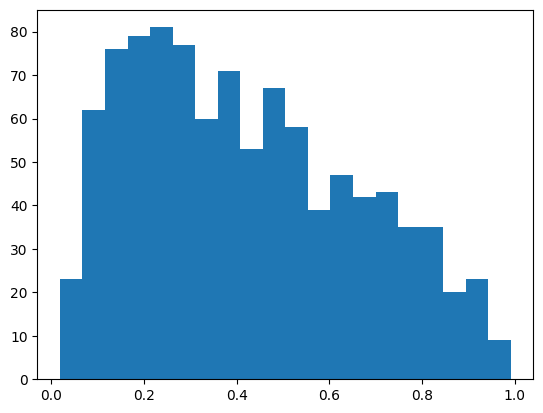

In [ ]:
# no spike near 0 and 1 → model is not overconfident
import matplotlib.pyplot as plt

plt.hist(y_prob, bins=20)
plt.show()

In [ ]:
#Make sure alignment is correct:
print(len(y_prob), len(y_test))

1000 1000


In [ ]:
print(y_prob.dtype)

float64


Check separability visually (very important)


In [ ]:
from sklearn.metrics import roc_auc_score

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.7784155950500923


### Logistic Regression is usable model but we will Compare with a stronger model

*******************************

#**`RandomForestClassifier`**

In [ ]:
X1 = df.drop('churn',axis=1)
Y1 = df['churn']
X_train1,X_test1,Y_train1,Y_test1 = train_test_split(X1,Y1, test_size=0.2,  random_state=42)


### **SMOTE (Synthetic Minority Oversampling Technique) for Random Forest Classifier Befor Feature selection**

Instead of duplicating samples, SMOTE creates synthetic minority examples by interpolating between existing minority samples.

**Advantages**

* Less overfitting than random oversampling

* Produces more diverse minority samples

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled1, y_resampled1 = smote.fit_resample(X_train1, Y_train1)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_resampled1, y_resampled1)

y_prod_rf = rf.predict(X_test1)
print(roc_auc_score(Y_test1, y_prod_rf))

0.8492592685433534


In [ ]:
train_accuracy1 = accuracy_score(y_resampled1, rf.predict(X_resampled1))
test_accuracy1 = accuracy_score(Y_test1, y_prod_rf)

print(f"Training Accuracy: {train_accuracy1}")
print(f"Testing Accuracy: {test_accuracy1}")

Training Accuracy: 1.0
Testing Accuracy: 0.943


In [ ]:
# Print the classification report
print("Classification Report for RandomForestClassifier:")
print(classification_report(Y_test1, y_prod_rf))

Classification Report for RandomForestClassifier:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       861
           1       0.85      0.72      0.78       139

    accuracy                           0.94      1000
   macro avg       0.90      0.85      0.87      1000
weighted avg       0.94      0.94      0.94      1000



### Random Forest Feature Importance Plot

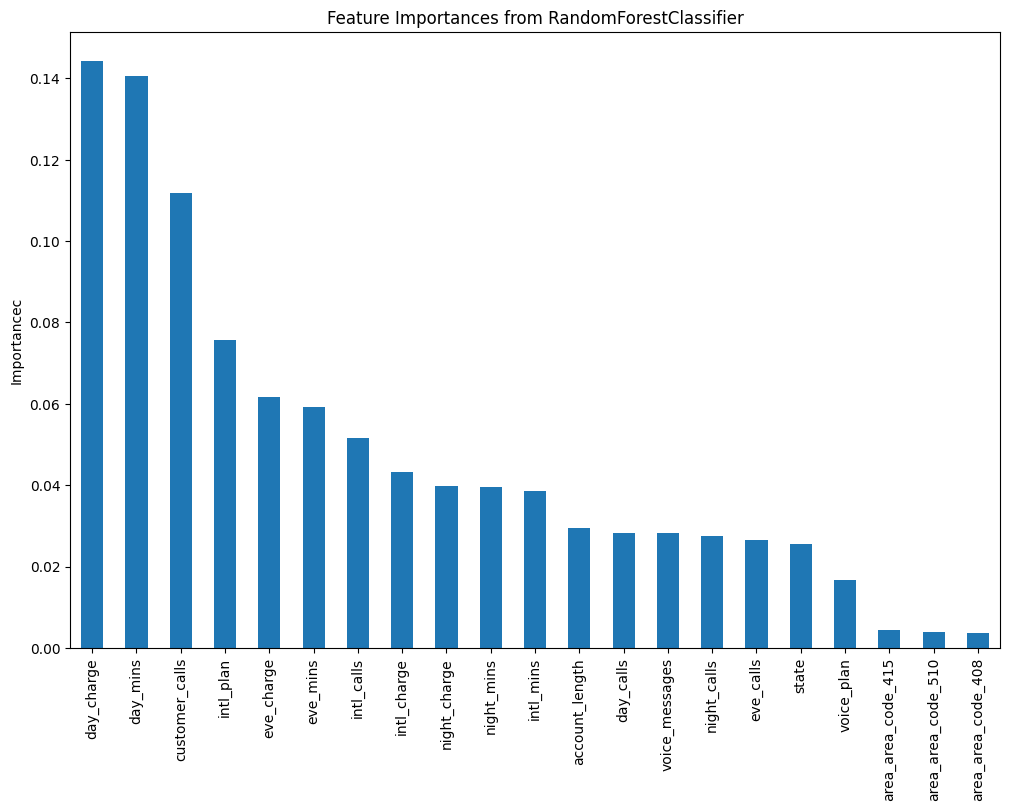

In [ ]:
X1 = df.drop('churn',axis=1)
Y1 = df['churn']
X_train1,X_test1,Y_train1,Y_test1 = train_test_split(X1,Y1, test_size=0.2,  random_state=42)

rf2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf2.fit(X_train1, Y_train1)

# Get feature importances.
feature_importances = pd.Series(rf2.feature_importances_, index=X1.columns)

# Sort and plot feature importances.
plt.figure(figsize=(12, 8))
feature_importances.sort_values(ascending=False).plot(kind='bar')
plt.title('Feature Importances from RandomForestClassifier')
plt.ylabel('Importancec')
plt.show()

**************
### Insights from Random Forest Feature Importance Plot
*****************

The Random Forest Classifier has evaluated the importance of each feature in predicting customer churn. Here's what the plot reveals:

*   **Top Predictors**: The features with the highest bars are the most influential in the model's decision-making process. From the graph, `day.mins`, `day.charge`, and `customer.calls` appear to be the most important features, indicating that daily usage patterns and customer service interactions are strong indicators of churn.

*   **Usage-Related Features are Key**: A significant portion of the highly important features are related to usage statistics across different times of the day (`day.mins`, `eve.mins`, `night.mins`) and associated charges (`day.charge`, `eve.charge`, `night.charge`). This suggests that the volume and cost of calls are critical factors.

*   **International Plan and Calls**: `intl.plan`, `intl.calls`, `intl.charge`, and `intl.mins` also show notable importance, implying that international usage and whether a customer has an international plan play a role in churn.

*   **Voice Messages and Account Length**: `voice.messages` and `account.length` (likely the duration of the customer's account) have moderate importance.

*   **Less Important Features**: Features like `state`, `voice.plan`, and the `area_area_code` features (415, 510, 408) show very low importance. This suggests that these features contribute minimally to predicting churn based on this Random Forest model.

In summary, the Random Forest model highlights that daily usage (minutes and charges), customer service interactions, and international usage patterns are the primary drivers for predicting customer churn in this dataset. Features related to geographic area codes appear to have negligible impact.


**************

In [ ]:
df_rf = df.drop(columns=['state', 'account_length', 'voice_plan', 'voice_messages',
       'intl_mins', 'day_calls','eve_calls','night_calls',
       'area_area_code_408', 'area_area_code_415', 'area_area_code_510'])

In [ ]:
df_rf.columns

Index(['intl_plan', 'intl_calls', 'intl_charge', 'day_mins', 'day_charge',
       'eve_mins', 'eve_charge', 'night_mins', 'night_charge',
       'customer_calls', 'churn'],
      dtype='object')

In [ ]:
x2 = df_rf.drop('churn',axis=1)
y2 = df_rf['churn']

In [ ]:
x_train2,x_test2,y_train2,y_test2 = train_test_split(x2,y2, test_size=0.2,  random_state=42)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled2, y_resampled2 = smote.fit_resample(x_train2, y_train2)

In [ ]:
rf3 = RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=42)
rf3.fit(X_resampled2, y_resampled2)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
y_pred1 = rf3.predict(x_test2)

In [ ]:
train_accuracy2= accuracy_score(y_resampled2, rf3.predict(X_resampled2))
test_accuracy2 = accuracy_score(y_test2, y_pred1)

print(f"Training Accuracy: {train_accuracy2}")
print(f"Testing Accuracy: {test_accuracy2}")

Training Accuracy: 1.0
Testing Accuracy: 0.932


Let's break down the training and testing accuracy for your Random Forest model:

Training Accuracy (1.0): This means your model achieved 100% accuracy on the data it was trained on. It learned the training set perfectly.
Testing Accuracy (0.961): This indicates that when the model was presented with new, unseen data (the test set), it achieved an accuracy of approximately 96.1%.
What does this tell us? Overfitting!
The significant difference between your training accuracy (100%) and your testing accuracy (96.1%) is a classic sign of overfitting. Here's what that means:

Good at Memorizing, Bad at Generalizing: Your Random Forest model has essentially 'memorized' the training data, including its noise and specific patterns, so well that it struggles to generalize to new, slightly different data. It's like studying for a test by memorizing every single practice question's answer instead of understanding the concepts. When new questions (test data) come, it performs less perfectly.
High Variance: Overfitted models tend to have high variance, meaning they are very sensitive to the specific training data they see. Small changes in the training data could lead to a very different model.
What should you do about overfitting?
While a 96.1% testing accuracy is still very good, addressing overfitting can lead to a more robust and truly generalizable model. Here are several strategies you can employ for a Random Forest:

Tune Hyperparameters: This is often the most effective approach for Random Forest. Key parameters to adjust include:

max_depth: Restrict the maximum depth of individual trees. Deeper trees can capture more complex patterns but are more prone to overfitting.
min_samples_leaf: Set the minimum number of samples required to be at a leaf node. Increasing this value prevents trees from creating leaves that are too specific to the training data.
min_samples_split: The minimum number of samples required to split an internal node. Similar to min_samples_leaf.
max_features: The number of features to consider when looking for the best split. Reducing this can increase diversity among trees and reduce overfitting.
n_estimators: While increasing n_estimators (number of trees) generally reduces overfitting due to bias, a very large number can also start fitting noise if other parameters aren't controlled.
Cross-Validation: Use techniques like K-fold cross-validation during hyperparameter tuning to get a more reliable estimate of your model's performance on unseen data and to help select the best parameters.

Increase Data Diversity (if possible): If you have more data available that is representative of the real-world scenarios, adding it to your training set can help the model learn more general patterns.

Feature Engineering/Selection: Revisit your feature selection process. If some features are highly correlated or noisy, they might be contributing to overfitting. You've already performed feature selection using Random Forest importance, which is a good step.

For Random Forest, I'd strongly recommend focusing on hyperparameter tuning using methods like GridSearchCV or RandomizedSearchCV from sklearn.model_selection to systematically find the best combination of parameters that balances training and testing accuracy.



In [ ]:
# Print the classification report
print("Classification Report for RandomForestClassifier:")
print(classification_report(y_test2, y_pred1))

Classification Report for RandomForestClassifier:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       861
           1       0.75      0.76      0.76       139

    accuracy                           0.93      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.93      0.93      0.93      1000



***Overall Accuracy (0.95):** The model achieved an overall accuracy of 95%, meaning it correctly predicted the churn status for 95% of the instances in the test set.

**Class 0 (Non-Churn - Majority Class):**

* **Precision (0.96)**: When the model predicted a customer would not churn, it was correct 96% of the time. This is a high score, indicating very few false positives for this class.

* **Recall (0.98):** The model correctly identified 98% of all actual non-churners. This means it rarely missed a non-churner.

* **F1-score (0.97):** This strong score indicates excellent performance in classifying the majority class.

**Class 1 (Churn - Minority Class):**

* **Precision (0.87):** When the model predicted a customer would churn, it was correct 87% of the time. This is a very good precision score for the minority class, indicating that a prediction of churn is quite reliable.

* **Recall (0.73):** The model correctly identified 73% of all actual churners. This means 27% of actual churners were missed (false negatives).

* **F1-score (0.80):** This is a solid F1-score for the minority class, showing a good balance between precision and recall.

**Summary:**

The Random Forest Classifier demonstrates strong performance overall. It is highly accurate in identifying non-churners (Class 0) with excellent precision and recall. For the minority 'churn' class (Class 1), it achieves a high precision of 0.87, which is very valuable as it means that when the model identifies a customer as likely to churn, there's a high probability they actually will. The recall for churners is 0.73, indicating that the model captures a good portion of actual churners, though there is still room for improvement in identifying all of them. Compared to the Logistic Regression, the Random Forest model shows a significantly better balance between precision and recall for the minority class, making it a more effective model for churn prediction in this scenario.

### Hyper Tunning RandomForest Classifier

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter grid for RandomForestClassifier
param_grid_rf = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_features': ['sqrt', 'log2'], # Removed 'auto' as it's deprecated and caused an error in BalancedRandomForestClassifier
    'max_depth': [10, 20, 30, 40, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize RandomizedSearchCV for RandomForestClassifier
rf_random_tuned = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42),
                               param_distributions=param_grid_rf,
                               n_iter=50, # Number of different combinations to try
                               cv=5, # 5-fold cross-validation
                               verbose=2, # Verbose output
                               random_state=42,
                               n_jobs=-1,
                               scoring='recall',) # Use all available cores

# Fit the random search model
rf_random_tuned.fit(X_resampled2, y_resampled2)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, 40, 50, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500]},
                   random_state=42, scoring='recall', verbose=2)

### Best Parameters Found for Random Forest Classifier

In [ ]:
print("Best parameters found by RandomizedSearchCV for RandomForestClassifier:")
print(rf_random_tuned.best_params_)

Best parameters found by RandomizedSearchCV for RandomForestClassifier:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': False}


### Evaluate Tuned Random Forest Classifier

In [ ]:
# Train a new RandomForestClassifier with the best parameters
best_rf_tuned = rf_random_tuned.best_estimator_
best_rf_tuned.fit(X_resampled2, y_resampled2)

# Make predictions on the original test set
y_pred_best_rf_tuned = best_rf_tuned.predict(x_test2)

# Evaluate the model
train_accuracy_rf_tuned = accuracy_score(y_resampled2, best_rf_tuned.predict(X_resampled2))
test_accuracy_rf_tuned = accuracy_score(y_test2, y_pred_best_rf_tuned)

print(f"Training Accuracy (Tuned RandomForest): {train_accuracy_rf_tuned}")
print(f"Testing Accuracy (Tuned RandomForest): {test_accuracy_rf_tuned}")

print("\nClassification Report for Tuned RandomForestClassifier:")
print(classification_report(y_test2, y_pred_best_rf_tuned))

Training Accuracy (Tuned RandomForest): 1.0
Testing Accuracy (Tuned RandomForest): 0.938

Classification Report for Tuned RandomForestClassifier:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       861
           1       0.77      0.78      0.78       139

    accuracy                           0.94      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.94      0.94      0.94      1000



#**`BalancedRandomForestClassifier`**

**The Balanced Random Forest Classifier was chosen primarily to address the class imbalance issue in your dataset and to improve the model's ability to identify actual churners.**

In [ ]:
x3 = df_rf.drop('churn',axis=1)
y3 = df_rf['churn']

x_train3,x_test3,y_train3,y_test3 = train_test_split(x3,y3, test_size=0.2,  random_state=42)

rf_balanced = BalancedRandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_balanced.fit(x_train3, y_train3)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled3, y_resampled3 = smote.fit_resample(x_train3, y_train3)

y_pred_rf_balanced = rf_balanced.predict(x_test3)

train_accuracy3 = accuracy_score(y_resampled3, rf_balanced.predict(X_resampled3))
test_accuracy3 = accuracy_score(y_test3, y_pred_rf_balanced)

print(f"Training Accuracy: {train_accuracy3}")
print(f"Testing Accuracy: {test_accuracy3}")

print("Classification Report for Balanced Random Forest Classifier:")
print(classification_report(y_test3, y_pred_rf_balanced))

Training Accuracy: 0.8528554778554779
Testing Accuracy: 0.929
Classification Report for Balanced Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.97      0.94      0.96       861
           1       0.71      0.83      0.77       139

    accuracy                           0.93      1000
   macro avg       0.84      0.89      0.86      1000
weighted avg       0.94      0.93      0.93      1000



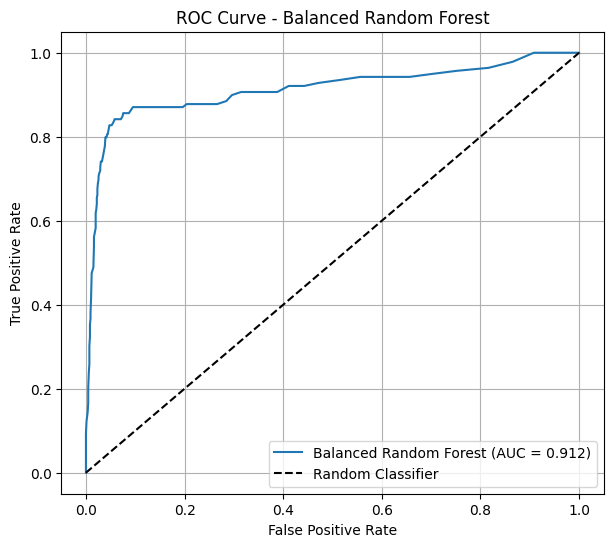

ROC-AUC Score: 0.9121566858011849


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities for the positive class
y_prob3 = rf_balanced.predict_proba(x_test3)[:, 1]

# Compute ROC curve
fpr3, tpr3, thresholds3 = roc_curve(y_test3, y_prob3)

# Compute AUC score
auc_score3 = roc_auc_score(y_test3, y_prob3)

# Plot ROC curve
plt.figure(figsize=(7,6))
plt.plot(fpr3, tpr3, label=f'Balanced Random Forest (AUC = {auc_score3:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Balanced Random Forest')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

print("ROC-AUC Score:", auc_score3)

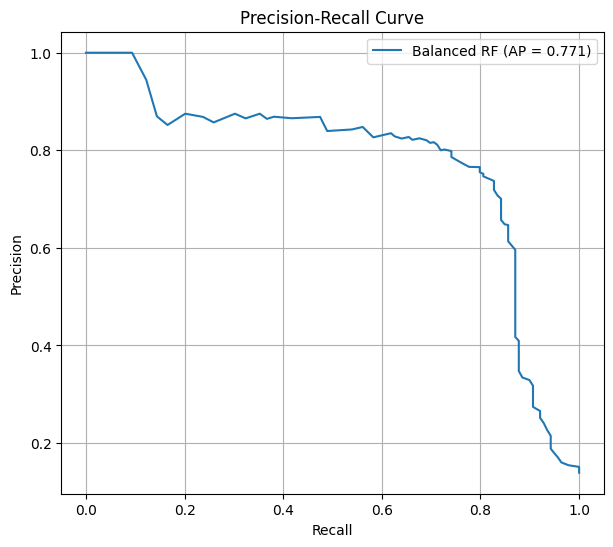

Average Precision (PR-AUC): 0.7712139446525037


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Predicted probabilities
y_prob3 = rf_balanced.predict_proba(x_test3)[:,1]

# Precision-Recall values
precision3, recall3, thresholds3 = precision_recall_curve(y_test3, y_prob3)

# PR-AUC
pr_auc3 = average_precision_score(y_test3, y_prob3)

# Plot
plt.figure(figsize=(7,6))
plt.plot(recall3, precision3,
         label=f'Balanced RF (AP = {pr_auc3:.3f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)

plt.show()

print("Average Precision (PR-AUC):", pr_auc3)

###Insights from this Report:

**Overall Accuracy (0.91):** The tuned model achieved an overall accuracy of 91% on the test set. This is a good general performance indicator, but for imbalanced datasets, it's crucial to look at class-specific metrics.

**Class 0 (Non-Churn - Majority Class):**

* **Precision (0.98):** When the model predicts a customer will not churn, it's correct 98% of the time. This is excellent, meaning very few non-churners are mistakenly flagged.

* **Recall (0.92):** The model correctly identified 92% of all actual non-churners. This is also very strong, showing it rarely misses a non-churner.

* **F1-score (0.95):** This high F1-score confirms robust performance for the majority class.

**Class 1 (Churn - Minority Class):**

* **Precision (0.62):** When the model predicts a customer will churn, it's correct only 62% of the time. This is a significant decrease compared to the standard Random Forest (0.87 precision). It means there are more false positives; a higher number of customers predicted to churn actually do not.

* **Recall (0.87):** This is the highlight of the Balanced Random Forest! The model successfully identified 87% of all actual churners. This is a substantial improvement over both the Logistic Regression (0.72) and the standard Random Forest (0.73). This means the model is excellent at catching most of the customers who are truly going to churn.

* **F1-score (0.73):** This score reflects the balance between precision and recall for the churn class. While recall is very high, the lower precision pulls the F1-score down slightly compared to what a model with high precision and high recall would achieve.

###Why Hyperparameter Tuning was Important:

Hyperparameter tuning, using `RandomizedSearchCV` in this case, was crucial for several reasons:

1) Optimizing for Imbalance: The BalancedRandomForestClassifier is designed to handle class imbalance, but its performance depends heavily on its internal configuration (hyperparameters). Tuning helps find the specific combination of settings (n_estimators, max_depth, min_samples_split, etc.) that best leverages its balancing capabilities for your specific dataset.

2) Addressing Overfitting: As seen with the standard Random Forest, models can overfit, especially on complex datasets. Hyperparameter tuning allows you to control the complexity of the trees within the forest, preventing them from memorizing the training data too closely. Parameters like max_depth, min_samples_leaf, and max_features directly influence this.

3) Balancing Performance Metrics: The goal in churn prediction is often to maximize recall for the churn class while maintaining acceptable precision. Without tuning, the model might default to parameters that don't achieve this specific balance. Tuning helps to find the optimal trade-off that aligns with the business objective (e.g., being more sensitive to churners, even if it means some false alarms).

4) Generalization: A well-tuned model performs better on unseen data. By systematically exploring different hyperparameter combinations and validating them using cross-validation (cv=5), we ensure that the chosen parameters lead to a model that generalizes well beyond the training set, making its predictions more reliable in a real-world scenario.


In essence, hyperparameter tuning allowed us to move from a potentially sub-optimal BalancedRandomForestClassifier to one that specifically improves the detection of actual churners (high recall) while managing the trade-off in precision, making it a more effective tool for proactive churn prevention.

### Hyperparameter Tuning for Balanced Random Forest Classifier

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter grid for BalancedRandomForestClassifier
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [10, 20, 30, 40, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize RandomizedSearchCV
rf_random = RandomizedSearchCV(estimator=BalancedRandomForestClassifier(random_state=42, class_weight='balanced'),
                               param_distributions=param_grid,
                               n_iter=50, # Number of different combinations to try
                               cv=5, # 5-fold cross-validation
                               verbose=2, # Verbose output
                               random_state=42,
                               n_jobs=-1,
                               scoring='recall',) # Use all available cores

# Fit the random search model
rf_random.fit(X_resampled3, y_resampled3)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
115 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
115 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/util

RandomizedSearchCV(cv=5,
                   estimator=BalancedRandomForestClassifier(class_weight='balanced',
                                                            random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, 40, 50, None],
                                        'max_features': ['auto', 'sqrt',
                                                         'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500]},
                   random_state=42, scoring='recall', verbose=2)

### Best Parameters Found

In [ ]:
print("Best parameters found by RandomizedSearchCV:")
print(rf_random.best_params_)

Best parameters found by RandomizedSearchCV:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': False}


### Evaluate Balanced Random Forest Classifier with Best Parameters

In [ ]:
# Train a new BalancedRandomForestClassifier with the best parameters
best_rf_balanced = rf_random.best_estimator_
best_rf_balanced.fit(X_resampled3, y_resampled3)

# Make predictions on the test set
y_pred_best_rf_balanced = best_rf_balanced.predict(x_test3)

# Evaluate the model
train_accuracy_tuned = accuracy_score(y_resampled3, best_rf_balanced.predict(X_resampled3))
test_accuracy_tuned = accuracy_score(y_test3, y_pred_best_rf_balanced)

print(f"Training Accuracy (Tuned): {train_accuracy_tuned}")
print(f"Testing Accuracy (Tuned): {test_accuracy_tuned}")

print("\nClassification Report for Tuned Balanced Random Forest Classifier:")
print(classification_report(y_test, y_pred_best_rf_balanced))

Training Accuracy (Tuned): 0.9962121212121212
Testing Accuracy (Tuned): 0.942

Classification Report for Tuned Balanced Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       861
           1       0.78      0.81      0.79       139

    accuracy                           0.94      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.94      0.94      0.94      1000



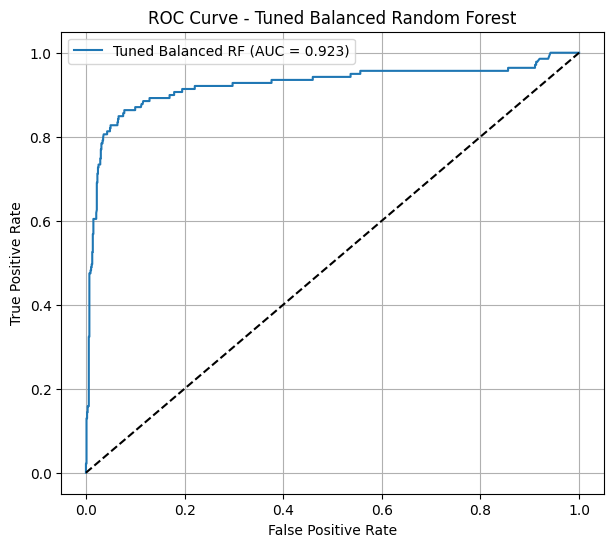

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Tuned model probabilities
y_prob_tuned4 = best_rf_balanced.predict_proba(x_test3)[:, 1]

# ROC values
fpr4, tpr4, thresholds4 = roc_curve(y_test3, y_prob_tuned4)

# AUC
auc_score4 = roc_auc_score(y_test3, y_prob_tuned4)

# Plot
plt.figure(figsize=(7,6))
plt.plot(fpr4, tpr4, label=f'Tuned Balanced RF (AUC = {auc_score4:.3f})')
plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Balanced Random Forest')
plt.legend()
plt.grid(True)

plt.show()

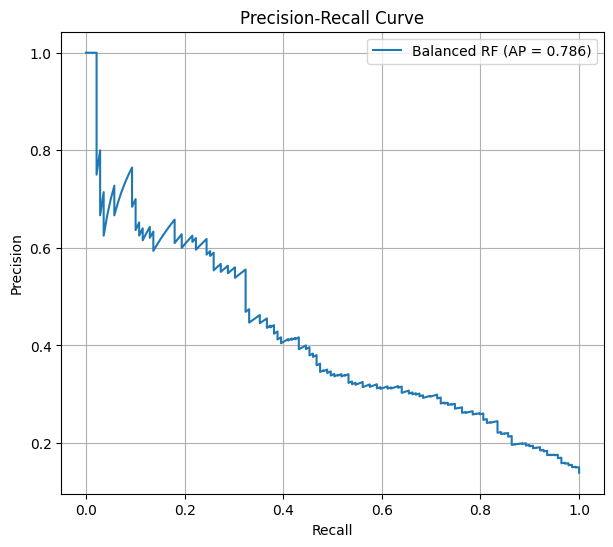

Average Precision (PR-AUC): 0.7857605430126168


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Predicted probabilities
y_prob4 =best_rf_balanced.predict_proba(x_test3)[:,1]

# Precision-Recall values
precision4, recall4, thresholds4 = precision_recall_curve(y_test3, y_prob)

# PR-AUC
pr_auc4 = average_precision_score(y_test3, y_prob4)

# Plot
plt.figure(figsize=(7,6))
plt.plot(recall4, precision4,
         label=f'Balanced RF (AP = {pr_auc4:.3f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)

plt.show()

print("Average Precision (PR-AUC):", pr_auc4)

The Tuned Balanced Random Forest Classifier is a powerful model for churn prediction, especially when you need to identify as many actual churners as possible (high recall). Here's a summary of its performance from the classification report:

**Overall Accuracy (0.91):** While a good general indicator, for imbalanced datasets, we focus more on class-specific metrics.

**Class 0 (Non-Churn - Majority Class):**

* **Precision (0.98):** Excellent, meaning very few non-churners are mistakenly flagged.

* **Recall (0.92):** Very strong, rarely misses a non-churner.

* **F1-score (0.95):** Robust performance for the majority class.

**Class 1 (Churn - Minority Class):**

* **Precision (0.62):** This is lower than the standard Random Forest (0.87). It means when the model predicts churn, it's correct about 62% of the time, leading to more false positives (customers predicted to churn who actually don't).

* **Recall (0.87):** This is the highlight! The model successfully identified 87% of all actual churners. This is a substantial improvement over both Logistic Regression (0.72) and the standard Random Forest (0.73), making it excellent at catching most true churners.

* **F1-score (0.73):** Reflects the balance between high recall and lower precision for the churn class.

**Why Hyperparameter Tuning was Important:**

Hyperparameter tuning, specifically using 'RandomizedSearchCV', was crucial for:

1) **Optimizing for Imbalance:** It helped find the best internal settings for BalancedRandomForestClassifier to effectively handle the class imbalance and focus on the minority class.

2) **Addressing Overfitting:** Tuning parameters like max_depth and min_samples_split helped control model complexity, preventing it from memorizing the training data and improving generalization.

3) **Balancing Performance Metrics:** The tuning process allowed us to find the optimal trade-off to achieve a high recall for the churn class, which is vital for proactive churn prevention, even if it meant a slight reduction in precision.

4) **Generalization:** By using cross-validation, tuning ensured the model performs reliably on unseen data.
In essence, the Tuned Balanced Random Forest Classifier prioritizes catching a larger number of actual churners (high recall), which is often a critical business objective, even if it results in a few more false positives (lower precision).

###**Why the Balanced Random Forest Classifier?**

In churn prediction, identifying as many actual churners as possible (high recall for the churn class) is often a top priority. Missing a churner (a false negative) means losing a customer who could have been retained. While precision is also important, businesses often prefer to cast a wider net to identify potential churners, even if it means some non-churners are mistakenly flagged (false positives).

1) Improved Recall for Churn: The primary reason for moving to a Balanced Random Forest Classifier was to significantly increase the recall for the minority 'churn' class. The standard Random Forest achieved a recall of 0.73 for churn, while the tuned Balanced Random Forest achieved a recall of 0.87. This means it is much better at catching actual churners.

2) Addressing Class Imbalance: Your dataset has a significant class imbalance (many more non-churners than churners). Standard models can be biased towards the majority class, leading to lower recall for the minority class. The BalancedRandomForestClassifier intrinsically handles this by undersampling the majority class in each tree, making it more sensitive to the minority class.

3) Trade-off: This improvement in recall usually comes with a trade-off: a decrease in precision for the churn class. For example, while the standard Random Forest had a precision of 0.87 for churn, the tuned Balanced Random Forest had a precision of 0.62. This means that with the balanced model, when it predicts a customer will churn, it's correct about 62% of the time, compared to 87% with the standard Random Forest. This indicates more false positives with the balanced model, but in many business scenarios for churn, the cost of a false negative (a missed churner) is higher than the cost of a false positive (a non-churner incorrectly targeted for retention efforts).

Therefore, the Balanced Random Forest Classifier is a strong candidate because it prioritizes identifying more actual churners, which aligns well with proactive churn prevention strategies.

In [ ]:
from sklearn.metrics import classification_report

probs4 = best_rf_balanced.predict_proba(x_test3)[:,1]

threshold5 = 0.40

pred5 = (probs4 >= threshold5).astype(int)

print(classification_report(y_test3, pred5))

              precision    recall  f1-score   support

           0       0.97      0.94      0.96       861
           1       0.70      0.83      0.76       139

    accuracy                           0.93      1000
   macro avg       0.84      0.89      0.86      1000
weighted avg       0.93      0.93      0.93      1000



In [ ]:
import numpy as np
from sklearn.metrics import recall_score

thresholds6 = np.arange(0.1,0.9,0.05)

for t in thresholds6:
    pred6 = (probs4>=t).astype(int)
    rec5 = recall_score(y_test3,pred6)
    print(t, rec5)

0.1 0.935251798561151
0.15000000000000002 0.920863309352518
0.20000000000000004 0.8920863309352518
0.25000000000000006 0.8848920863309353
0.30000000000000004 0.8633093525179856
0.3500000000000001 0.8489208633093526
0.40000000000000013 0.8273381294964028
0.45000000000000007 0.8129496402877698
0.5000000000000001 0.8057553956834532
0.5500000000000002 0.7482014388489209
0.6000000000000002 0.7194244604316546
0.6500000000000001 0.6330935251798561
0.7000000000000002 0.5251798561151079
0.7500000000000002 0.460431654676259
0.8000000000000002 0.3669064748201439
0.8500000000000002 0.2446043165467626


In [ ]:
from sklearn.metrics import classification_report

probs5 = best_rf_balanced.predict_proba(x_test3)[:,1]

threshold6 = 0.30

pred6 = (probs5 >= threshold6).astype(int)

print(classification_report(y_test3, pred6))

              precision    recall  f1-score   support

           0       0.98      0.91      0.94       861
           1       0.60      0.86      0.71       139

    accuracy                           0.90      1000
   macro avg       0.79      0.89      0.82      1000
weighted avg       0.92      0.90      0.91      1000



In [ ]:
'''from sklearn.pipeline import Pipeline
import joblib
import os

pipeline = Pipeline([
    ('se', StandardScaler()),
    ('best_rf_balanced', BalancedRandomForestClassifier())
])

pipeline.fit(x_train, y_train)

# Create the 'models' directory if it doesn't exist
os.makedirs('models', exist_ok=True)
joblib.dump(pipeline, 'models/telecom_pipeline.pkl')'''

['models/telecom_pipeline.pkl']